In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.figure import figaspect
import os
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap



In [2]:
from matplotlib import rc_file
rc_file('/home/sergi_alcala/Matplotlib/mplconf.rc')

In [3]:
# Aztec_old_results_1 = pd.read_csv('Costs_Paris_delay_5_phi_10_AZTEC_OLD_RESULTS_1.csv', index_col=0)
# Aztec_old_results_2 = pd.read_csv('Costs_Paris_delay_5_phi_10_AZTEC_OLD_RESULTS_2.csv',index_col=0)
# Aztec_old_results_merged = pd.concat([Aztec_old_results_1, Aztec_old_results_2])
# Aztec_old_results_merged.to_csv('Costs_Paris_delay_5_phi_10_AZTEC_OLD_RESULTS_ALL.csv')

In [4]:
Deepcog_costs = pd.read_csv('Costs_Paris_delay_1_phi_10_DEEPCOG.csv', index_col=0)
# Aztec_old_results_merged = pd.read_csv('Costs_Paris_delay_5_phi_10_AZTEC_OLD_RESULTS_ALL.csv', index_col=0)
Aztec_old_results_merged = pd.read_csv('Costs_Paris_AZTEC_OLD_phi_05.csv', index_col=0) # this is the good one showed

Aztec_ext_results = pd.read_csv('Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05.csv', index_col=0)
infocom_17_results = pd.read_csv('Costs_Paris_delay_1_phi_10_INFOCOM17.csv', index_col=0)

In [5]:
ROOT_DIR = ''
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [6]:
def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [7]:
city_df = load_real_data('Paris')

In [8]:
max_concatenated= city_df.max(axis=0)


In [9]:
max_concatenated

array([2.75302710e+10, 4.19453199e+10, 5.14211491e+10, 7.20334643e+10,
       5.25371555e+10])

In [10]:
raw_data_path_Deepcog = 'Deepcog_Results'
raw_data_path_Aztec_old = 'Results_AZTEC_6'
# raw_data_path_Aztec_ext = 'Results_INSTANTATION_FIX'
raw_data_path_Aztec_ext = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed'

cities = ['Paris']

Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]

Alphas = [2,3,5]
# Alphas = [2]

ppf_static = 0.9
ppf_helper = 0.7




In [11]:

################################################# LOAD AZTEC DATA #################################################


num_services = 5


static_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
shared_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
output_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
len_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
sla_list_np = np.zeros ((len(Alphas),len(Phis),len(ETAS),num_services))
results_path =raw_data_path_Aztec_ext

cost_overprovisioning_static_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
cost_overprovisioning_shared_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))

for city in cities:
    for i,phi in enumerate(Phis): ### Columns
        for k,eta in enumerate(ETAS):
            delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
            for j,alpha in enumerate(Alphas): ### Rows
                static_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy')
                # static_list.append((static_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
                
                static_list_np[j,i,k] = (static_norm.sum(axis= 0)* 10e9).sum(axis=-1)

                shared_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy')
                # shared_list.append((shared_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
                shared_list_np[j,i,k] = (shared_norm.sum(axis= 0)* 10e9).sum(axis=-1)

                output_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy')
                # output_list.append((output_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
            
                output_list_np[j,i,k] = (output_norm.sum(axis= 0)* 10e9).sum(axis=-1)
                len_list_np[j,i,k] = len(static_norm)
                

                sla = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy')
                sla_list_np[j,i,k] = sla
                # sla_list_np.append(sla)
                

                cost_overprovisioning_static = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy')
        
                cost_overprovisioning_static_list_np[j,i,k] = cost_overprovisioning_static

                cost_overprovisioning_shared = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy')
                
                cost_overprovisioning_shared_list_np[j,i,k] = cost_overprovisioning_shared
        
        

In [12]:
cost_overprovisioning_static_list_np.shape

(3, 4, 10)

In [13]:
################################################# LOAD AZTEC OLD DATA #################################################


cost_overprovisioning_static_list_np_6 = np.zeros((len(Alphas),len(Phis)))
cost_overprovisioning_shared_list_np_6 = np.zeros((len(Alphas),len(Phis)))
results_path =raw_data_path_Aztec_old

len_list_np_6 = np.zeros((len(Alphas),len(Phis)))
sla_list_np_6 = np.zeros ((len(Alphas),len(Phis),num_services))
static_list_np_6 = np.zeros((len(Alphas),len(Phis)))
shared_list_np_6 = np.zeros((len(Alphas),len(Phis)))

ppf_static_old = 0.9
ppf_helper_old = 0.7

for city in cities:
    for i,phi in enumerate(Phis): ### Columns
        delay= 5
        for j,alpha in enumerate(Alphas): ### Rows

            static_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_2/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy')
            # static_list.append((static_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
            
            static_list_np_6[j,i] = (static_norm.sum(axis= 0)* 10e9).sum(axis=-1)

            shared_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_2/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy')
            # shared_list.append((shared_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
            shared_list_np_6[j,i] = (shared_norm.sum(axis= 0)* 10e9).sum(axis=-1)
           

            cost_overprovisioning_static = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_2/Block_2_3_results/ppf_static_{ppf_static_old}_ppf_helper_{ppf_helper_old}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy')
      
            cost_overprovisioning_static_list_np_6[j,i] = cost_overprovisioning_static

            cost_overprovisioning_shared = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_2/Block_2_3_results/ppf_static_{ppf_static_old}_ppf_helper_{ppf_helper_old}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy')
            
            cost_overprovisioning_shared_list_np_6[j,i] = cost_overprovisioning_shared
            len_list_np_6[j,i] = len(static_norm)
            

            sla = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/ETA_2/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy')
            sla_list_np_6[j,i] = sla

In [14]:
## Load data list-wise ##

# static_list=[]
# shared_list = []
# output_list = []
# len_list = []
# sla_list = []    
# results_path =raw_data_path_Aztec_ext

# cost_overprovisioning_static_list = []
# cost_overprovisioning_shared_list = []
# PHIS, ALPHAS = Phis, Alphas

# for city in cities:
#     for phi in PHIS:
#         delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/overall_optimal_window.npy')
#         for alpha in ALPHAS:
#             static_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy')
#             # static_list.append((static_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
#             static_list.append((static_norm.sum(axis= 0)* 10e9).sum(axis=-1))

#             shared_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy')
#             # shared_list.append((shared_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
#             shared_list.append((shared_norm.sum(axis= 0)* 10e9).sum(axis=-1))

#             output_norm = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy')
#             # output_list.append((output_norm.sum(axis= 0)* max_concatenated).sum(axis=-1)) #### ASK DARIO
#             output_list.append((output_norm.sum(axis= 0)* 10e9).sum(axis=-1))

#             len_list.append(len(static_norm))

#             sla = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy')
#             sla_list.append(sla)

#             cost_overprovisioning_static = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy')
#             cost_overprovisioning_static_list.append(cost_overprovisioning_static)

#             cost_overprovisioning_shared = np.load(f'{ROOT_DIR}/{results_path}/Paris/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy')
#             cost_overprovisioning_shared_list.append(cost_overprovisioning_shared)
            
            

In [15]:
Aztec_old_results_merged[Aztec_old_results_merged.index.str.contains('c_0.1_ppf_helper_0.75_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration


In [13]:
Aztec_ext_results.cost_instantiation.idxmax()

'Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_100_alpha_3_delay_85'

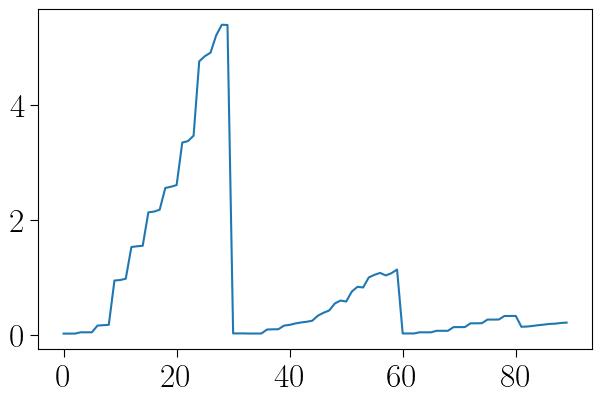

In [14]:
plt.plot(np.array(Aztec_ext_results.cost_instantiation))

In [33]:

Aztec_ext_results[Aztec_ext_results.index.str.contains('_phi_0.1_eta_1_alpha_2_delay_2')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_2_delay_21,0.350356,0.246379,0.085513,0.016074,0.002389


In [36]:

Aztec_ext_results_default = Aztec_ext_results[Aztec_ext_results.index.str.contains(f'static_{ppf_static}_ppf_helper_{ppf_helper}')]
Aztec_old_results_merged_default = Aztec_old_results_merged[Aztec_old_results_merged.index.str.contains(f'static_{ppf_static_old}_ppf_helper_{ppf_helper_old}')]

In [19]:
Aztec_old_results_merged_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_5,0.270607,0.185103,0.033291,0.051806,0.000406
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_5,0.289743,0.190911,0.046586,0.051840,0.000406
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_5,0.326226,0.201897,0.072078,0.051847,0.000404
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_5,0.293035,0.224470,0.017876,0.049981,0.000708
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_5,0.304752,0.230262,0.023751,0.050014,0.000725
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_5,0.325169,0.237130,0.037236,0.050060,0.000742
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_5,0.420176,0.360699,0.007893,0.050245,0.001339
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_5,0.424338,0.360909,0.011840,0.050249,0.001340
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_5,0.432575,0.362482,0.016235,0.050486,0.003371


In [20]:
Aztec_ext_results

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_2_delay_21,0.335303,0.243093,0.073632,0.016287,0.002290
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_3_delay_21,0.372962,0.259014,0.094946,0.016719,0.002283
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_5_delay_21,0.444182,0.288365,0.136838,0.016721,0.002259
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_2_delay_27,0.409609,0.296368,0.071172,0.038957,0.003112
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_3_delay_27,0.458165,0.332167,0.083686,0.039257,0.003054
...,...,...,...,...,...
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_90_alpha_3_delay_85,0.953099,0.756690,0.013309,0.173441,0.009660
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_90_alpha_5_delay_85,0.988504,0.780894,0.013139,0.184877,0.009595
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_100_alpha_2_delay_85,0.921952,0.706301,0.017508,0.189878,0.008266
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_100_alpha_3_delay_85,0.960667,0.736611,0.013794,0.202021,0.008241


In [21]:
Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains('_alpha_2_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_5,0.270607,0.185103,0.033291,0.051806,0.000406
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_5,0.293035,0.224470,0.017876,0.049981,0.000708
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_5,0.420176,0.360699,0.007893,0.050245,0.001339


WE TAKE  static_0.9_ppf_helper_0.7_ AS DEFAULT

In [22]:

phi = 1
eta = 1

cost_total_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()
cost_total_eta_2_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()

In [23]:
cost_total_eta_2_Aztec_ext

array([0.27165111])

In [24]:
Aztec_ext_results_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_2_delay_21,0.335303,0.243093,0.073632,0.016287,0.002290
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_3_delay_21,0.372962,0.259014,0.094946,0.016719,0.002283
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_1_alpha_5_delay_21,0.444182,0.288365,0.136838,0.016721,0.002259
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_2_delay_27,0.409609,0.296368,0.071172,0.038957,0.003112
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_3_delay_27,0.458165,0.332167,0.083686,0.039257,0.003054
...,...,...,...,...,...
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_90_alpha_3_delay_85,0.953099,0.756690,0.013309,0.173441,0.009660
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_90_alpha_5_delay_85,0.988504,0.780894,0.013139,0.184877,0.009595
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_100_alpha_2_delay_85,0.921952,0.706301,0.017508,0.189878,0.008266
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_100_alpha_3_delay_85,0.960667,0.736611,0.013794,0.202021,0.008241


In [25]:
# Aztec_ext_results_default_eta_10 = Aztec_ext_results_default.copy()
# Aztec_ext_results_default_eta_10['cost_instantiation'] = Aztec_ext_results_default_eta_10['cost_instantiation']*5
# Aztec_ext_results_default_eta_10['total_costs'] = Aztec_ext_results_default_eta_10['cost_overprovisioning'] + Aztec_ext_results_default_eta_10['cost_instantiation'] + Aztec_ext_results_default_eta_10['cost_slas']  + Aztec_ext_results_default_eta_10['cost_reconfiguration']
phi = 1
eta = 10

Aztec_old_results_merged_default_eta_10 = Aztec_old_results_merged_default.copy()
Aztec_old_results_merged_default_eta_10['cost_instantiation'] = Aztec_old_results_merged_default_eta_10['cost_instantiation']*eta
Aztec_old_results_merged_default_eta_10['total_costs'] = Aztec_old_results_merged_default_eta_10['cost_overprovisioning'] + Aztec_old_results_merged_default_eta_10['cost_instantiation'] + Aztec_old_results_merged_default_eta_10['cost_slas']  + Aztec_old_results_merged_default_eta_10['cost_reconfiguration']

Deepcog_costs_eta_10 = Deepcog_costs.copy()
Deepcog_costs_eta_10['cost_instantiation_infocom19'] = Deepcog_costs_eta_10['cost_instantiation_infocom19']*eta
Deepcog_costs_eta_10['total_cost'] = Deepcog_costs_eta_10['cost_overprovisioning_infocom'] + Deepcog_costs_eta_10['cost_instantiation_infocom19'] + Deepcog_costs_eta_10['cost_slas_infocom_19']  + Deepcog_costs_eta_10['cost_reconfiguration']

infocom_costs_eta_10 = infocom_17_results.copy()
infocom_costs_eta_10['cost_instantiation_infocom17'] = infocom_costs_eta_10['cost_instantiation_infocom17']*eta
infocom_costs_eta_10['total_cost'] = infocom_costs_eta_10['cost_overprovisioning_infocom'] + infocom_costs_eta_10['cost_instantiation_infocom17'] + infocom_costs_eta_10['cost_slas_infocom_17']  + infocom_costs_eta_10['cost_reconfiguration']

cost_total_eta_2_Aztec_ext_eta_10 = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Aztec_old_eta_10 = Aztec_old_results_merged_default_eta_10[Aztec_old_results_merged_default_eta_10.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Deepcog_eta_10 = Deepcog_costs_eta_10[Deepcog_costs_eta_10.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()
cost_total_eta_2_infocom_17_eta_10 = infocom_costs_eta_10[infocom_costs_eta_10.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()



NameError: name 'Aztec_old_results_merged_default' is not defined

In [17]:
def Retrieve_total_cost_modify_instantation_cost(df,phi,eta,ppf_static,ppf_helper,benchmark=None):

    alpha = 2
    
    if  benchmark =='deepcog':
        res = df.copy()
        res['cost_instantiation_infocom19'] = res['cost_instantiation_infocom19']*eta
        res['total_costs'] = res['cost_overprovisioning_infocom'] + res['cost_instantiation_infocom19'] + res['cost_slas_infocom_19']  + res['cost_reconfiguration']
        
        cost_total_res = res[res.index.str.contains(f'phi_{phi}_alpha_{alpha}_')]['total_costs'].to_numpy()
        
        

    elif  benchmark =='infocom':
        res = df.copy()
        res['cost_instantiation_infocom17'] = res['cost_instantiation_infocom17']*eta
        res['total_costs'] = res['cost_overprovisioning_infocom'] + res['cost_instantiation_infocom17'] + res['cost_slas_infocom_17']  + res['cost_reconfiguration']
        
        cost_total_res = res[res.index.str.contains(f'phi_{phi}_alpha_2_')]['total_costs'].to_numpy()
        
       
    elif  benchmark =='aztec_old':
        res = df.copy()
        res['cost_instantiation'] = res['cost_instantiation']*eta
        res['total_costs'] = res['cost_overprovisioning'] + res['cost_instantiation'] + res['cost_slas']  + res['cost_reconfiguration']
        
        cost_total_res = res[res.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_2_alpha_{alpha}_')]['total_costs'].to_numpy()
    else:
        cost_total_res = df[df.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_{alpha}_')]['total_costs'].to_numpy()

    return cost_total_res


In [18]:
Aztec_old_results_merged_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_2_delay_5,0.270607,0.185103,0.033291,0.051806,0.000406
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_3_delay_5,0.289743,0.190911,0.046586,0.051840,0.000406
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_eta_2_alpha_5_delay_5,0.326226,0.201897,0.072078,0.051847,0.000404
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_2_alpha_2_delay_5,0.274433,0.214083,0.008908,0.050849,0.000594
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_2_alpha_3_delay_5,0.286811,0.216417,0.019199,0.050602,0.000594
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_2_alpha_5_delay_5,0.306246,0.223237,0.031922,0.050493,0.000594
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_2_alpha_2_delay_5,0.293035,0.224470,0.017876,0.049981,0.000708
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_2_alpha_3_delay_5,0.304752,0.230262,0.023751,0.050014,0.000725
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_2_alpha_5_delay_5,0.325169,0.237130,0.037236,0.050060,0.000742
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_eta_2_alpha_2_delay_5,0.420176,0.360699,0.007893,0.050245,0.001339


In [220]:
Deepcog_costs

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_1,0.903040,0.600009,0.031708,0.246526,0.024798
Paris_phi_0.1_alpha_3_delay_1,1.032580,0.730706,0.029565,0.247476,0.024833
Paris_phi_0.1_alpha_5_delay_1,1.282406,0.997454,0.012283,0.247798,0.024872
Paris_phi_0.5_alpha_2_delay_1,1.002230,0.600009,0.031708,0.246526,0.123988
Paris_phi_0.5_alpha_3_delay_1,1.131914,0.730706,0.029565,0.247476,0.124167
Paris_phi_0.5_alpha_5_delay_1,1.381892,0.997454,0.012283,0.247798,0.124358
Paris_phi_1_alpha_2_delay_1,1.126218,0.600009,0.031708,0.246526,0.247975
Paris_phi_1_alpha_3_delay_1,1.256081,0.730706,0.029565,0.247476,0.248334
Paris_phi_1_alpha_5_delay_1,1.506250,0.997454,0.012283,0.247798,0.248715
Paris_phi_10_alpha_2_delay_1,3.357996,0.600009,0.031708,0.246526,2.479754


In [19]:

Aztec_ext_results_default = Aztec_ext_results[Aztec_ext_results.index.str.contains(f'static_{ppf_static}_ppf_helper_{ppf_helper}')]
Aztec_old_results_merged_default = Aztec_old_results_merged[Aztec_old_results_merged.index.str.contains(f'static_{ppf_static_old}_ppf_helper_{ppf_helper_old}')]

Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]
deepcog_costs = np.zeros((len(Phis),len(ETAS)))
infocom_17_costs = np.zeros((len(Phis),len(ETAS)))
aztec_old_costs = np.zeros((len(Phis),len(ETAS)))
aztec_plus_costs = np.zeros((len(Phis),len(ETAS)))
        
for i,phi in enumerate(Phis):
    for j,eta in enumerate(ETAS):
        # print (f' phi: {phi}, eta : {eta}')
        deepcog_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(Deepcog_costs,phi,eta,ppf_static,ppf_helper,benchmark='deepcog')
        infocom_17_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(infocom_17_results,phi,eta,ppf_static,ppf_helper,benchmark='infocom')
        aztec_old_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(Aztec_old_results_merged_default,phi,eta,ppf_static_old,ppf_helper_old,benchmark = 'aztec_old')
        aztec_plus_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(Aztec_ext_results_default,phi,eta,ppf_static,ppf_helper)
       

/tmp/ipykernel_3196357/1796795808.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  deepcog_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(Deepcog_costs,phi,eta,ppf_static,ppf_helper,benchmark='deepcog')
/tmp/ipykernel_3196357/1796795808.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  infocom_17_costs[i,j] = Retrieve_total_cost_modify_instantation_cost(infocom_17_results,phi,eta,ppf_static,ppf_helper,benchmark='infocom')
/tmp/ipykernel_3196357/1796795808.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array

In [20]:
all_costs = np.zeros((len(Phis),len(ETAS),4))
all_costs[:,:,0] = deepcog_costs
all_costs[:,:,1] = infocom_17_costs
all_costs[:,:,2] = aztec_old_costs
all_costs[:,:,3] = aztec_plus_costs

In [105]:
all_costs.shape

(4, 10, 4)

In [49]:
phi_idx = 0

array_eta_1 = np.array ( [all_costs[phi_idx,0,3], all_costs[phi_idx,0,2], all_costs[phi_idx,0,0], all_costs[phi_idx,0,1]]).reshape(-1)
array_eta_2 = np.array ( [all_costs[phi_idx,1,3], all_costs[phi_idx,1,2], all_costs[phi_idx,1,0], all_costs[phi_idx,1,1]]).reshape(-1)
array_eta_10 = np.array ( [all_costs[phi_idx,2,3], all_costs[phi_idx,2,2], all_costs[phi_idx,2,0], all_costs[phi_idx,2,1]]).reshape(-1)
array_eta_20 = np.array ( [all_costs[phi_idx,3,3], all_costs[phi_idx,3,2], all_costs[phi_idx,3,0], all_costs[phi_idx,3,1]]).reshape(-1)
array_eta_30 = np.array ( [all_costs[phi_idx,4,3], all_costs[phi_idx,4,2], all_costs[phi_idx,4,0], all_costs[phi_idx,4,1]]).reshape(-1)
array_eta_40 = np.array ( [all_costs[phi_idx,5,3], all_costs[phi_idx,5,2], all_costs[phi_idx,5,0], all_costs[phi_idx,5,1]]).reshape(-1)
array_eta_50 = np.array ( [all_costs[phi_idx,6,3], all_costs[phi_idx,6,2], all_costs[phi_idx,6,0], all_costs[phi_idx,6,1]]).reshape(-1)
array_eta_70 = np.array ( [all_costs[phi_idx,7,3], all_costs[phi_idx,7,2], all_costs[phi_idx,7,0], all_costs[phi_idx,7,1]]).reshape(-1)
array_eta_90 = np.array ( [all_costs[phi_idx,8,3], all_costs[phi_idx,8,2], all_costs[phi_idx,8,0], all_costs[phi_idx,8,1]]).reshape(-1)
array_eta_100 = np.array ( [all_costs[phi_idx,9,3], all_costs[phi_idx,9,2], all_costs[phi_idx,9,0], all_costs[phi_idx,9,1]]).reshape(-1)


In [42]:
# Aztec_ext_results_default_eta_20 = Aztec_ext_results_default.copy()
# Aztec_ext_results_default_eta_20['cost_instantiation'] = Aztec_ext_results_default_eta_20['cost_instantiation']*10
# Aztec_ext_results_default_eta_20['total_costs'] = Aztec_ext_results_default_eta_20['cost_overprovisioning'] + Aztec_ext_results_default_eta_20['cost_instantiation'] + Aztec_ext_results_default_eta_20['cost_slas']  + Aztec_ext_results_default_eta_20['cost_reconfiguration']
phi = 1
eta = 20


Aztec_old_results_merged_default_eta_20 = Aztec_old_results_merged_default.copy()
Aztec_old_results_merged_default_eta_20['cost_instantiation'] = Aztec_old_results_merged_default_eta_20['cost_instantiation']*eta
Aztec_old_results_merged_default_eta_20['total_costs'] = Aztec_old_results_merged_default_eta_20['cost_overprovisioning'] + Aztec_old_results_merged_default_eta_20['cost_instantiation'] + Aztec_old_results_merged_default_eta_20['cost_slas']  + Aztec_old_results_merged_default_eta_20['cost_reconfiguration']


Deepcog_costs_eta_20 = Deepcog_costs.copy()
Deepcog_costs_eta_20['cost_instantiation_infocom19'] = Deepcog_costs_eta_20['cost_instantiation_infocom19']*eta
Deepcog_costs_eta_20['total_cost'] = Deepcog_costs_eta_20['cost_overprovisioning_infocom'] + Deepcog_costs_eta_20['cost_instantiation_infocom19'] + Deepcog_costs_eta_20['cost_slas_infocom_19']  + Deepcog_costs_eta_20['cost_reconfiguration']


infocom_costs_eta_10 = infocom_17_results.copy()
infocom_costs_eta_10['cost_instantiation_infocom17'] = infocom_costs_eta_10['cost_instantiation_infocom17']*eta
infocom_costs_eta_10['total_cost'] = infocom_costs_eta_10['cost_overprovisioning_infocom'] + infocom_costs_eta_10['cost_instantiation_infocom17'] + infocom_costs_eta_10['cost_slas_infocom_17']  + infocom_costs_eta_10['cost_reconfiguration']


cost_total_eta_2_Aztec_ext_eta_20 = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Aztec_old_eta_20 = Aztec_old_results_merged_default_eta_20[Aztec_old_results_merged_default_eta_20.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_costs'].to_numpy()
cost_total_eta_2_Deepcog_eta_20 = Deepcog_costs_eta_20[Deepcog_costs_eta_20.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()
cost_total_eta_2_infocom_17_eta_20 = infocom_costs_eta_10[infocom_costs_eta_10.index.str.contains(f'_phi_{phi}_alpha_2_')]['total_cost'].to_numpy()


In [43]:
cost_total_eta_2_Aztec_old_eta_20

array([1.24267227])

In [44]:
array_2 = np.array([cost_total_eta_2_Aztec_ext, cost_total_eta_2_Aztec_old, cost_total_eta_2_Deepcog,cost_total_eta_2_infocom_17]).reshape(-1)
array_10 = np.array([cost_total_eta_2_Aztec_ext_eta_10, cost_total_eta_2_Aztec_old_eta_10, cost_total_eta_2_Deepcog_eta_10,cost_total_eta_2_infocom_17_eta_10]).reshape(-1)
array_20 = np.array([cost_total_eta_2_Aztec_ext_eta_20, cost_total_eta_2_Aztec_old_eta_20, cost_total_eta_2_Deepcog_eta_20,cost_total_eta_2_infocom_17_eta_20]).reshape(-1)

In [45]:
cost_total_eta_2_Aztec_ext

array([0.27165111])

# INSTANTATION plots

In [46]:

cost_victory_1 = np.zeros((3,4))
cost_victory_1[0,:] = array_2
cost_victory_1[1,:] = array_10
cost_victory_1[2,:] = array_20

In [15]:
phi_idx = 0

array_eta_1 = np.array ( [all_costs[phi_idx,0,3], all_costs[phi_idx,0,2], all_costs[phi_idx,0,0], all_costs[phi_idx,0,1]]).reshape(-1)
array_eta_2 = np.array ( [all_costs[phi_idx,1,3], all_costs[phi_idx,1,2], all_costs[phi_idx,1,0], all_costs[phi_idx,1,1]]).reshape(-1)
array_eta_10 = np.array ( [all_costs[phi_idx,2,3], all_costs[phi_idx,2,2], all_costs[phi_idx,2,0], all_costs[phi_idx,2,1]]).reshape(-1)
array_eta_20 = np.array ( [all_costs[phi_idx,3,3], all_costs[phi_idx,3,2], all_costs[phi_idx,3,0], all_costs[phi_idx,3,1]]).reshape(-1)
array_eta_30 = np.array ( [all_costs[phi_idx,4,3], all_costs[phi_idx,4,2], all_costs[phi_idx,4,0], all_costs[phi_idx,4,1]]).reshape(-1)
array_eta_40 = np.array ( [all_costs[phi_idx,5,3], all_costs[phi_idx,5,2], all_costs[phi_idx,5,0], all_costs[phi_idx,5,1]]).reshape(-1)
array_eta_50 = np.array ( [all_costs[phi_idx,6,3], all_costs[phi_idx,6,2], all_costs[phi_idx,6,0], all_costs[phi_idx,6,1]]).reshape(-1)
array_eta_70 = np.array ( [all_costs[phi_idx,7,3], all_costs[phi_idx,7,2], all_costs[phi_idx,7,0], all_costs[phi_idx,7,1]]).reshape(-1)
array_eta_90 = np.array ( [all_costs[phi_idx,8,3], all_costs[phi_idx,8,2], all_costs[phi_idx,8,0], all_costs[phi_idx,8,1]]).reshape(-1)
array_eta_100 = np.array ( [all_costs[phi_idx,9,3], all_costs[phi_idx,9,2], all_costs[phi_idx,9,0], all_costs[phi_idx,9,1]]).reshape(-1)


cost_victory_1 = np.zeros((10,4))
cost_victory_1[0,:] = array_eta_1
cost_victory_1[1,:] = array_eta_2
cost_victory_1[2,:] = array_eta_10
cost_victory_1[3,:] = array_eta_20
cost_victory_1[4,:] = array_eta_30
cost_victory_1[5,:] = array_eta_40
cost_victory_1[6,:] = array_eta_50
cost_victory_1[7,:] = array_eta_70
cost_victory_1[8,:] = array_eta_90
cost_victory_1[9,:] = array_eta_100

cost_victory_1= cost_victory_1.T

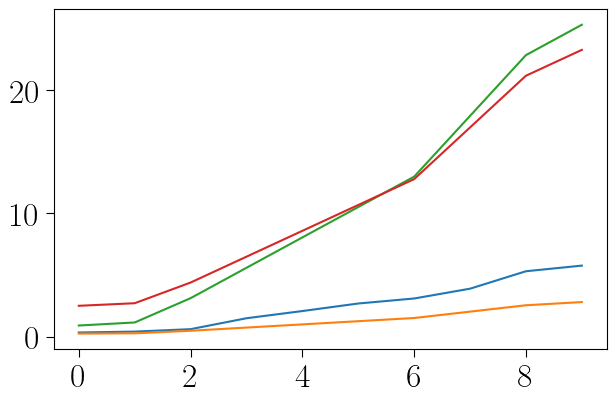

In [25]:
plt.plot(cost_victory_1.T)

In [26]:
cost_victory_1= cost_victory_1.T

In [27]:
cost_victory_1

array([[ 0.33530285,  0.24458193,  0.90304008,  2.50221668],
       [ 0.40960899,  0.27044682,  1.14956643,  2.71199051],
       [ 0.60704884,  0.47736593,  3.12177719,  4.39018115],
       [ 1.49321486,  0.73601481,  5.58704064,  6.48791945],
       [ 2.07716923,  0.99466369,  8.0523041 ,  8.58565775],
       [ 2.68872176,  1.25331258, 10.51756755, 10.68339605],
       [ 3.096058  ,  1.51196146, 12.982831  , 12.78113435],
       [ 3.89125854,  2.02925922, 17.91335791, 16.97661096],
       [ 5.30682124,  2.54655699, 22.84388481, 21.17208756],
       [ 5.76348214,  2.80520587, 25.30914827, 23.26982586]])

In [70]:

cost_victory_1 = np.zeros((3,3))
cost_victory_1[0,:] = cost_total_eta_2_Aztec_ext
cost_victory_1[1,:] = cost_total_eta_2_Aztec_old
cost_victory_1[2,:] = cost_total_eta_2_Deepcog

In [71]:

cost_victory_10 = np.zeros((3,3))
cost_victory_10[0,:] = cost_total_eta_2_Aztec_ext_eta_10
cost_victory_10[1,:] = cost_total_eta_2_Aztec_old_eta_10
cost_victory_10[2,:] = cost_total_eta_2_Deepcog_eta_10

In [72]:

cost_victory_20 = np.zeros((3,3))
cost_victory_20[0,:] = cost_total_eta_2_Aztec_ext_eta_20
cost_victory_20[1,:] = cost_total_eta_2_Aztec_old_eta_20
cost_victory_20[2,:] = cost_total_eta_2_Deepcog_eta_20

In [73]:
cost_victory_1

array([[0.29150885, 0.29150885, 0.29150885],
       [0.29303539, 0.29303539, 0.29303539],
       [1.12621791, 1.12621791, 1.12621791]])

## Fig 5 a

In [61]:
cost_victory_1

array([[ 0.3503556 ,  0.42755887,  0.62431442,  1.50209381,  2.1061878 ,
         2.69646761,  3.0971671 ,  3.91361649,  5.2975855 ,  5.7252461 ],
       [ 0.27060655,  0.32241248,  0.73685991,  1.25491921,  1.7729785 ,
         2.29103779,  2.80909709,  3.84521567,  4.88133426,  5.39939356],
       [ 0.90304008,  1.14956643,  3.12177719,  5.58704064,  8.0523041 ,
        10.51756755, 12.982831  , 17.91335791, 22.84388481, 25.30914827],
       [ 2.50221668,  2.71199051,  4.39018115,  6.48791945,  8.58565775,
        10.68339605, 12.78113435, 16.97661096, 21.17208756, 23.26982586]])

In [58]:
# plt.rcParams['font.family'] = 'Times New Roman'

In [40]:
plt.style.use('/home/sergi_alcala/Matplotlib/style.mplstyle')

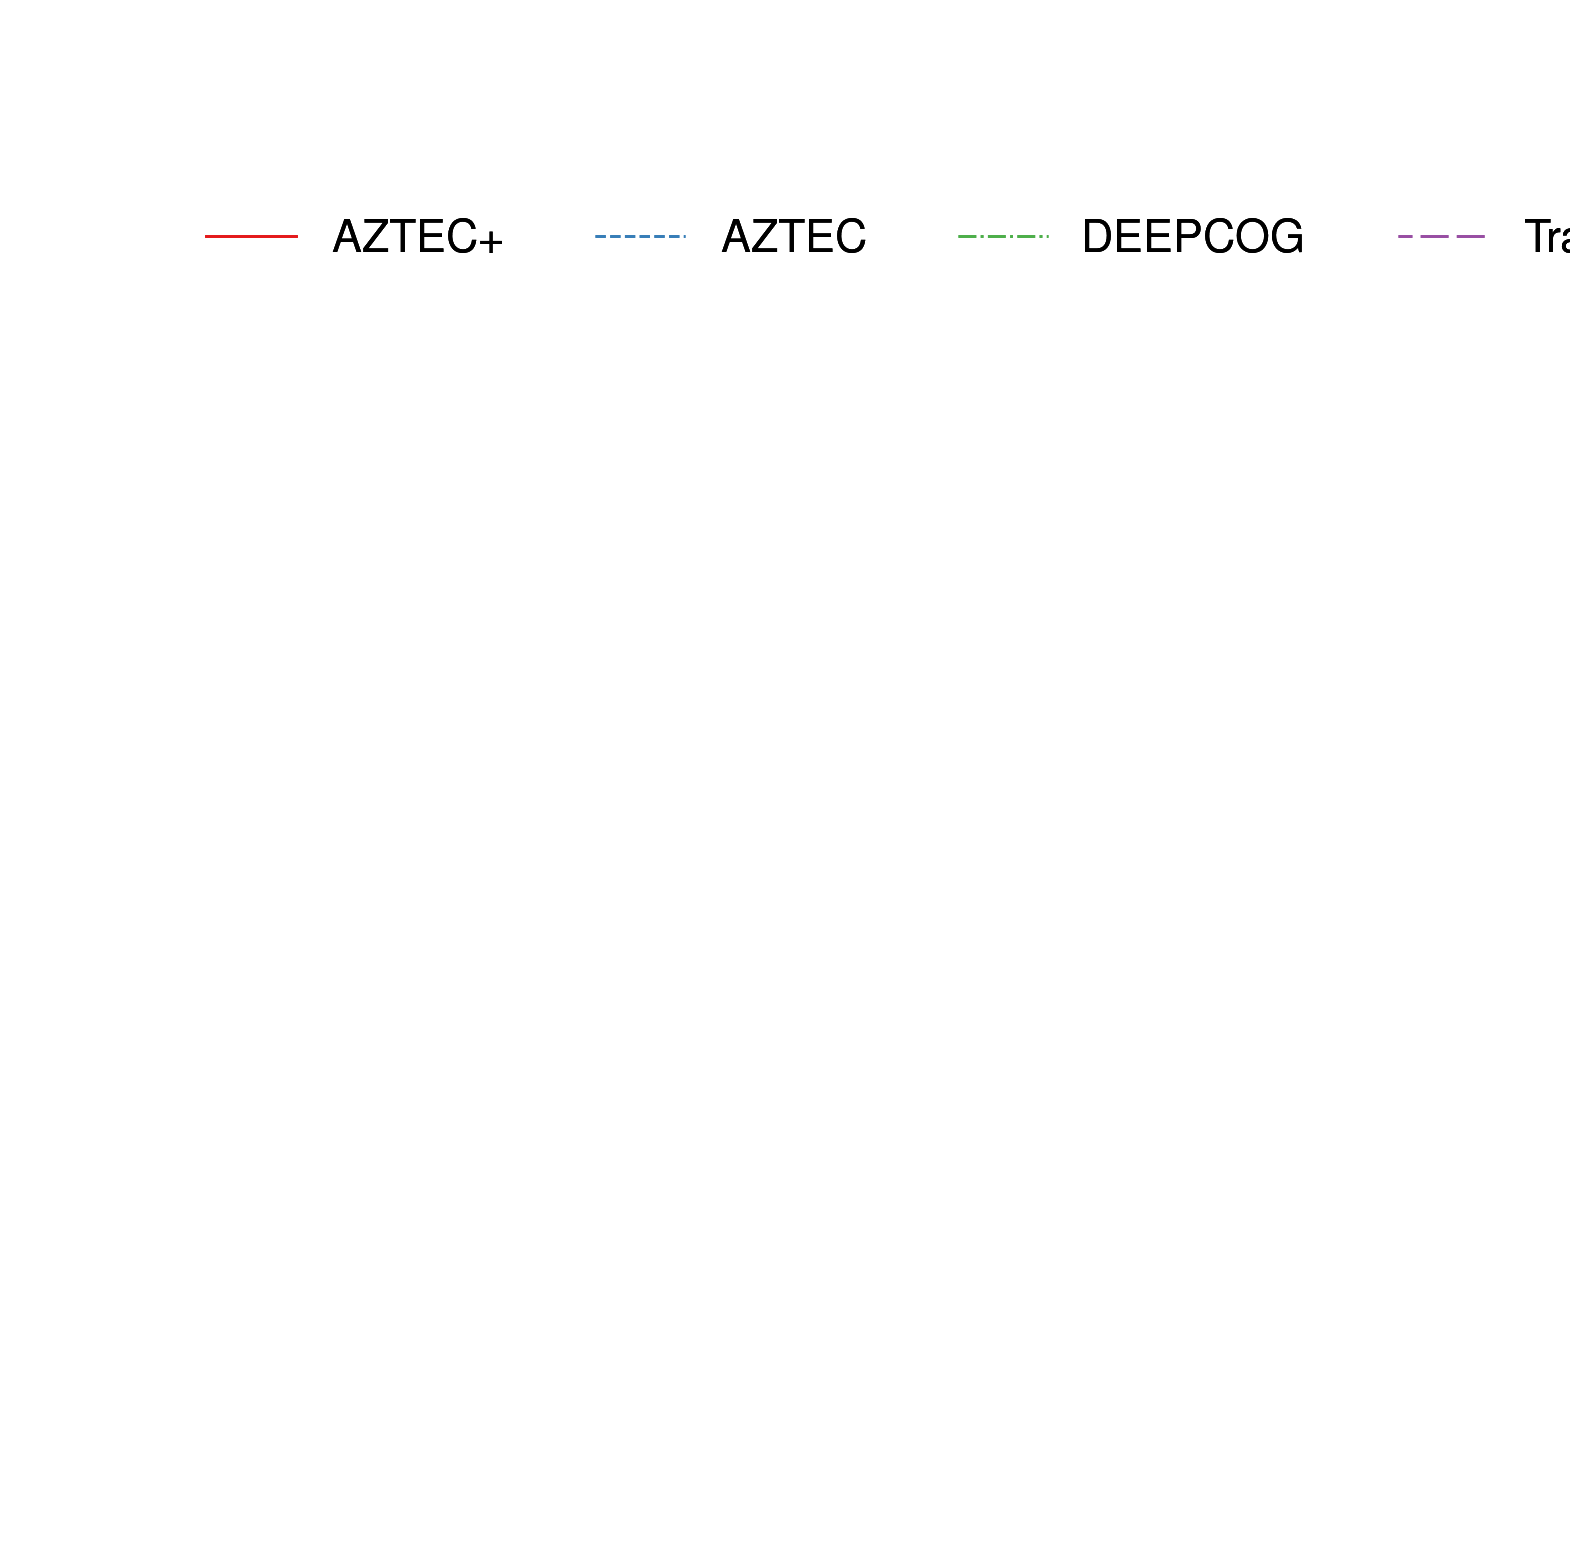

In [40]:


clrs = ['#e41a1c',
'#377eb8',
'#4daf4a',
'#984ea3']
lbs = ['AZTEC+','AZTEC','DEEPCOG','Traffic Predictor']
linestyles = ['-', '--', '-.', (5,(10,3))]

fig, ax = plt.subplots(figsize =(20,20))
legend_1_entries = [plt.Line2D([0], [0], color=clrs[0], lw=2,linestyle=linestyles[0], label=lbs[0]),
                        plt.Line2D([0], [0], color=clrs[1], lw=2,linestyle=linestyles[1], label=lbs[1]),
                        plt.Line2D([0], [0], color=clrs[2], lw=2,linestyle =linestyles[2], label=lbs[2]),
                        plt.Line2D([0], [0], color=clrs[3], lw=2,linestyle=linestyles[3], label=lbs[3])]
# legend_2_entries = [plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[0], label=r'$k_r = 0.1$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[1], label=r'$k_r = 0.5$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle =linestyles[2], label=r'$k_r = 1$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[3], label=r'$k_r = 10$')]

first_legend = ax.legend(handles=legend_1_entries,loc='upper left',fontsize='large',ncol=4,bbox_to_anchor=(0.1, 0.89),frameon = False)
ax.add_artist(first_legend)
# ax.legend(handles=legend_2_entries,loc='upper left',fontsize='large',ncol=4,bbox_to_anchor=(0.1, 0.85))
ax.axis('off')
fig.canvas.draw()
bbox = first_legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())




fig.savefig('../FIGS/LEGEND_Monetary_cost_new.png', dpi=300, bbox_inches='tight')
fig.savefig('../FIGS/LEGEND_Monetary_cost_new.pdf', dpi=300, bbox_inches='tight')
# fig.tight_layout()

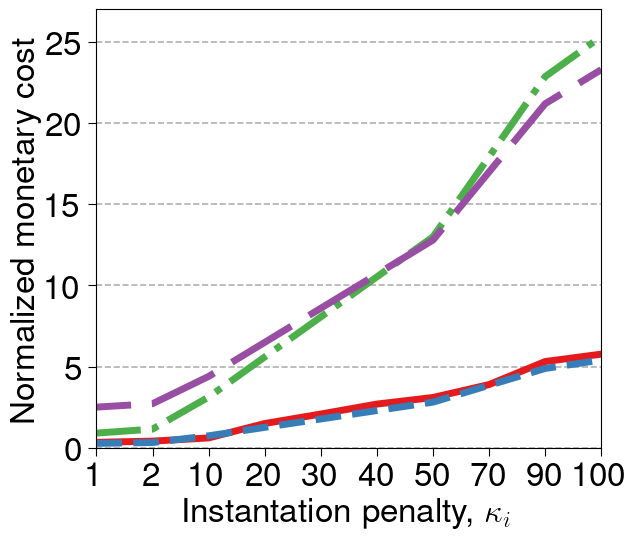

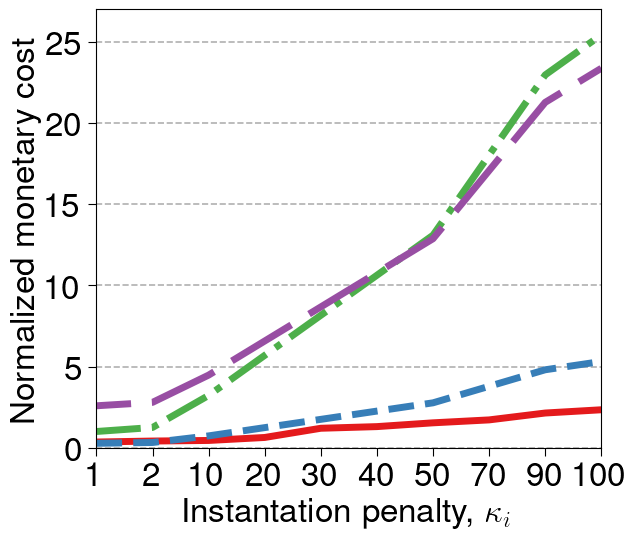

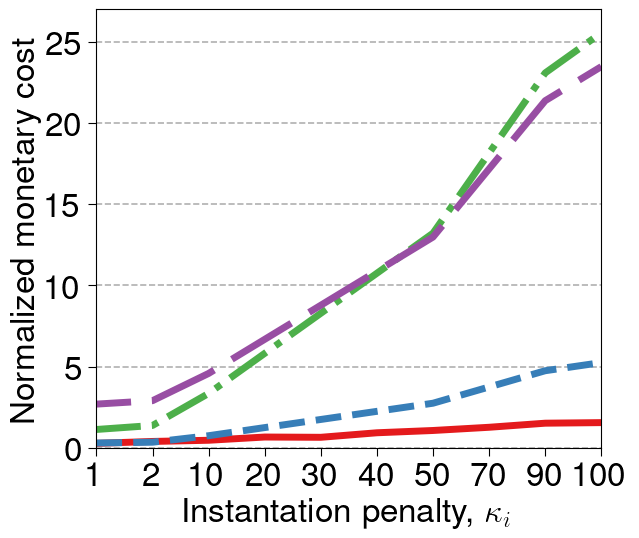

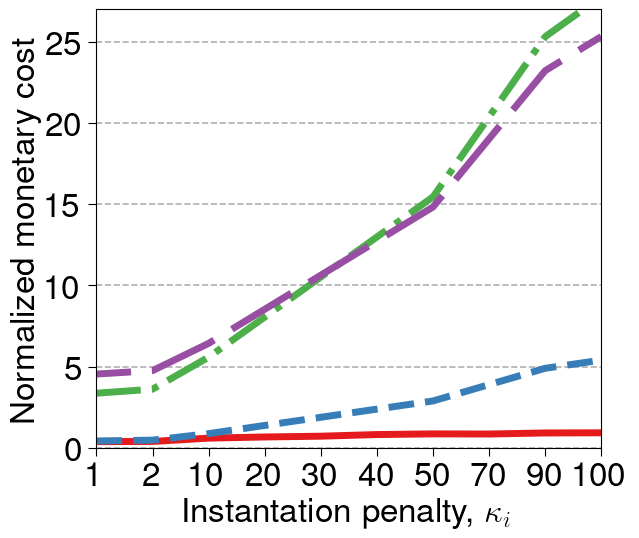

In [42]:
# fig, ax = plt.subplots(figsize = (10,10))

# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = 'Arial'
for phi_idx,phi in enumerate(Phis):


        array_eta_1 = np.array ( [all_costs[phi_idx,0,3], all_costs[phi_idx,0,2], all_costs[phi_idx,0,0], all_costs[phi_idx,0,1]]).reshape(-1)
        array_eta_2 = np.array ( [all_costs[phi_idx,1,3], all_costs[phi_idx,1,2], all_costs[phi_idx,1,0], all_costs[phi_idx,1,1]]).reshape(-1)
        array_eta_10 = np.array ( [all_costs[phi_idx,2,3], all_costs[phi_idx,2,2], all_costs[phi_idx,2,0], all_costs[phi_idx,2,1]]).reshape(-1)
        array_eta_20 = np.array ( [all_costs[phi_idx,3,3], all_costs[phi_idx,3,2], all_costs[phi_idx,3,0], all_costs[phi_idx,3,1]]).reshape(-1)
        array_eta_30 = np.array ( [all_costs[phi_idx,4,3], all_costs[phi_idx,4,2], all_costs[phi_idx,4,0], all_costs[phi_idx,4,1]]).reshape(-1)
        array_eta_40 = np.array ( [all_costs[phi_idx,5,3], all_costs[phi_idx,5,2], all_costs[phi_idx,5,0], all_costs[phi_idx,5,1]]).reshape(-1)
        array_eta_50 = np.array ( [all_costs[phi_idx,6,3], all_costs[phi_idx,6,2], all_costs[phi_idx,6,0], all_costs[phi_idx,6,1]]).reshape(-1)
        array_eta_70 = np.array ( [all_costs[phi_idx,7,3], all_costs[phi_idx,7,2], all_costs[phi_idx,7,0], all_costs[phi_idx,7,1]]).reshape(-1)
        array_eta_90 = np.array ( [all_costs[phi_idx,8,3], all_costs[phi_idx,8,2], all_costs[phi_idx,8,0], all_costs[phi_idx,8,1]]).reshape(-1)
        array_eta_100 = np.array ( [all_costs[phi_idx,9,3], all_costs[phi_idx,9,2], all_costs[phi_idx,9,0], all_costs[phi_idx,9,1]]).reshape(-1)


        cost_victory_1 = np.zeros((10,4))
        cost_victory_1[0,:] = array_eta_1
        cost_victory_1[1,:] = array_eta_2
        cost_victory_1[2,:] = array_eta_10
        cost_victory_1[3,:] = array_eta_20
        cost_victory_1[4,:] = array_eta_30
        cost_victory_1[5,:] = array_eta_40
        cost_victory_1[6,:] = array_eta_50
        cost_victory_1[7,:] = array_eta_70
        cost_victory_1[8,:] = array_eta_90
        cost_victory_1[9,:] = array_eta_100

        fig, ax = plt.subplots(figsize = (7,6))



        clrs = ['#e41a1c',
                '#377eb8',
                '#4daf4a',
                '#984ea3']



        costs = cost_victory_1

        x = np.arange(10,step=1)


        lbs = ['AZTEC+','AZTEC','DEEPCOG','Predictor']
        linestyles = ['-', '--', '-.', (5,(10,3))]
 
        for i in range(4):
                ax.plot(costs[:,i],clrs[i],label=lbs[i],linestyle=linestyles[i])


        ratios = np.true_divide(costs,costs[0,:])


        
        
        # legend_1_entries = [plt.Line2D([0], [0], color=clrs[0], lw=2, label=lbs[0]),
        #                         plt.Line2D([0], [0], color=clrs[1], lw=2, label=lbs[1]),
        #                         plt.Line2D([0], [0], color=clrs[2], lw=2, label=lbs[2]),
        #                         plt.Line2D([0], [0], color=clrs[3], lw=2, label=lbs[3])]
        # legend_2_entries = [plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[0], label='phi = 0.1'),
        #                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[1], label='phi = 0.5'),
        #                         plt.Line2D([0], [0], color='black', lw=2, linestyle =linestyles[2], label='phi = 1'),
        #                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[3], label='phi = 10')]
        
        # first_legend = ax.legend(handles=legend_1_entries,loc='upper left',fontsize='large',ncol=4)
        # ax.add_artist(first_legend)
        # ax.legend(handles=legend_2_entries,loc=6,fontsize='large',ncol=4)

        ax.set_xticks([0,1,2,3,4,5,6,7,8,9])
        ax.set_yticks([0,5,10,15,20,25])
        ax.set_yticklabels([0,5,10,15,20,25])
        
        ax.set_xticklabels([1,2,10,20,30,40,50,70,90,100])
        ax.set_xlim([0,9])
        ax.set_ylim([0,27])
  
        # if phi_idx == 0:
        ax.set_ylabel('Normalized monetary cost')
        ax.set_yticks([0,5,10,15,20,25])
        # else:
        #         ax.set_yticklabels([])

        ax.set_xlabel(r'Instantation penalty, $\kappa_i$')
        ax.grid(which='both', axis='y', linestyle='--')
        # ax.legend()

        plt.tight_layout()
        # plt.title(f' Normalized monetary cost for phi {phi}')
        # plt.savefig(f'../FIGS/Monetary_total_phi_{phi}.pdf',bbox_inches='tight')
        # plt.savefig(f'../FIGS/Monetary_total_phi_{phi}.png',bbox_inches='tight')

        ###### THESIS PLOT with y label
        plt.savefig(f'../FIGS/Monetary_total_phi_{phi}_Thesis.pdf',bbox_inches='tight')
        plt.savefig(f'../FIGS/Monetary_total_phi_{phi}_Thesis.png',bbox_inches='tight')
        
        # plt.show()


[[ 0.33530285  0.40960899  0.60704884  1.49321486  2.07716923  2.68872176
   3.096058    3.89125854  5.30682124  5.76348214]
 [ 0.27060655  0.32241248  0.73685991  1.25491921  1.7729785   2.29103779
   2.80909709  3.84521567  4.88133426  5.39939356]
 [ 0.90304008  1.14956643  3.12177719  5.58704064  8.0523041  10.51756755
  12.982831   17.91335791 22.84388481 25.30914827]
 [ 2.50221668  2.71199051  4.39018115  6.48791945  8.58565775 10.68339605
  12.78113435 16.97661096 21.17208756 23.26982586]]
[[ 0.35422842  0.41488761  0.45060365  0.63467053  1.20101376  1.3026699
   1.53554607  1.71567525  2.13869511  2.33923675]
 [ 0.27443308  0.32528186  0.7320721   1.2405599   1.7490477   2.2575355
   2.7660233   3.7829989   4.7999745   5.3084623 ]
 [ 1.00223023  1.24875657  3.22096733  5.68623079  8.15149424 10.61675769
  13.08202115 18.01254805 22.94307496 25.40833841]
 [ 2.58441947  2.7941933   4.47238394  6.57012224  8.66786054 10.76559884
  12.86333714 17.05881375 21.25429035 23.35202865]]


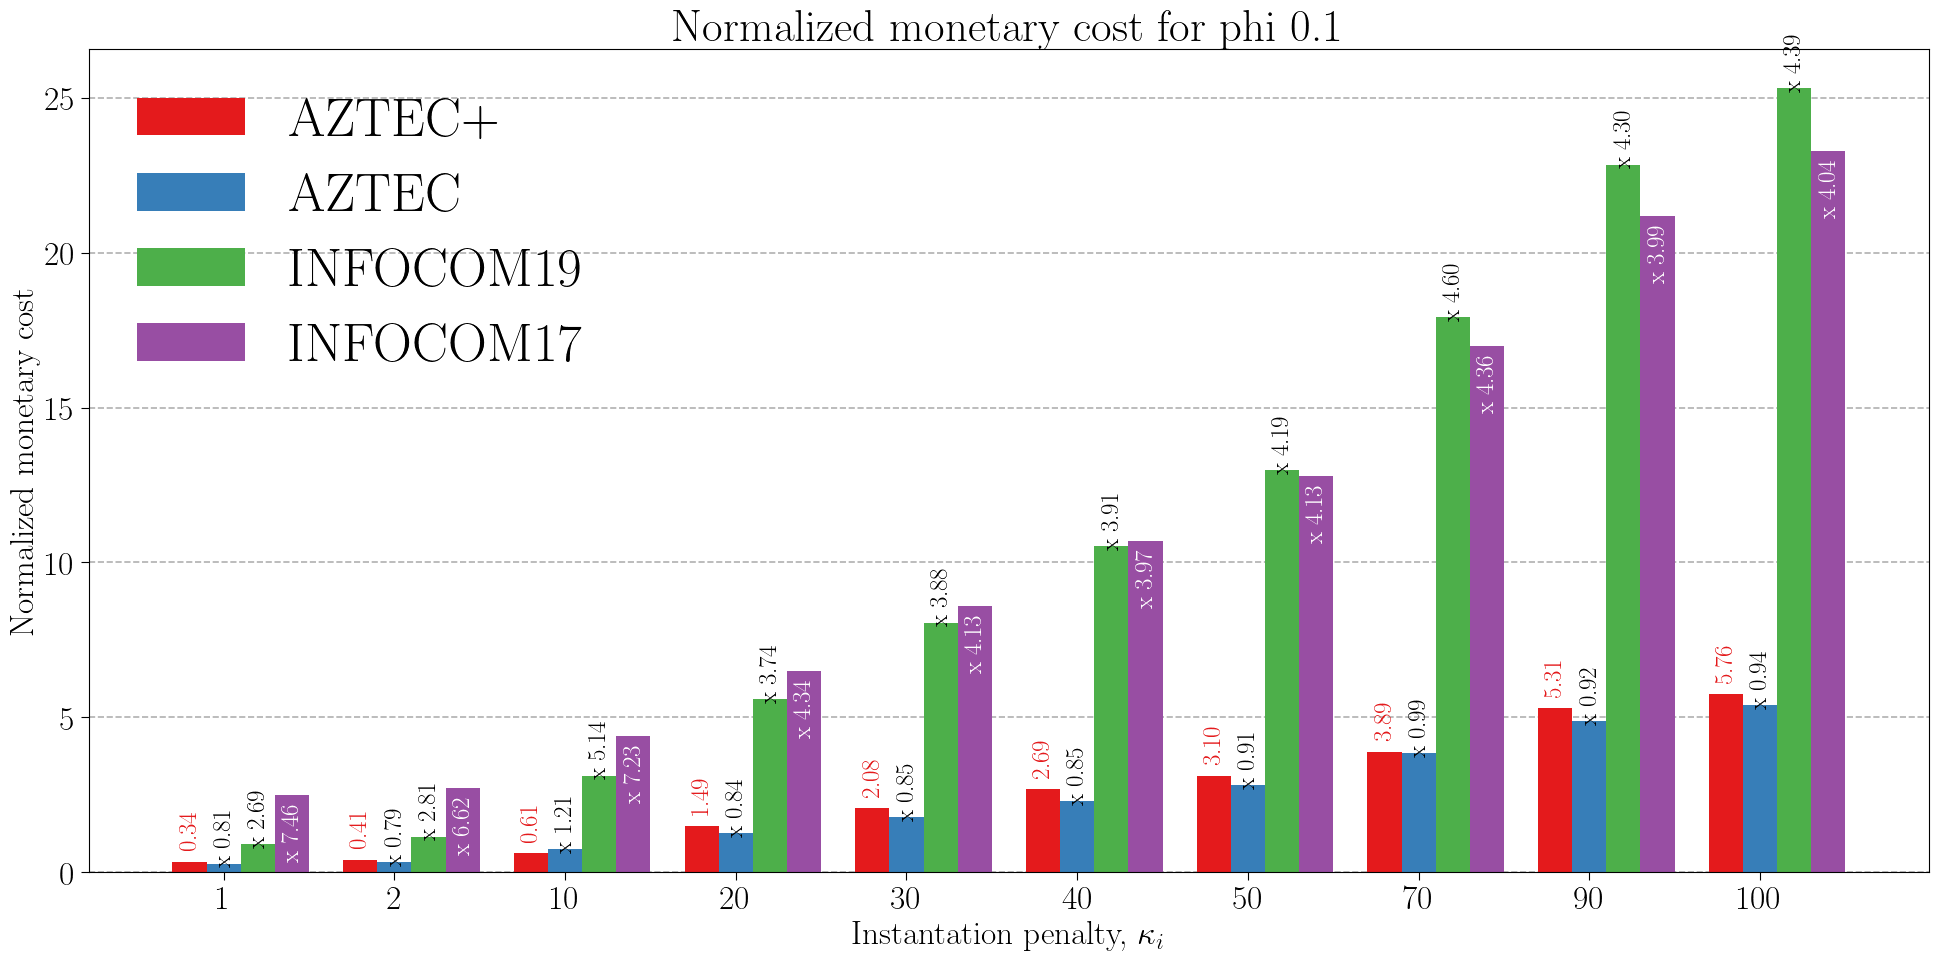

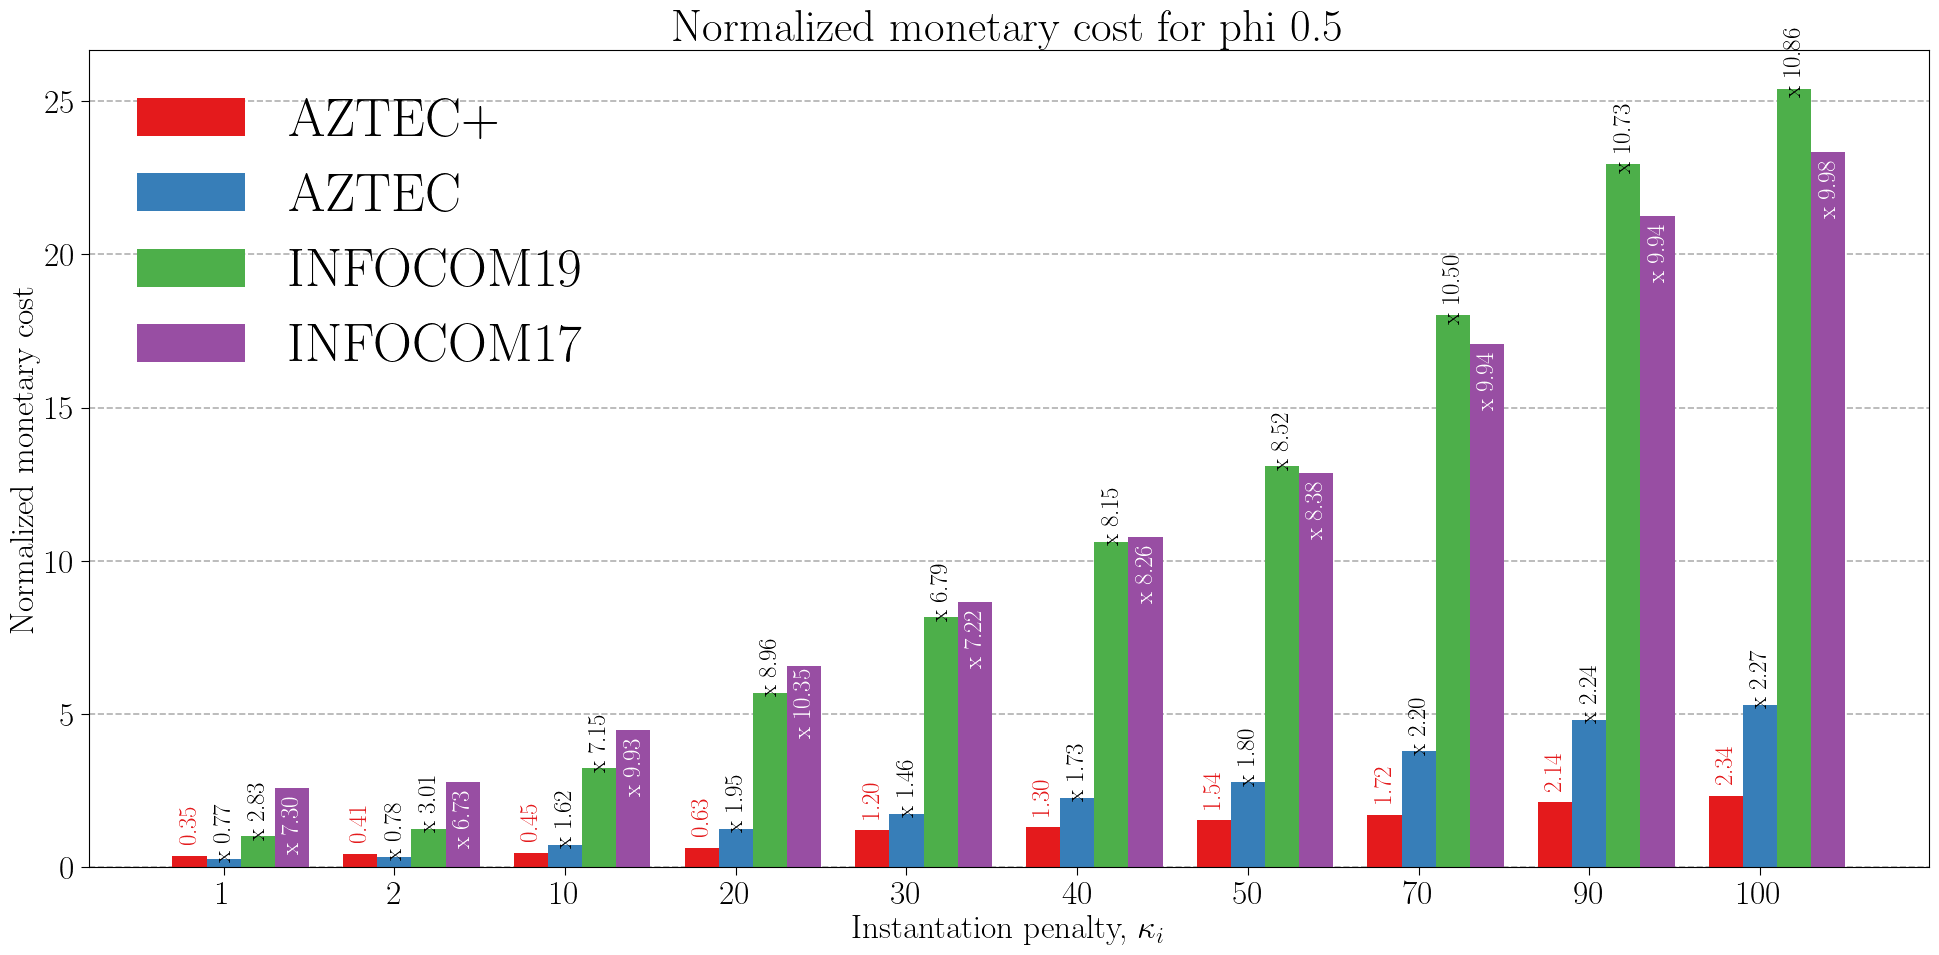

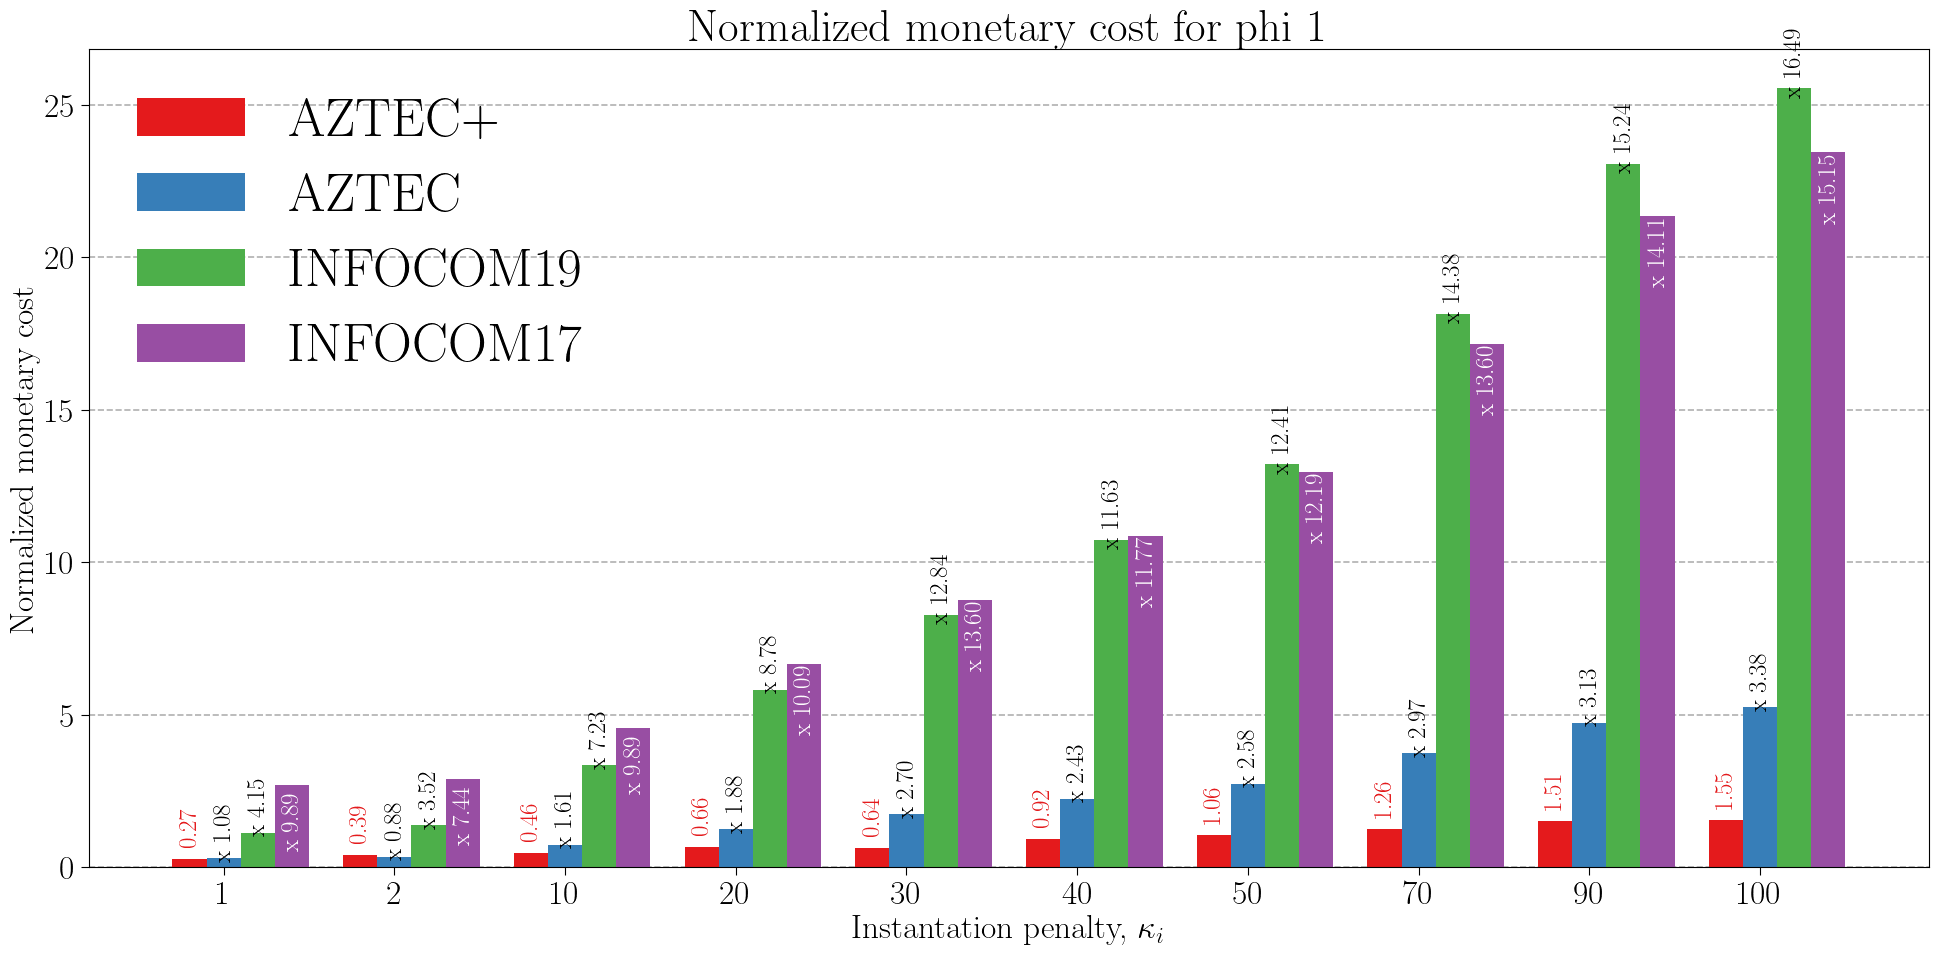

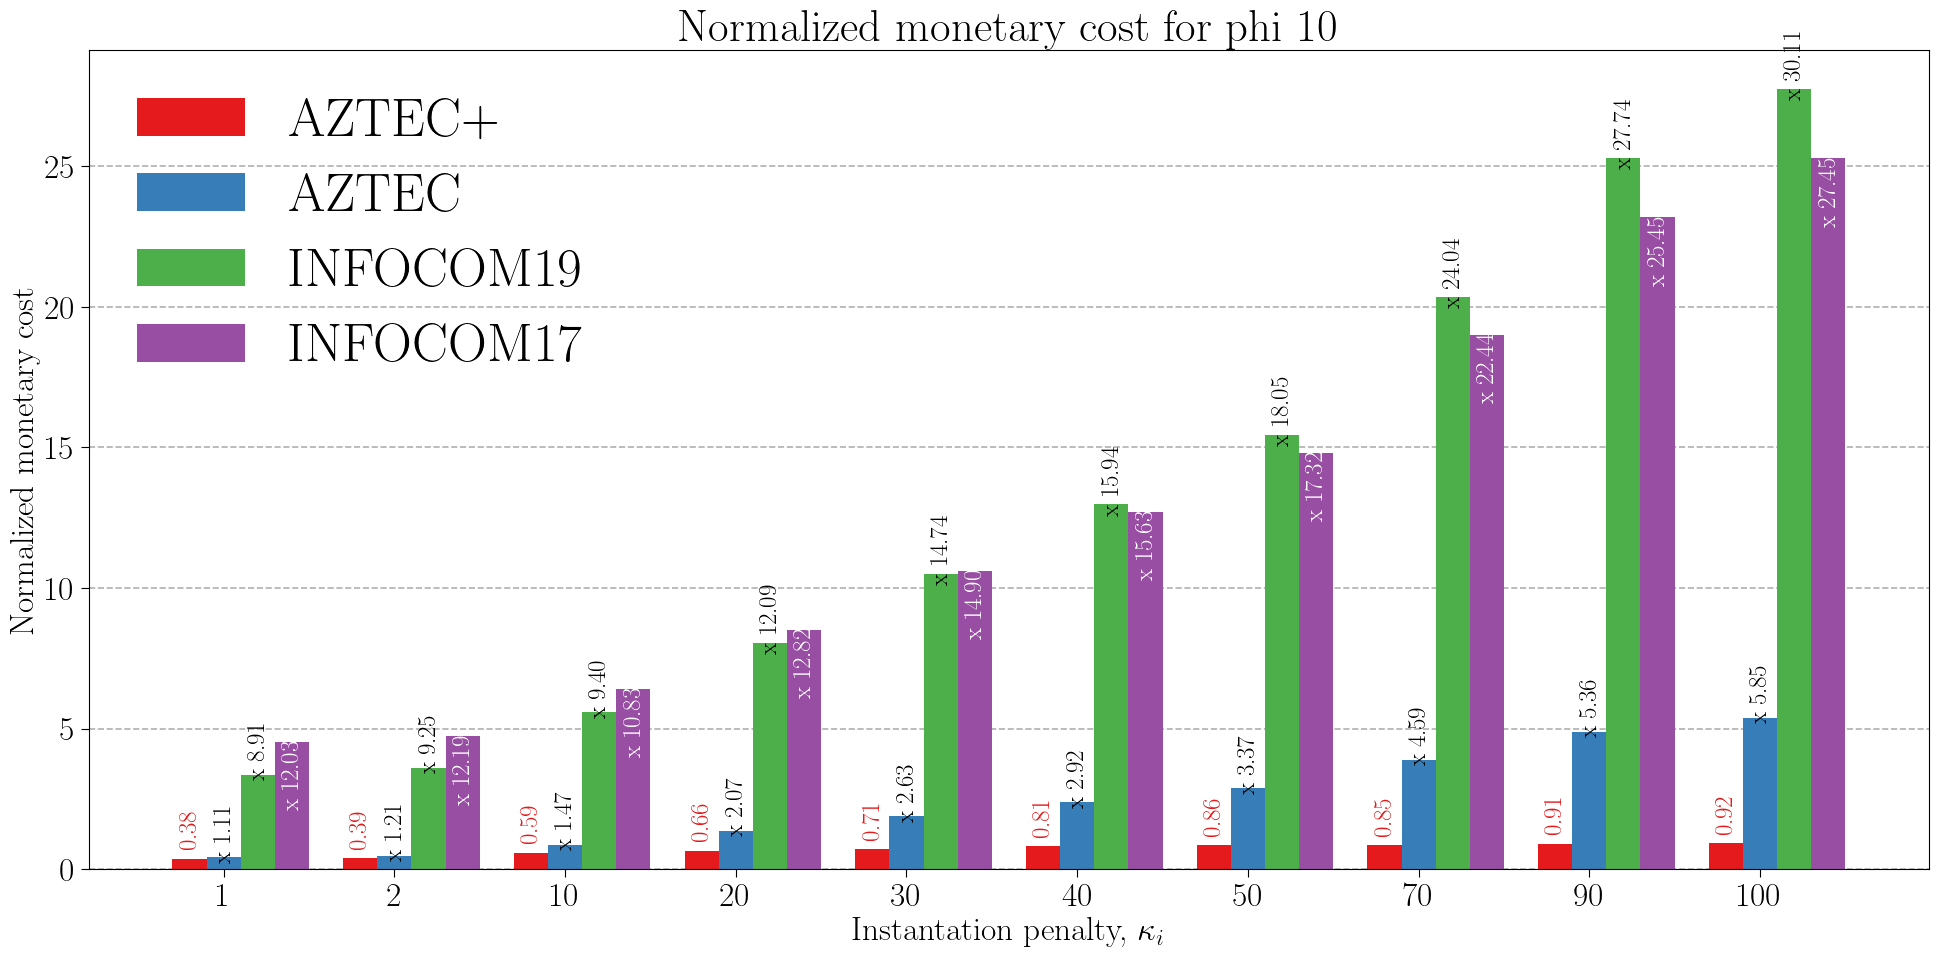

In [52]:
for phi_idx,phi in enumerate(Phis):


    array_eta_1 = np.array ( [all_costs[phi_idx,0,3], all_costs[phi_idx,0,2], all_costs[phi_idx,0,0], all_costs[phi_idx,0,1]]).reshape(-1)
    array_eta_2 = np.array ( [all_costs[phi_idx,1,3], all_costs[phi_idx,1,2], all_costs[phi_idx,1,0], all_costs[phi_idx,1,1]]).reshape(-1)
    array_eta_10 = np.array ( [all_costs[phi_idx,2,3], all_costs[phi_idx,2,2], all_costs[phi_idx,2,0], all_costs[phi_idx,2,1]]).reshape(-1)
    array_eta_20 = np.array ( [all_costs[phi_idx,3,3], all_costs[phi_idx,3,2], all_costs[phi_idx,3,0], all_costs[phi_idx,3,1]]).reshape(-1)
    array_eta_30 = np.array ( [all_costs[phi_idx,4,3], all_costs[phi_idx,4,2], all_costs[phi_idx,4,0], all_costs[phi_idx,4,1]]).reshape(-1)
    array_eta_40 = np.array ( [all_costs[phi_idx,5,3], all_costs[phi_idx,5,2], all_costs[phi_idx,5,0], all_costs[phi_idx,5,1]]).reshape(-1)
    array_eta_50 = np.array ( [all_costs[phi_idx,6,3], all_costs[phi_idx,6,2], all_costs[phi_idx,6,0], all_costs[phi_idx,6,1]]).reshape(-1)
    array_eta_70 = np.array ( [all_costs[phi_idx,7,3], all_costs[phi_idx,7,2], all_costs[phi_idx,7,0], all_costs[phi_idx,7,1]]).reshape(-1)
    array_eta_90 = np.array ( [all_costs[phi_idx,8,3], all_costs[phi_idx,8,2], all_costs[phi_idx,8,0], all_costs[phi_idx,8,1]]).reshape(-1)
    array_eta_100 = np.array ( [all_costs[phi_idx,9,3], all_costs[phi_idx,9,2], all_costs[phi_idx,9,0], all_costs[phi_idx,9,1]]).reshape(-1)


    cost_victory_1 = np.zeros((10,4))
    cost_victory_1[0,:] = array_eta_1
    cost_victory_1[1,:] = array_eta_2
    cost_victory_1[2,:] = array_eta_10
    cost_victory_1[3,:] = array_eta_20
    cost_victory_1[4,:] = array_eta_30
    cost_victory_1[5,:] = array_eta_40
    cost_victory_1[6,:] = array_eta_50
    cost_victory_1[7,:] = array_eta_70
    cost_victory_1[8,:] = array_eta_90
    cost_victory_1[9,:] = array_eta_100

    cost_victory_1= cost_victory_1.T

    # fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
    fig, ax = plt.subplots(figsize = (20,10))



    clrs = ['#e41a1c',
            '#377eb8',
            '#4daf4a',
            '#984ea3']


    costs = cost_victory_1

    print(costs)

    x = np.arange(10,step=1)


    lbs = ['AZTEC+','AZTEC','INFOCOM19','INFOCOM17']

    width = 0.2
    for i in range(4):
        ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbs[i])
        # ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbs[i])
    



    ratios = np.true_divide(costs,costs[0,:])


    weight = 'bold'
    fontsize = 18

    offset = 0.85
    offset_upper = 1.2
    for i in range(1,4):
        for j in range ( 10):
            if i == 3:
                ax.text(x[j]+i*width,costs[i,j] - offset_upper,'x %.2f' % ratios[i,j], weight = weight,
                horizontalalignment='center',verticalalignment='center',
                    rotation='vertical',color='white',fontsize=fontsize)
           
    
            else:
            
                ax.text(x[j]+i*width,costs[i,j] + offset,'x %.2f' % ratios[i,j], weight = weight,
                    horizontalalignment='center',verticalalignment='center',
                        rotation='vertical',color='k',fontsize=fontsize)
            
        
        

        

    for i in range(10):
        ax.text(x[i],costs[0,i]+1,'%.2f' % costs[0,i], weight = weight,
               horizontalalignment='center',verticalalignment='center',
                rotation='vertical',color='#e41a1c',fontsize=fontsize)
        



    ax.set_xticks(x+1*width)
    # ax.set_xticklabels([0.1,1,10])
    ax.set_xticklabels([1,2,10,20,30,40,50,70,90,100])
    # ax.set_yticks([0,1,2,3,4])
    # ax.set_yticklabels([0,1,2,3,4])
    # ax.set_yticks([0,.5,1.5,2.5,3.5],minor=True)


    ax.set_ylabel('Normalized monetary cost')

    # ax.set_xlabel(r'Reconfiguration penalty, $\kappa_r$')
    ax.set_xlabel(r'Instantation penalty, $\kappa_i$')
    ax.grid(which='both', axis='y', linestyle='--')

    #ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
    #           ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

    ax.legend(ncol=1,fontsize='x-large')
    plt.tight_layout()
    plt.title(f' Normalized monetary cost for phi {phi}')
    # plt.savefig('../FIGS/Monetary_total_cost_all_test.pdf')
    # plt.savefig('../FIGS/Monetary_total_cost_all.png')
    # plt.show()


In [36]:
plt.rcParams['font.weight'] = 'bold'

# OLD PLOTS

In [79]:
costs[0]

array([0.29285272, 0.45078731, 0.64820556])

[[0.29285272 0.45078731 0.64820556]
 [0.29303539 0.49295894 0.74286338]
 [1.12621791 2.11232329 3.34495501]
 [2.68717296 3.52626828 4.57513743]]


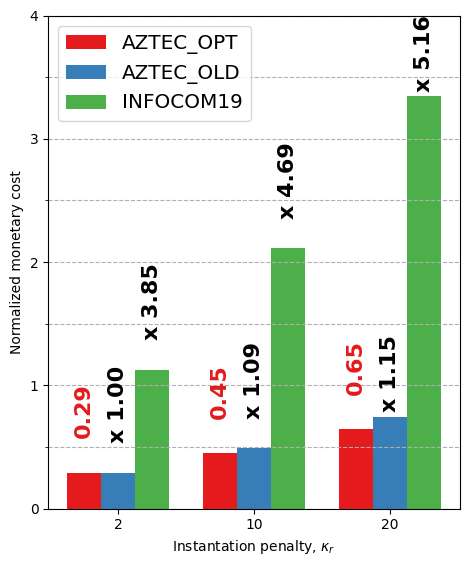

In [80]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))



clrs = ['#e41a1c',
        '#377eb8',
        '#4daf4a',
        '#984ea3']

costs = np.zeros((3,3))


costs = cost_victory_1

print(costs)

x = np.arange(3)


lbs = ['AZTEC_OPT','AZTEC_OLD','INFOCOM19']

width = 0.25
for i in range(3):
    ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbs[i])
  



ratios = np.true_divide(costs,costs[0,:])




for i in range(1,3):
    ax.text(x[0]+i*width,costs[i,0]+0.55,'x %.2f' % ratios[i,0], weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            rotation='vertical',color='k',fontsize=16)
    ax.text(x[1]+i*width,costs[i,1]+0.55,'x %.2f' % ratios[i,1], weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
            rotation='vertical',color='k',fontsize=16)
    ax.text(x[2]+i*width,costs[i,2]+0.35,'x %.2f' % ratios[i,2], weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
            rotation='vertical',color='k',fontsize=16)

for i in range(3):
    ax.text(x[i],costs[0,i]+0.5,'%.2f' % costs[0,i], weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            rotation='vertical',color='#e41a1c',fontsize=16)
    


#     for i in range(1,3):
#     ax.text(x[0]+i*width,costs[i,0]+0.55,r'$\times \textbf{%.2f}$' % ratios[i,0], weight = 'bold',
#            horizontalalignment='center',verticalalignment='center',
#             rotation='vertical',color='k',fontsize=16)
#     ax.text(x[1]+i*width,costs[i,1]+0.55,r'$\times \textbf{%.2f}$' % ratios[i,1], weight = 'bold',
#         horizontalalignment='center',verticalalignment='center',
#             rotation='vertical',color='k',fontsize=16)
#     ax.text(x[2]+i*width,costs[i,2]-0.55,r'$\times \textbf{%.2f}$' % ratios[i,2], weight = 'bold',
#         horizontalalignment='center',verticalalignment='center',
#             rotation='vertical',color='w',fontsize=16)

# for i in range(3):
#     ax.text(x[i],costs[0,i]+0.5,r'$\textbf{%.2f}$' % costs[0,i], weight = 'bold',
#            horizontalalignment='center',verticalalignment='center',
#             rotation='vertical',color='#e41a1c',fontsize=16)

ax.set_xticks(x+1*width)
# ax.set_xticklabels([0.1,1,10])
ax.set_xticklabels([2,10,20])
ax.set_yticks([0,1,2,3,4])
ax.set_yticklabels([0,1,2,3,4])
ax.set_yticks([0,.5,1.5,2.5,3.5],minor=True)


ax.set_ylabel('Normalized monetary cost')

# ax.set_xlabel(r'Reconfiguration penalty, $\kappa_r$')
ax.set_xlabel(r'Instantation penalty, $\kappa_r$')
ax.grid(which='both', axis='y', linestyle='--')

#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

ax.legend(ncol=1,fontsize='x-large')
plt.tight_layout()
plt.savefig('victory_1.pdf')
plt.show()




In [63]:
alphas = [2,3,5]

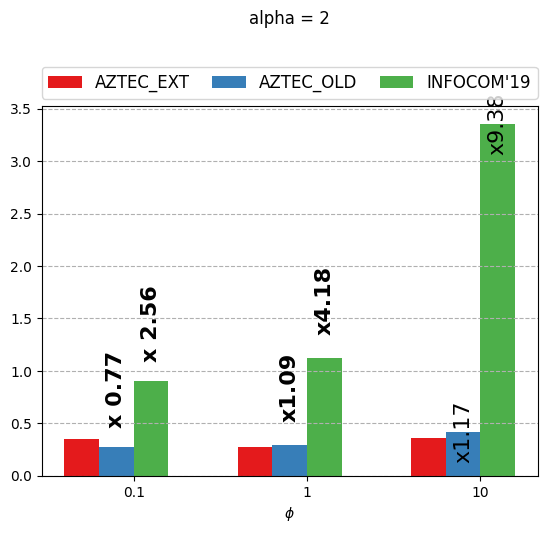

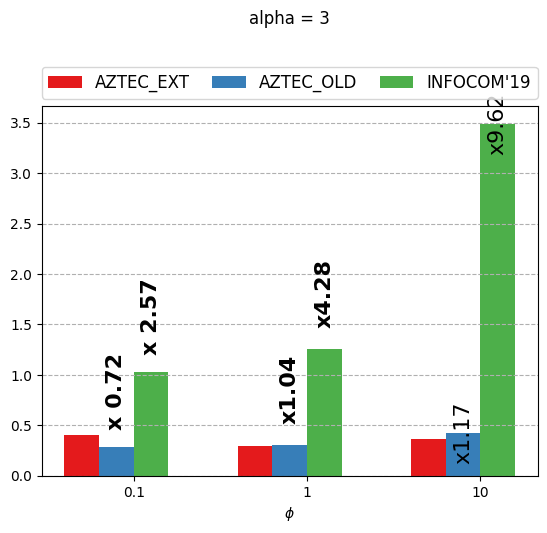

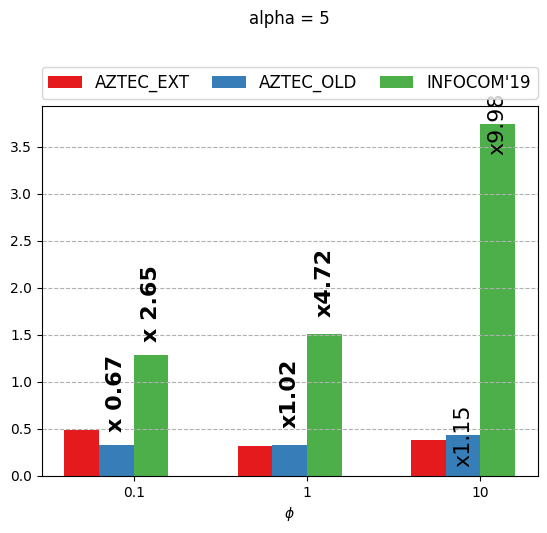

In [67]:
for alpha in alphas:
    fig,ax = plt.subplots()

    cost_total_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(F'_alpha_{alpha}_')]['total_costs'].to_numpy()
    cost_total_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(F'_alpha_{alpha}_')]['total_costs'].to_numpy()
    cost_total_eta_2_Deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(F'_alpha_{alpha}_')]['total_cost'].to_numpy()
    
    cost_victory_2 = np.zeros((3,3))
    cost_victory_2[0,:] = cost_total_eta_2_Aztec_ext
    cost_victory_2[1,:] = cost_total_eta_2_Aztec_old
    cost_victory_2[2,:] = cost_total_eta_2_Deepcog


    clrs = ['#e41a1c',
            '#377eb8',
            '#4daf4a',
            '#984ea3']

    costs = cost_victory_2

   


    x = np.arange(3)


    lbs = ['AZTEC_EXT','AZTEC_OLD','INFOCOM\'19']
    #lbs = ['ORACLE', 'AZTEC','INFOCOM\'19','INFOCOM\'17']
    #lbs = ['Oracle', 'AZTEC','INFOCOM\'19']

    width = 0.2
    for i in range(3):
        ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbs[i])
        #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')


        
    #ax.set_yscale("log", nonposy='clip')
    



    ratios = np.true_divide(costs,costs[0,:])

    # ratios = (np.true_divide(costs,costs[0,:])-1)*100


    for i in range(1,3):
        ax.text(x[0]+i*width,costs[i,0]+0.55,'x %.2f' % ratios[i,0], weight = 'bold',
               horizontalalignment='center',verticalalignment='center',
                rotation='vertical',color='k',fontsize=16)
        ax.text(x[1]+i*width,costs[i,1]+0.55,'x%.2f' % ratios[i,1],
               horizontalalignment='center',verticalalignment='center',
                rotation='vertical',color='k',fontsize=16,fontweight=1000)
        ax.text(x[2]+i*width,costs[i,2],'x%.2f' % ratios[i,2],
               horizontalalignment='center',verticalalignment='center',
                rotation='vertical',color='k',fontsize=16)



    #for i,r in enumerate(ratios):
    #    ax.text(x_d[i], 2*c_d[i], '+%.2f' % r + '\%' , 
    #            horizontalalignment='center',verticalalignment='center',fontsize=20)

    ax.set_xticks(x+1.5*width)
    ax.set_xticklabels([0.1,1,10])
#     ax.set_yticks([1,10,100])
#     ax.set_yticklabels([1,10,100])
    #ax.set_ylim(top=10)

    ax.set_xlabel('$\phi$')
    ax.grid(which='major', axis='y', linestyle='--')

    ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
               ncol=4, mode="expand", borderaxespad=0.,fontsize='large')
    #ax.legend(ncol=4,fontsize='large',bbox_to_anchor=(0.5, 1.05))
    ax.set_title(F'alpha = {alpha}',y=1.2)
    # plt.tight_layout()
    #plt.savefig('victory_1_beta_%s.pdf' % step)
    plt.show()


# Capacity plots

In [ ]:
sla_list_np[0,:]

In [13]:
len_list_np[]

array([[[3561., 3555., 3547., 3497., 3497., 3497., 3497., 3497., 3497.,
         3497.],
        [3561., 3555., 3561., 3547., 3525., 3497., 3497., 3497., 3497.,
         3497.],
        [3570., 3561., 3561., 3549., 3547., 3534., 3497., 3497., 3497.,
         3497.],
        [3570., 3570., 3561., 3561., 3561., 3561., 3561., 3497., 3497.,
         3497.]],

       [[3561., 3555., 3547., 3497., 3497., 3497., 3497., 3497., 3497.,
         3497.],
        [3561., 3555., 3561., 3547., 3525., 3497., 3497., 3497., 3497.,
         3497.],
        [3570., 3561., 3561., 3549., 3547., 3534., 3497., 3497., 3497.,
         3497.],
        [3570., 3570., 3561., 3561., 3561., 3561., 3561., 3497., 3497.,
         3497.]],

       [[3561., 3555., 3547., 3497., 3497., 3497., 3497., 3497., 3497.,
         3497.],
        [3561., 3555., 3561., 3547., 3525., 3497., 3497., 3497., 3497.,
         3497.],
        [3570., 3561., 3561., 3549., 3547., 3534., 3497., 3497., 3497.,
         3497.],
        [3570., 3

In [ ]:
len_list_np = np.zeros((len(Alphas),len(Phis),len(ETAS)))
sla_list_np = np.zeros ((len(Alphas),len(Phis),len(ETAS),num_services))

In [21]:
Phis

[0.1, 0.5, 1, 10]

In [19]:
len_list_array = np.array(len_list_np[0,:,0])

In [22]:
perc_sla = np.mean(sla_list_np[0,:,0]/len_list_array.reshape(-1,1),axis=1)*100


In [23]:
perc_sla

array([3.54394833, 2.80258354, 1.1092437 , 0.42577031])

In [24]:
static_list_np.shape

(3, 4, 10)

In [25]:
static_list_np[0,:,0]

array([2.42785645e+14, 2.92841857e+14, 3.06628767e+14, 3.72559943e+14])

In [12]:
len_list_np_6.shape

(3, 4)

[[9.06624762e-01 9.60501381e-01 9.88954464e-01 9.99664651e-01]
 [9.33752382e-02 3.94986191e-02 1.10455358e-02 3.35349260e-04]]


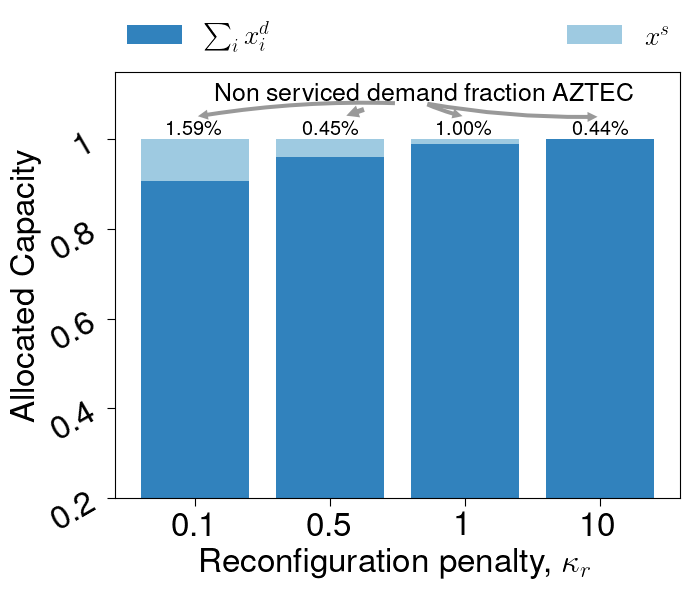

In [17]:
# plt.rcParams.update({'font.size': 20})



# fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
fig, ax = plt.subplots(figsize = (7,6))

len_list_array = np.array(len_list_np_6[0,:])


perc_sla = np.mean(sla_list_np_6[0,:]/len_list_array.reshape(-1,1),axis=1)*100

shares = np.zeros((2,4))

shares[0,:] = static_list_np_6[0,:] # x_d
shares[1,:] = shared_list_np_6[0,:] # x_6

clrs = [
        '#deebf7',
        '#9ecae1',
        '#3182bd'
][::-1]



x = np.arange(4)

shares = np.true_divide(shares,np.sum(shares,axis=0))

print(shares)


#width = 0.1
#ax.bar(x,shares[0,:],width=width,color=clrs[0])
#ax.bar(x+width,shares[1,:],width=width,color=clrs[1])
#ax.bar(x+2*width,shares[2,:],width=width,color=clrs[2])


ax.bar(x,shares[0,:],color=clrs[0],label='$\sum_i x_i^d$')
ax.bar(x,shares[1,:],color=clrs[1],bottom=shares[0,:],label='$x^s$')
#ax.bar(x,shares[2,:],color=clrs[2],bottom=shares[0,:]+shares[1,:])

#ax.set_yscale("log", nonposy='clip')


for i in range(4):
        ax.text(x[i],1.02, "%.2f" % perc_sla[i] + r"\%", 
                horizontalalignment='center',verticalalignment='center',fontsize='x-large')

ax.set_xticks(range(4))
ax.set_xticklabels([0.1,0.5,1,10])
ax.set_yticks([0.2,0.4,0.6,0.8,1])
ax.set_ylabel('Allocated Capacity')
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1'],rotation=30)
ax.set_xlabel(r"Reconfiguration penalty, $\kappa_r$")
el = Ellipse((2, -1), 0.5, 0.5)

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
        ncol=2, mode="expand", borderaxespad=0.,fontsize=20)
ax.set_ylim(bottom=0.2,top=1.15)
#ax.legend()

ax.annotate(f"Non serviced demand fraction AZTEC", xy=(1.1, 1.05), xytext=(1.7,1.1), 
        arrowprops=dict(arrowstyle="simple",
                        fc="0.6", ec="none",
                        patchB=el,
                        connectionstyle="arc3,rad=0.05"),weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
        color='k',fontsize=18)

ax.annotate("", xy=(0, 1.05), xytext=(1.5,1.08), 
        arrowprops=dict(arrowstyle="simple",
                        fc="0.6", ec="none",
                        patchB=el,
                        connectionstyle="arc3,rad=0.05"),weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
        color='k',fontsize='x-large')

ax.annotate("", xy=(2, 1.05), xytext=(1.7,1.08), 
        arrowprops=dict(arrowstyle="simple",
                        fc="0.6", ec="none",
                        patchB=el,
                        connectionstyle="arc3,rad=0.05"),weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
        color='k',fontsize='x-large')
ax.annotate("", xy=(3, 1.05), xytext=(1.7,1.08), 
        arrowprops=dict(arrowstyle="simple",
                        fc="0.6", ec="none",
                        patchB=el,
                        connectionstyle="arc3,rad=0.05"),weight = 'bold',
        horizontalalignment='center',verticalalignment='center',
        color='k',fontsize='x-large')


# plt.savefig('allocated_capacity_shares.pdf')
# plt.tight_layout()
# ax.set_title('AZTEC_ NEW', y = 1.2)
plt.tight_layout()
# plt.savefig('../FIGS/allocated_capacity_shares.pdf')
# plt.savefig('../FIGS/allocated_capacity_shares.png')

# plt.show()

In [14]:
sla_list_np_6.shape

(3, 4, 5)

In [14]:
len_list_np.shape

(3, 4, 10)

In [15]:
len_list_np[0,:,i]

array([3497., 3547., 3549., 3561.])

In [17]:
ETAS

[1, 2, 10, 20, 30, 40, 50, 70, 90, 100]

In [18]:
Alphas

[2, 3, 5]

[[0.71007425 0.81333697 0.9083703  0.993566  ]
 [0.28992575 0.18666303 0.0916297  0.006434  ]]
[[0.61843257 0.73278039 0.85747022 0.99003992]
 [0.38156743 0.26721961 0.14252978 0.00996008]]
[[0.58363247 0.8039481  0.8639923  0.98879158]
 [0.41636753 0.1960519  0.1360077  0.01120842]]
[[0.32444339 0.68194171 0.78257507 0.99043777]
 [0.67555661 0.31805829 0.21742493 0.00956223]]
[[0.30479261 0.60682437 0.77093185 0.98540102]
 [0.69520739 0.39317563 0.22906815 0.01459898]]
[[0.29328319 0.46478426 0.74234484 0.99197566]
 [0.70671681 0.53521574 0.25765516 0.00802434]]
[[0.30620225 0.47913091 0.55685808 0.99125758]
 [0.69379775 0.52086909 0.44314192 0.00874242]]
[[0.32644954 0.49817964 0.55800261 0.93596827]
 [0.67355046 0.50182036 0.44199739 0.06403173]]
[[0.29125642 0.48793697 0.53867236 0.94046689]
 [0.70874358 0.51206303 0.46132764 0.05953311]]
[[0.30005137 0.47668171 0.54794125 0.94333021]
 [0.69994863 0.52331829 0.45205875 0.05666979]]


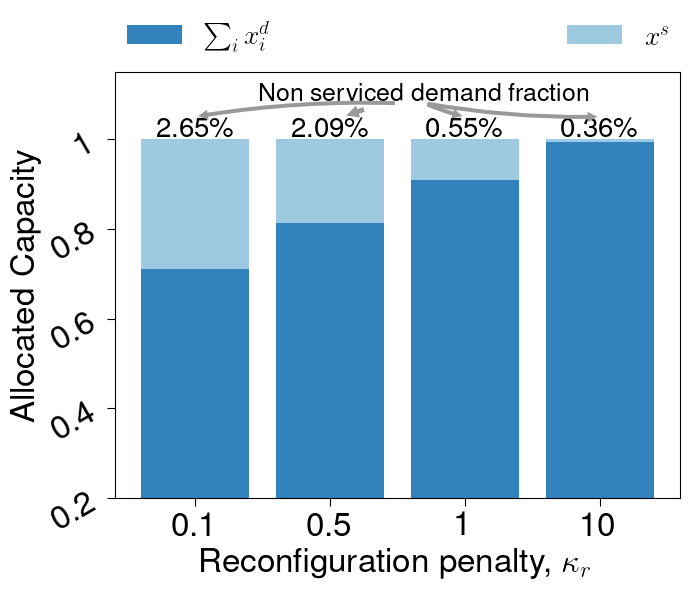

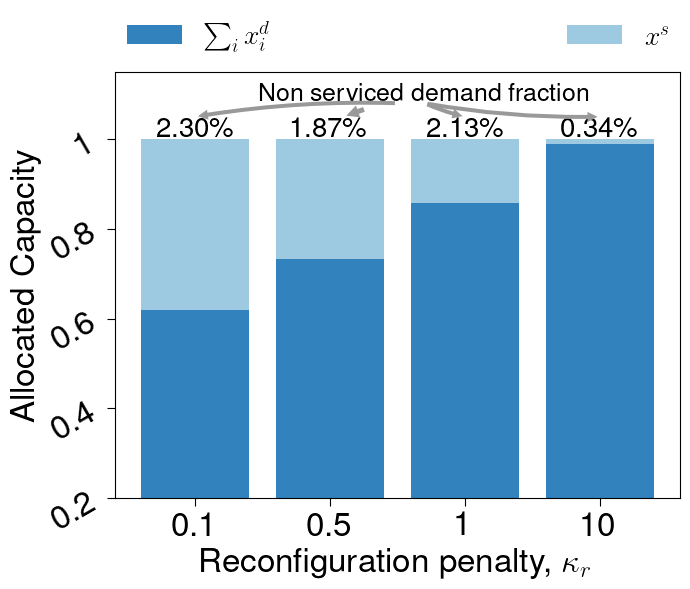

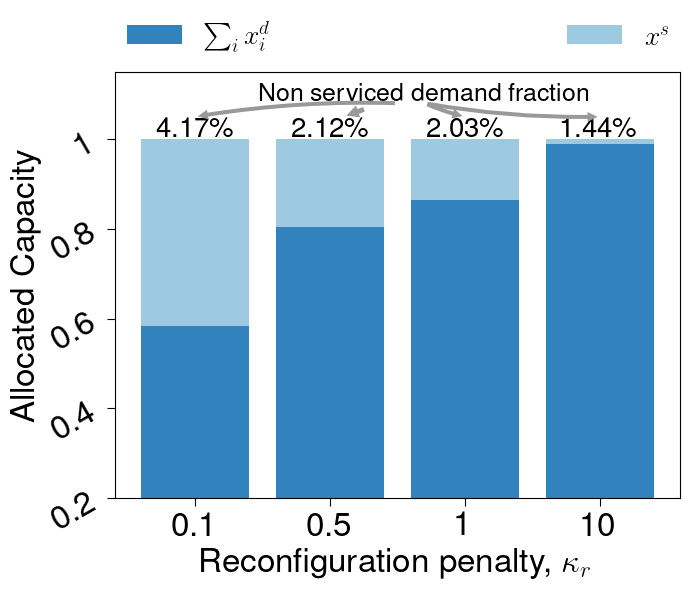

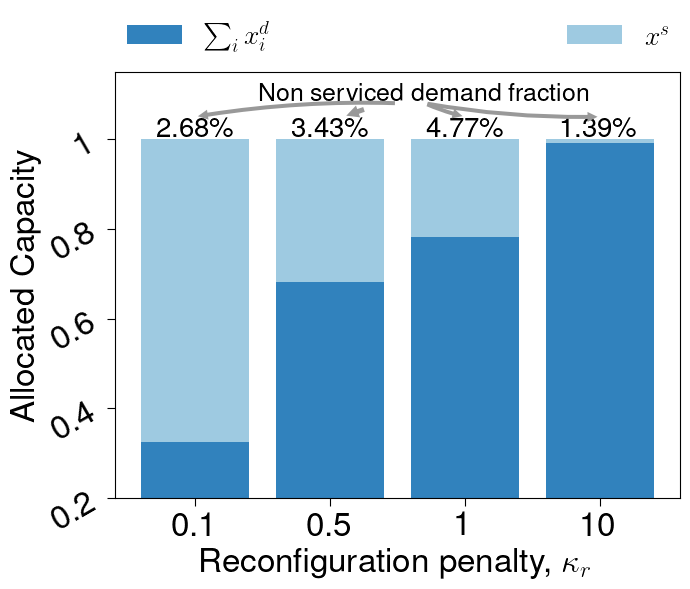

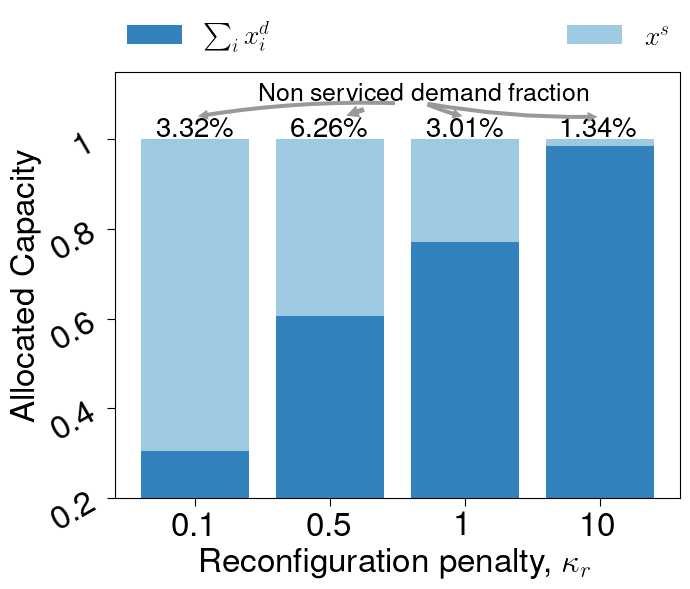

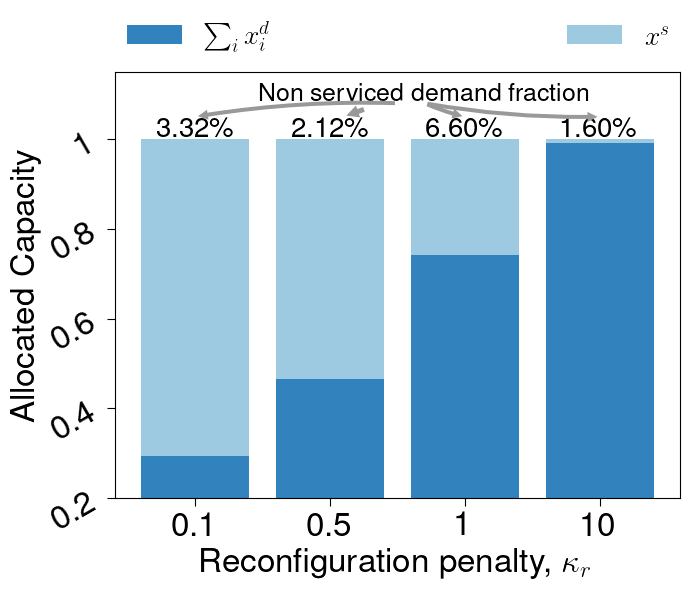

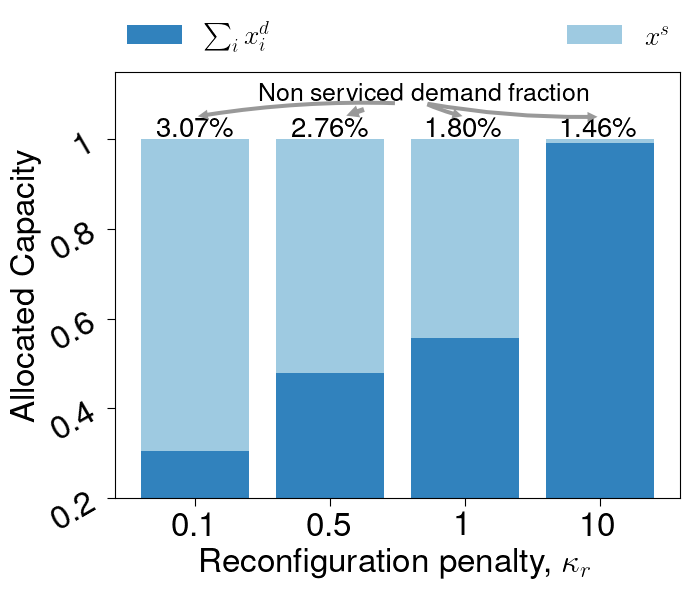

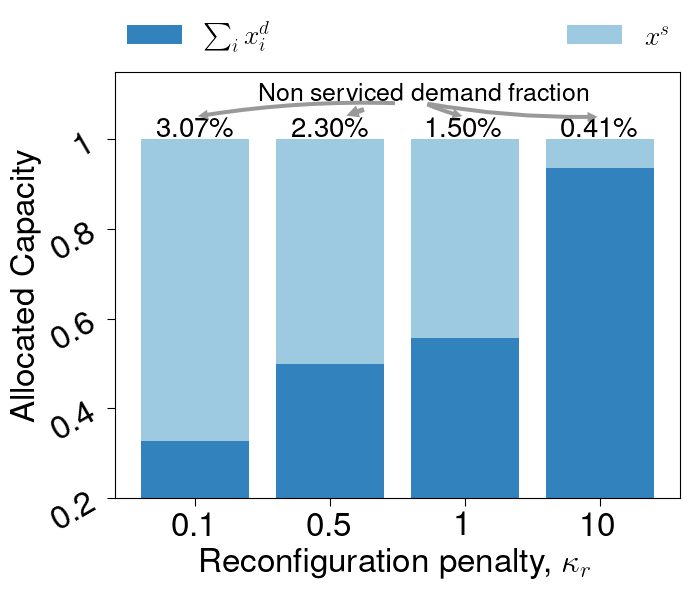

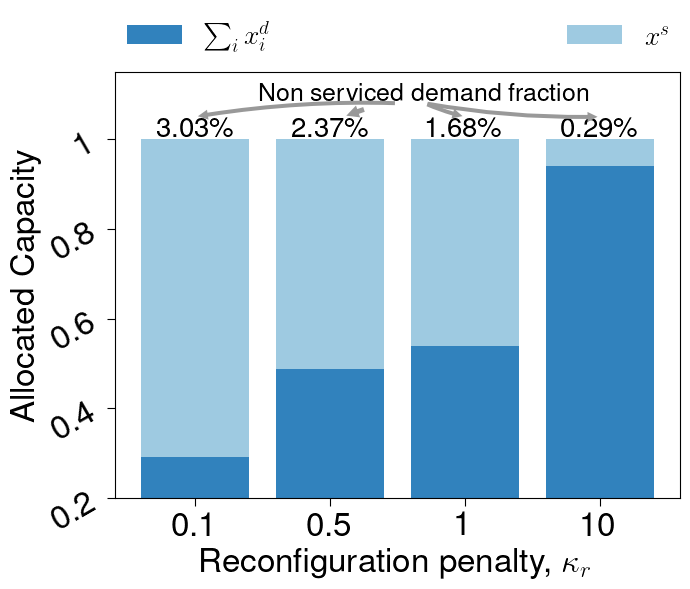

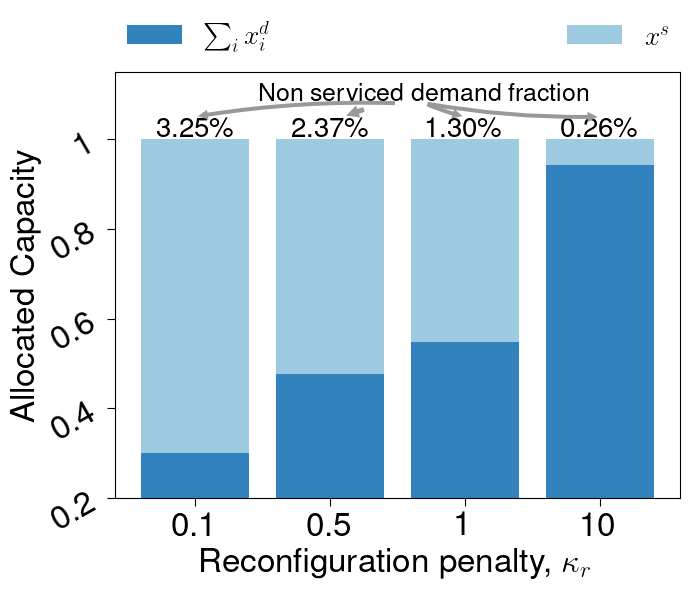

In [27]:
# plt.rcParams.update({'font.size': 20})

alpha_idx= 2
for i,eta in enumerate(ETAS):


        # fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
        fig, ax = plt.subplots(figsize = (7,6))

        len_list_array = np.array(len_list_np[alpha_idx,:,i])


        perc_sla = np.mean(sla_list_np[alpha_idx,:,i]/len_list_array.reshape(-1,1),axis=1)*100

        shares = np.zeros((2,4))

        shares[0,:] = static_list_np[alpha_idx,:,i] # x_d
        shares[1,:] = shared_list_np[alpha_idx,:,i] # x_6

        clrs = [
                '#deebf7',
                '#9ecae1',
                '#3182bd'
        ][::-1]



        x = np.arange(4)

        shares = np.true_divide(shares,np.sum(shares,axis=0))

        print(shares)


        #width = 0.1
        #ax.bar(x,shares[0,:],width=width,color=clrs[0])
        #ax.bar(x+width,shares[1,:],width=width,color=clrs[1])
        #ax.bar(x+2*width,shares[2,:],width=width,color=clrs[2])
        

        ax.bar(x,shares[0,:],color=clrs[0],label='$\sum_i x_i^d$')
        ax.bar(x,shares[1,:],color=clrs[1],bottom=shares[0,:],label='$x^s$')
        #ax.bar(x,shares[2,:],color=clrs[2],bottom=shares[0,:]+shares[1,:])
        
        #ax.set_yscale("log", nonposy='clip')

        fontsize = 20

        for i in range(4):
                ax.text(x[i],1.02, "%.2f" % perc_sla[i] + r"\%", 
                        horizontalalignment='center',verticalalignment='center',fontsize=fontsize)

        ax.set_xticks(range(4))
        ax.set_xticklabels([0.1,0.5,1,10])
        ax.set_yticks([0.2,0.4,0.6,0.8,1])
        ax.set_ylabel('Allocated Capacity')
        ax.set_yticklabels(['0.2','0.4','0.6','0.8','1'],rotation=30)
        ax.set_xlabel(r"Reconfiguration penalty, $\kappa_r$")
        el = Ellipse((2, -1), 0.5, 0.5)

        ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
                ncol=2, mode="expand", borderaxespad=0.,fontsize=20)
        ax.set_ylim(bottom=0.2,top=1.15)



        
        #ax.legend()
        # ax.annotate(f"Non serviced demand fraction for $k_i$ = {eta}", xy=(1.1, 1.05), xytext=(1.7,1.1),
        ax.annotate(f"Non serviced demand fraction", xy=(1.1, 1.05), xytext=(1.7,1.1), 
                arrowprops=dict(arrowstyle="simple",
                                fc="0.6", ec="none",
                                patchB=el,
                                connectionstyle="arc3,rad=0.05"),weight = 'bold',
                horizontalalignment='center',verticalalignment='center',
                color='k',fontsize=18)

        ax.annotate("", xy=(0, 1.05), xytext=(1.5,1.08), 
                arrowprops=dict(arrowstyle="simple",
                                fc="0.6", ec="none",
                                patchB=el,
                                connectionstyle="arc3,rad=0.05"),weight = 'bold',
                horizontalalignment='center',verticalalignment='center',
                color='k',fontsize='x-large')

        ax.annotate("", xy=(2, 1.05), xytext=(1.7,1.08), 
                arrowprops=dict(arrowstyle="simple",
                                fc="0.6", ec="none",
                                patchB=el,
                                connectionstyle="arc3,rad=0.05"),weight = 'bold',
                horizontalalignment='center',verticalalignment='center',
                color='k',fontsize='x-large')
        ax.annotate("", xy=(3, 1.05), xytext=(1.7,1.08), 
                arrowprops=dict(arrowstyle="simple",
                                fc="0.6", ec="none",
                                patchB=el,
                                connectionstyle="arc3,rad=0.05"),weight = 'bold',
                horizontalalignment='center',verticalalignment='center',
                color='k',fontsize='x-large')


        # plt.savefig('allocated_capacity_shares.pdf')
        # plt.tight_layout()
        # ax.set_title('AZTEC_ NEW', y = 1.2)
        plt.tight_layout()
        plt.savefig(f'../FIGS/allocated_capacity_shares_eta_{eta}_Alpha_{Alphas[alpha_idx]}.pdf')
        plt.savefig(f'../FIGS/allocated_capacity_shares_eta_{eta}_Alpha_{Alphas[alpha_idx]}.png')

        # plt.show()

[[0.75841192 0.95306707 0.99757141]
 [0.24158808 0.04693293 0.00242859]]


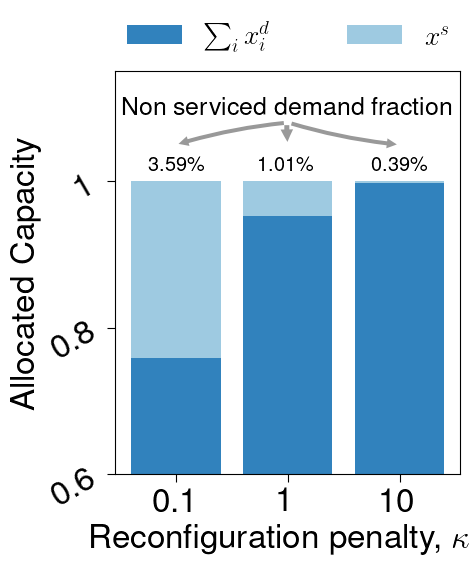

In [66]:
# plt.rcParams.update({'font.size': 20})
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))


len_list_array = np.array(len_list_np[0,:])


perc_sla = np.mean(sla_list_np[0,:]/len_list_array.reshape(-1,1),axis=1)*100

shares = np.zeros((2,3))

shares[0,:] = static_list_np[0,:] # x_d
shares[1,:] = shared_list_np[0,:] # x_6

clrs = [
        '#deebf7',
        '#9ecae1',
        '#3182bd'
][::-1]



x = np.arange(3)

shares = np.true_divide(shares,np.sum(shares,axis=0))

print(shares)


#width = 0.1
#ax.bar(x,shares[0,:],width=width,color=clrs[0])
#ax.bar(x+width,shares[1,:],width=width,color=clrs[1])
#ax.bar(x+2*width,shares[2,:],width=width,color=clrs[2])
 

ax.bar(x,shares[0,:],color=clrs[0],label='$\sum_i x_i^d$')
ax.bar(x,shares[1,:],color=clrs[1],bottom=shares[0,:],label='$x^s$')
#ax.bar(x,shares[2,:],color=clrs[2],bottom=shares[0,:]+shares[1,:])
    
#ax.set_yscale("log", nonposy='clip')


for i in range(3):
    ax.text(x[i],1.02, "%.2f" % perc_sla[i] + r"\%", 
            horizontalalignment='center',verticalalignment='center',fontsize='x-large')

ax.set_xticks(range(3))
ax.set_xticklabels([0.1,1,10])
ax.set_yticks([0.6,0.8,1])
ax.set_ylabel('Allocated Capacity')
ax.set_yticklabels(['0.6','0.8','1'],rotation=30)
ax.set_xlabel(r"Reconfiguration penalty, $\kappa_r$")
el = Ellipse((2, -1), 0.5, 0.5)

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.,fontsize=20)
ax.set_ylim(bottom=0.6,top=1.15)
#ax.legend()

ax.annotate("Non serviced demand fraction", xy=(1, 1.05), xytext=(1,1.1), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize=18)

ax.annotate("", xy=(0, 1.05), xytext=(0.99,1.08), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize='x-large')

ax.annotate("", xy=(2, 1.05), xytext=(1.01,1.08), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize='x-large')


# plt.savefig('allocated_capacity_shares.pdf')
# plt.tight_layout()
# ax.set_title('AZTEC_ NEW', y = 1.2)
plt.tight_layout()
# plt.savefig('../FIGS/allocated_capacity_shares.pdf')
# plt.savefig('../FIGS/allocated_capacity_shares.png')

# plt.show()

# CAPACITY AZTEC_ OLD

[[9.05218975e-01 9.89332862e-01 9.99648639e-01]
 [9.47810245e-02 1.06671381e-02 3.51361129e-04]]


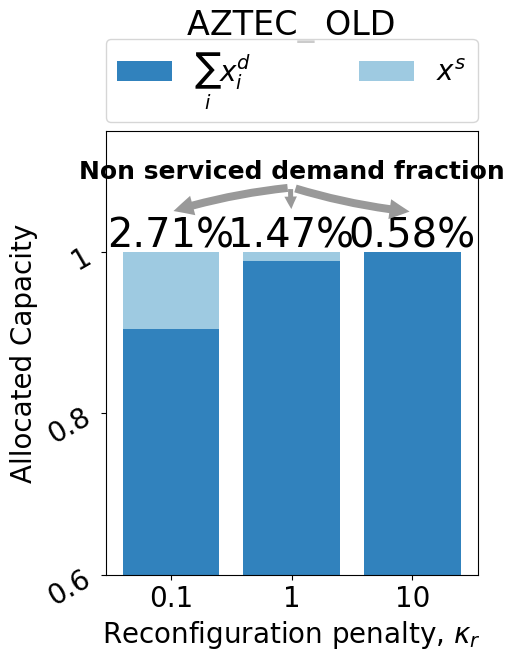

In [163]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))


len_list_array = np.array(len_list_np_6[0,:])


perc_sla = np.mean(sla_list_np_6[0,:]/len_list_array.reshape(-1,1),axis=1)*100

shares = np.zeros((2,3))

shares[0,:] = static_list_np_6[0,:] # x_d
shares[1,:] = shared_list_np_6[0,:] # x_6

clrs = [
        '#deebf7',
        '#9ecae1',
        '#3182bd'
][::-1]



x = np.arange(3)

shares = np.true_divide(shares,np.sum(shares,axis=0))

print(shares)


#width = 0.1
#ax.bar(x,shares[0,:],width=width,color=clrs[0])
#ax.bar(x+width,shares[1,:],width=width,color=clrs[1])
#ax.bar(x+2*width,shares[2,:],width=width,color=clrs[2])
 

ax.bar(x,shares[0,:],color=clrs[0],label='$\sum_i x_i^d$')
ax.bar(x,shares[1,:],color=clrs[1],bottom=shares[0,:],label='$x^s$')
#ax.bar(x,shares[2,:],color=clrs[2],bottom=shares[0,:]+shares[1,:])
    
#ax.set_yscale("log", nonposy='clip')


for i in range(3):
    ax.text(x[i],1.02, "%.2f" % perc_sla[i] + "%", 
            horizontalalignment='center',verticalalignment='center',fontsize='x-large')

ax.set_xticks(range(3))
ax.set_xticklabels([0.1,1,10])
ax.set_yticks([0.6,0.8,1])
ax.set_ylabel('Allocated Capacity')
ax.set_yticklabels(['0.6','0.8','1'],rotation=30)
ax.set_xlabel("Reconfiguration penalty, $\kappa_r$")
el = Ellipse((2, -1), 0.5, 0.5)

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.,fontsize=20)
ax.set_ylim(bottom=0.6,top=1.15)
#ax.legend()

ax.annotate("Non serviced demand fraction", xy=(1, 1.05), xytext=(1,1.1), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize=18)

ax.annotate("", xy=(0, 1.05), xytext=(0.99,1.08), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize='x-large')

ax.annotate("", xy=(2, 1.05), xytext=(1.01,1.08), 
            arrowprops=dict(arrowstyle="simple",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="arc3,rad=0.05"),weight = 'bold',
           horizontalalignment='center',verticalalignment='center',
            color='k',fontsize='x-large')


# plt.savefig('allocated_capacity_shares.pdf')
# plt.tight_layout()
ax.set_title('AZTEC_ OLD', y = 1.2)
plt.show()

# Cost breakdown vs instantation cost

In [214]:

phi =1

if phi == 0.1:
    idx_phi = 0
elif phi == 1:
    idx_phi = 1
elif phi == 10:
    idx_phi = 2


cost_SLA_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_slas'].to_numpy()
cost_instantiation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_instantiation'].to_numpy()
cost_reconfiguration_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_reconfiguration'].to_numpy()

eta = 1

cost_breakdown = np.zeros((5,1))
cost_breakdown[0,:] = cost_overprovisioning_static_list_np[0,idx_phi]
cost_breakdown[1,:] = cost_overprovisioning_shared_list_np[0,idx_phi]
cost_breakdown[2,:] = cost_SLA_eta_2_Aztec_ext
cost_breakdown[3,:] = cost_instantiation_eta_2_Aztec_ext * eta
cost_breakdown[4,:] = cost_reconfiguration_eta_2_Aztec_ext


eta = 5

cost_breakdown_5 = np.zeros((5,1))
cost_breakdown_5[0,:] = cost_overprovisioning_static_list_np[0,idx_phi]
cost_breakdown_5[1,:] = cost_overprovisioning_shared_list_np[0,idx_phi]
cost_breakdown_5[2,:] = cost_SLA_eta_2_Aztec_ext
cost_breakdown_5[3,:] = cost_instantiation_eta_2_Aztec_ext * eta
cost_breakdown_5[4,:] = cost_reconfiguration_eta_2_Aztec_ext


eta = 10

cost_breakdown_10 = np.zeros((5,1))
cost_breakdown_10[0,:] = cost_overprovisioning_static_list_np[0,idx_phi]
cost_breakdown_10[1,:] = cost_overprovisioning_shared_list_np[0,idx_phi]
cost_breakdown_10[2,:] = cost_SLA_eta_2_Aztec_ext
cost_breakdown_10[3,:] = cost_instantiation_eta_2_Aztec_ext * eta
cost_breakdown_10[4,:] = cost_reconfiguration_eta_2_Aztec_ext


cost_breakdown_merged = np.concatenate((cost_breakdown,cost_breakdown_5,cost_breakdown_10),axis=1)

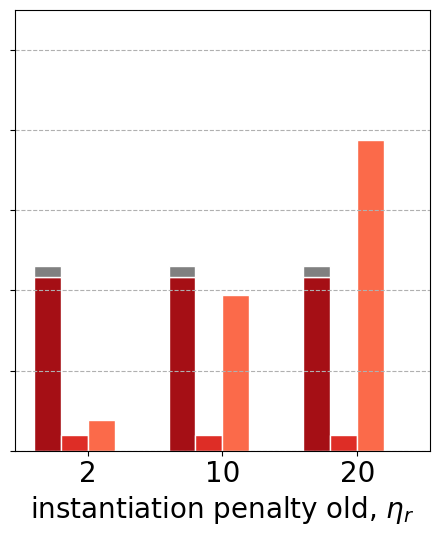

In [215]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))

plt.rcParams.update({'font.size': 20})

clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

costs = cost_breakdown_merged
#costs = np.true_divide(costs,2.5908145607126234)

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
ax.set_xticklabels([2,10,20])
# ax.set_ylim(top=0.35)
ax.set_yticks([0,.1,.2,.3,.4,.5],'')
# ax.set_yticklabels([0,.1,.2,.3,.4,.5])
ax.set_ylim(top=0.55)
ax.grid(which='major', axis='y', linestyle='--')
# ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#            ncol=2, mode="expand", borderaxespad=0.,fontsize='x-small')

# ax.set_ylabel('Normalized Monetary Cost')

ax.set_xlabel('instantiation penalty old, $\eta_r$')

plt.tight_layout()
plt.savefig('victory_2.pdf')
plt.savefig('../FIGS/Monetary_cost_breakdown_old.pdf')
plt.show()

# INFOCOM 19 Cost breakdown vs instantation cost

In [216]:
Deepcog_costs_eta_20 = Deepcog_costs.copy()
Deepcog_costs_eta_20['cost_instantiation_infocom19'] = Deepcog_costs_eta_20['cost_instantiation_infocom19']*10
Deepcog_costs_eta_20['total_cost'] = Deepcog_costs_eta_20['cost_overprovisioning_infocom'] + Deepcog_costs_eta_20['cost_instantiation_infocom19'] + Deepcog_costs_eta_20['cost_slas_infocom_19']  + Deepcog_costs_eta_20['cost_reconfiguration']


infocom_costs_eta_10 = infocom_17_results.copy()

In [217]:
Deepcog_costs

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_1,0.903040,0.600009,0.031708,0.246526,0.024798
Paris_phi_0.1_alpha_3_delay_1,1.032580,0.730706,0.029565,0.247476,0.024833
Paris_phi_0.1_alpha_5_delay_1,1.282406,0.997454,0.012283,0.247798,0.024872
Paris_phi_1_alpha_2_delay_1,1.126218,0.600009,0.031708,0.246526,0.247975
Paris_phi_1_alpha_3_delay_1,1.256081,0.730706,0.029565,0.247476,0.248334
Paris_phi_1_alpha_5_delay_1,1.506250,0.997454,0.012283,0.247798,0.248715
Paris_phi_10_alpha_2_delay_1,3.357996,0.600009,0.031708,0.246526,2.479754
Paris_phi_10_alpha_3_delay_1,3.491089,0.730706,0.029565,0.247476,2.483342
Paris_phi_10_alpha_5_delay_1,3.744688,0.997454,0.012283,0.247798,2.487154


In [219]:
Deepcog_costs

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_19,cost_instantiation_infocom19,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_1,0.903040,0.600009,0.031708,0.246526,0.024798
Paris_phi_0.1_alpha_3_delay_1,1.032580,0.730706,0.029565,0.247476,0.024833
Paris_phi_0.1_alpha_5_delay_1,1.282406,0.997454,0.012283,0.247798,0.024872
Paris_phi_1_alpha_2_delay_1,1.126218,0.600009,0.031708,0.246526,0.247975
Paris_phi_1_alpha_3_delay_1,1.256081,0.730706,0.029565,0.247476,0.248334
Paris_phi_1_alpha_5_delay_1,1.506250,0.997454,0.012283,0.247798,0.248715
Paris_phi_10_alpha_2_delay_1,3.357996,0.600009,0.031708,0.246526,2.479754
Paris_phi_10_alpha_3_delay_1,3.491089,0.730706,0.029565,0.247476,2.483342
Paris_phi_10_alpha_5_delay_1,3.744688,0.997454,0.012283,0.247798,2.487154


In [221]:


    
cost_SLA_eta_2_Aztec_old = Deepcog_costs[Deepcog_costs.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_slas_infocom_19'].to_numpy()
cost_instantiation_eta_2_Aztec_old = Deepcog_costs[Deepcog_costs.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_instantiation_infocom19'].to_numpy()
cost_reconfiguration_eta_2_Aztec_old = Deepcog_costs[Deepcog_costs.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_reconfiguration'].to_numpy()

eta = 1 

cost_breakdown_6_eta_1 = np.zeros((5,1))
cost_breakdown_6_eta_1[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_1[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_1[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_1[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_1[4,:] = cost_reconfiguration_eta_2_Aztec_old

eta = 5

cost_breakdown_6_eta_5 = np.zeros((5,1))
cost_breakdown_6_eta_5[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_5[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_5[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_5[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_5[4,:] = cost_reconfiguration_eta_2_Aztec_old

eta = 10

cost_breakdown_6_eta_10 = np.zeros((5,1))
cost_breakdown_6_eta_10[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_10[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_10[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_10[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_10[4,:] = cost_reconfiguration_eta_2_Aztec_old

cost_breakdown_merged_6 = np.concatenate((cost_breakdown_6_eta_1,cost_breakdown_6_eta_5,cost_breakdown_6_eta_10),axis=1)

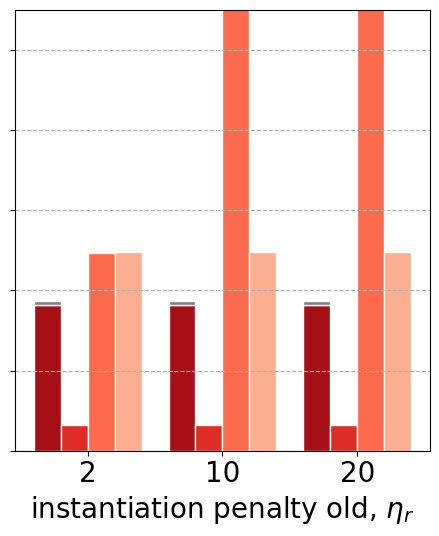

In [222]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))

# plt.rcParams.update({'font.size': 20})

clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

costs = cost_breakdown_merged_6
#costs = np.true_divide(costs,2.5908145607126234)

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
ax.set_xticklabels([2,10,20])
# ax.set_ylim(top=0.35)
ax.set_yticks([0,.1,.2,.3,.4,.5],'')
# ax.set_yticklabels([0,.1,.2,.3,.4,.5])
ax.set_ylim(top=0.55)
ax.grid(which='major', axis='y', linestyle='--')
# ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#            ncol=2, mode="expand", borderaxespad=0.,fontsize='x-small')

# ax.set_ylabel('Normalized Monetary Cost')

ax.set_xlabel('instantiation penalty old, $\eta_r$')

plt.tight_layout()
plt.savefig('victory_2.pdf')
plt.savefig('../FIGS/Monetary_cost_breakdown_old.pdf')
plt.show()

# Cost Breakdown 2 subplots

In [48]:


    
cost_SLA_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_slas'].to_numpy()
cost_instantiation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_instantiation'].to_numpy()
cost_reconfiguration_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_phi_{phi}_alpha_2_')]['cost_reconfiguration'].to_numpy()

eta = 1 

cost_breakdown_6_eta_1 = np.zeros((5,1))
cost_breakdown_6_eta_1[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_1[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_1[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_1[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_1[4,:] = cost_reconfiguration_eta_2_Aztec_old

eta = 5

cost_breakdown_6_eta_5 = np.zeros((5,1))
cost_breakdown_6_eta_5[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_5[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_5[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_5[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_5[4,:] = cost_reconfiguration_eta_2_Aztec_old

eta = 10

cost_breakdown_6_eta_10 = np.zeros((5,1))
cost_breakdown_6_eta_10[0,:] = cost_overprovisioning_static_list_np_6[0,idx_phi]
cost_breakdown_6_eta_10[1,:] = cost_overprovisioning_shared_list_np_6[0,idx_phi]
cost_breakdown_6_eta_10[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6_eta_10[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6_eta_10[4,:] = cost_reconfiguration_eta_2_Aztec_old

cost_breakdown_merged_6 = np.concatenate((cost_breakdown_6_eta_1,cost_breakdown_6_eta_5,cost_breakdown_6_eta_10),axis=1)

In [173]:
w,h = figaspect(9.16)

In [174]:
w

4.0

In [175]:
h

16.0

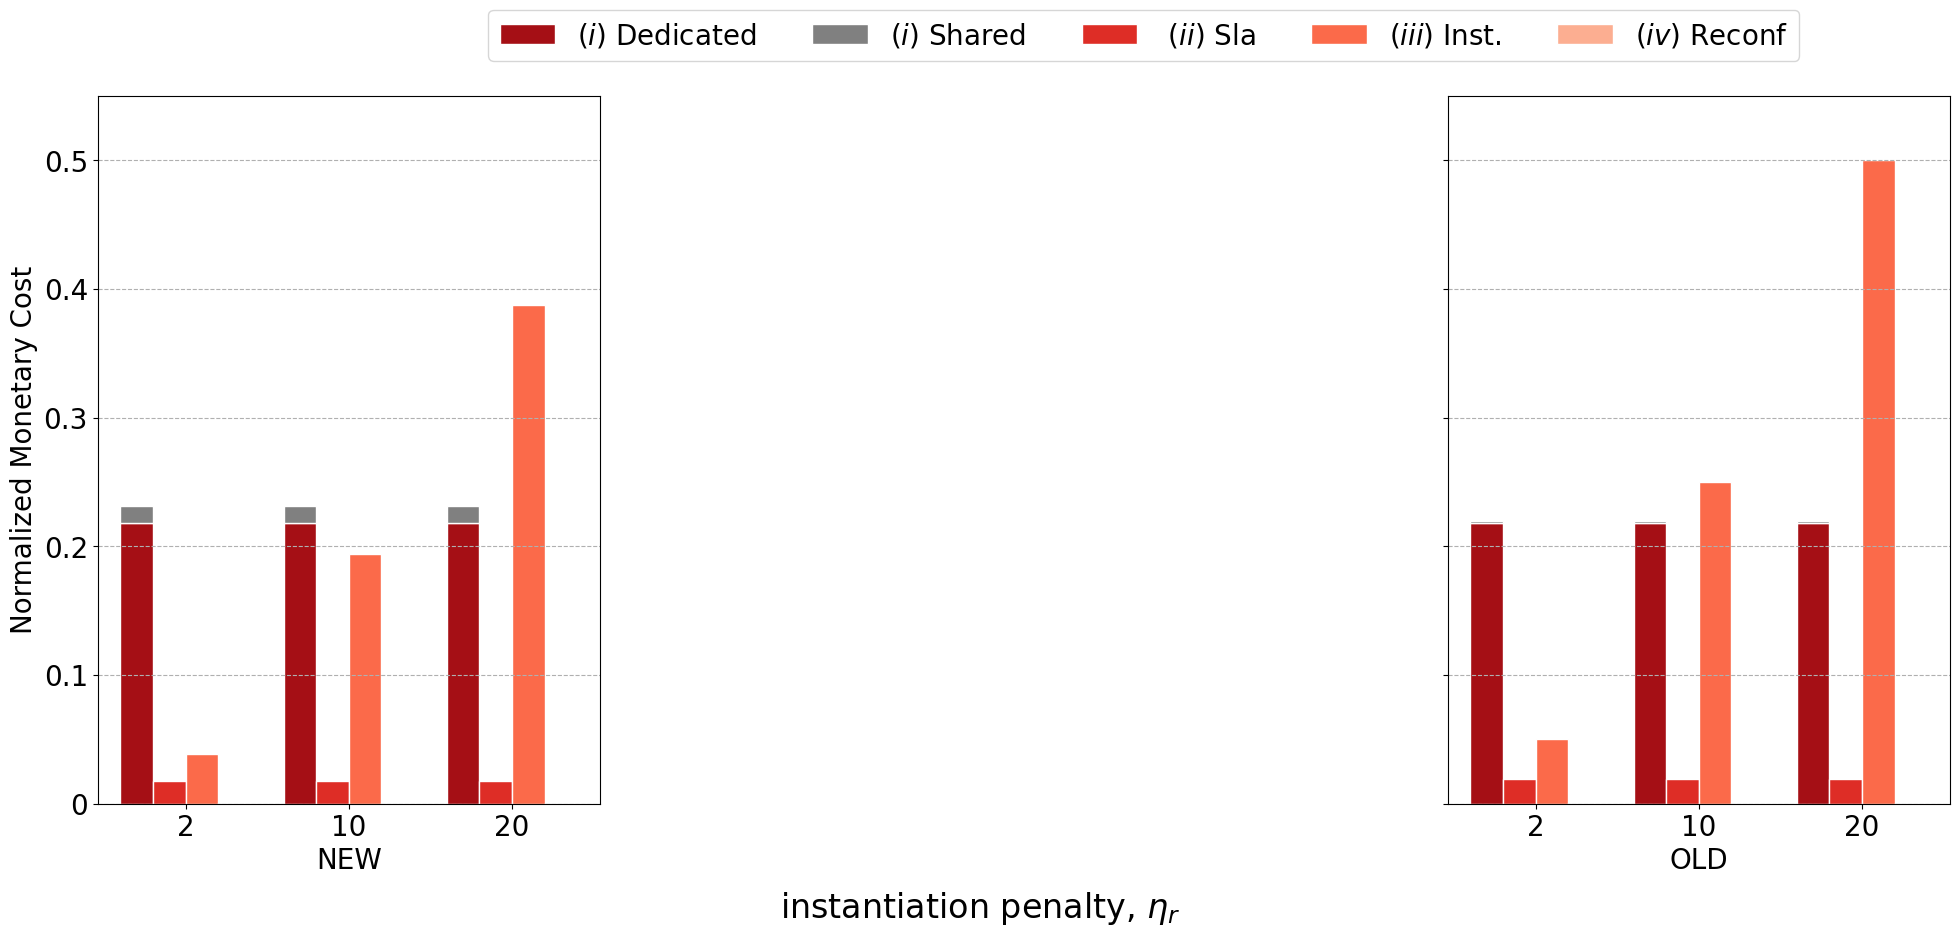

In [59]:
fig,ax = plt.subplots(1,2,figsize=(20,10))
# fig,ax = plt.subplots(1,2,figsize=1.2*figaspect(cost_breakdown_merged))

plt.rcParams['font.size'] = 20

clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

costs = cost_breakdown_merged
#costs = np.true_divide(costs,2.5908145607126234)

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax[0].bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax[0].bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax[0].bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax[0].set_xticks(x+1.5*width)
ax[0].set_xticklabels([2,10,20])
# ax[0].set_ylim(top=0.35)
ax[0].set_yticks([0,.1,.2,.3,.4,.5])
ax[0].set_yticklabels([0,.1,.2,.3,.4,.5])
ax[0].set_ylim(top=0.55)
ax[0].grid(which='major', axis='y', linestyle='--')
# ax[0].legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#            ncol=2, mode="expand", borderaxespad=0.,fontsize='xx-large')

ax[0].set_ylabel('Normalized Monetary Cost')

ax[0].set_xlabel('NEW')

### plot 2 ###

costs = cost_breakdown_merged_6

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$) Sla','($iii$) Inst.', '($iv$) Reconf']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax[1].bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax[1].bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax[1].bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax[1].set_xticks(x+1.5*width)
ax[1].set_xticklabels([2,10,20])
# [1]ax.set_ylim(top=0.35)
ax[1].set_yticks([0,.1,.2,.3,.4,.5],'')
# ax[1].set_yticklabels([0,.1,.2,.3,.4,.5])

ax[1].set_ylim(top=0.55)
ax[1].grid(which='major', axis='y', linestyle='--')
# ax[1].legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#            ncol=2, mode="expand", borderaxespad=0.,fontsize='xx-large')

# ax[1].set_ylabel('Normalized Monetary Cost')

ax[1].set_xlabel('OLD')

# fig.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=5,
#            ncol=2, mode="expand", borderaxespad=0.,fontsize='xx-large')
plt.legend(bbox_to_anchor=(-1.1, 1.02, 1.8, .102), 
              ncol=5, mode="large", borderaxespad=0.)

fig.supxlabel('instantiation penalty, $\eta_r$',y = 0.045)

plt.tight_layout()
plt.savefig('victory_2.pdf')
plt.savefig('../FIGS/Breakdown_NEW_OLD.pdf')
plt.savefig('../FIGS/Breakdown_NEW_OLD.png')
plt.show()

In [96]:
Aztec_ext_results_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.360764,0.246701,0.082330,0.029603,0.002130
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.401163,0.265710,0.103000,0.030333,0.002120
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.473385,0.292173,0.148533,0.030574,0.002105
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.288502,0.231034,0.017851,0.038760,0.000857
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.308729,0.247991,0.021055,0.038839,0.000845
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_7,0.332268,0.265946,0.026620,0.038870,0.000832
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.398707,0.350143,0.007450,0.039492,0.001622
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.403314,0.351828,0.010374,0.039495,0.001617
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.411049,0.353420,0.016517,0.039501,0.001611


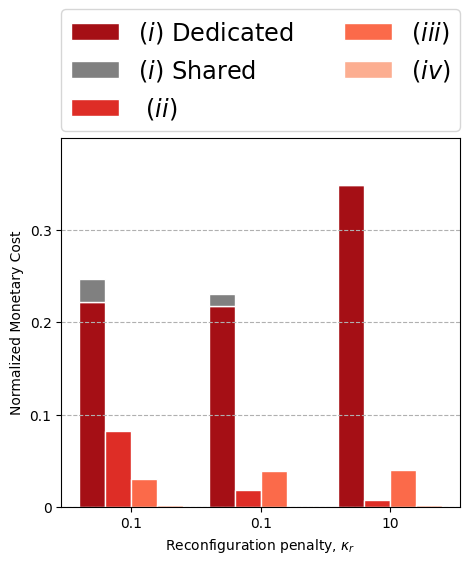

In [109]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))



clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

costs = cost_breakdown
#costs = np.true_divide(costs,2.5908145607126234)

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
ax.set_xticklabels([0.1,0.1,10])
# ax.set_ylim(top=0.35)
ax.set_yticks([0,.1,.2,.3])
ax.set_yticklabels([0,.1,.2,.3])
ax.set_ylim(top=0.4)
ax.grid(which='major', axis='y', linestyle='--')
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.,fontsize='xx-large')

ax.set_ylabel('Normalized Monetary Cost')

ax.set_xlabel('Reconfiguration penalty, $\kappa_r$')

plt.tight_layout()
plt.savefig('victory_2.pdf')
plt.show()

## Cost BREAKDOWN AZTEC_ OLD

In [48]:
cost_SLA_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains('_alpha_2_')]['cost_slas'].to_numpy()
cost_instantiation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains('_alpha_2_')]['cost_instantiation'].to_numpy()
cost_reconfiguration_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains('_alpha_2_')]['cost_reconfiguration'].to_numpy()

cost_breakdown_6 = np.zeros((5,3))
cost_breakdown_6[0,:] = cost_overprovisioning_static_list_np_6[0,:]
cost_breakdown_6[1,:] = cost_overprovisioning_shared_list_np_6[0,:]
cost_breakdown_6[2,:] = cost_SLA_eta_2_Aztec_old
cost_breakdown_6[3,:] = cost_instantiation_eta_2_Aztec_old * eta
cost_breakdown_6[4,:] = cost_reconfiguration_eta_2_Aztec_old

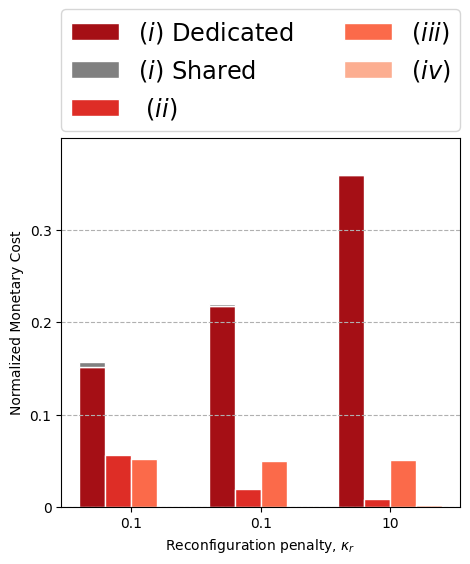

In [49]:
fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))



clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

costs = cost_breakdown_6
#costs = np.true_divide(costs,2.5908145607126234)

x = np.arange(3)


lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
ax.set_xticklabels([0.1,0.1,10])
# ax.set_ylim(top=0.35)
ax.set_yticks([0,.1,.2,.3])
ax.set_yticklabels([0,.1,.2,.3])
ax.set_ylim(top=0.4)
ax.grid(which='major', axis='y', linestyle='--')
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.,fontsize='xx-large')

ax.set_ylabel('Normalized Monetary Cost')

ax.set_xlabel('Reconfiguration penalty, $\kappa_r$')
# ax.set_title('AZTEC_OLD', y = 1.6)

plt.tight_layout()
plt.savefig('victory_2.pdf')
plt.show()

In [41]:
Aztec_ext_results_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.356042,0.214947,0.110656,0.028305,0.002134
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.408698,0.232727,0.144990,0.028853,0.002127
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.485213,0.256916,0.195834,0.030340,0.002122
Paris_ppf_static_0.99_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.280770,0.211851,0.029432,0.038629,0.000858
Paris_ppf_static_0.99_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.291532,0.215555,0.036466,0.038649,0.000862
Paris_ppf_static_0.99_ppf_helper_0.7_phi_1_alpha_5_delay_7,0.309090,0.228032,0.041369,0.038820,0.000869
Paris_ppf_static_0.99_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.418724,0.344206,0.005406,0.063262,0.005850
Paris_ppf_static_0.99_ppf_helper_0.7_phi_10_alpha_3_delay_4,0.420936,0.344098,0.007756,0.063232,0.005850
Paris_ppf_static_0.99_ppf_helper_0.7_phi_10_alpha_5_delay_4,0.427506,0.345341,0.013068,0.063247,0.005850


[[0.1948157  0.2072051  0.34310885]
 [0.02013101 0.004646   0.00109727]
 [0.11065625 0.02943164 0.00540579]
 [0.02830517 0.03862869 0.0632616 ]
 [0.00213416 0.00085848 0.0058501 ]]


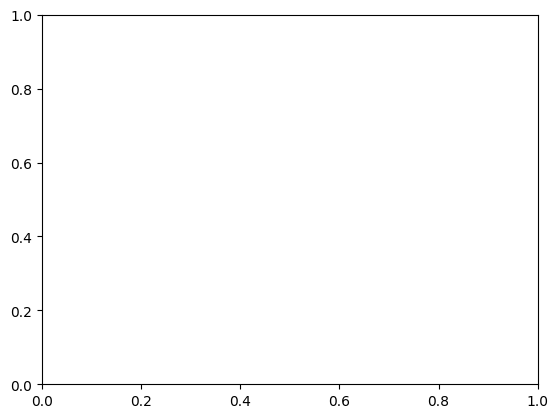

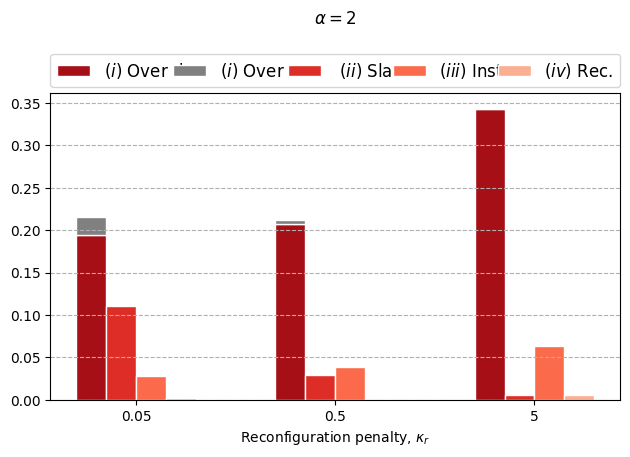

[[0.21019224 0.2087842  0.34292543]
 [0.02253488 0.00677051 0.0011726 ]
 [0.14499029 0.03646605 0.00775589]
 [0.02885325 0.03864919 0.06323214]
 [0.00212746 0.00086235 0.0058501 ]]


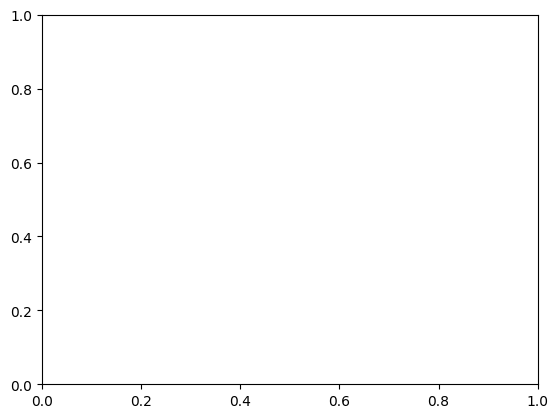

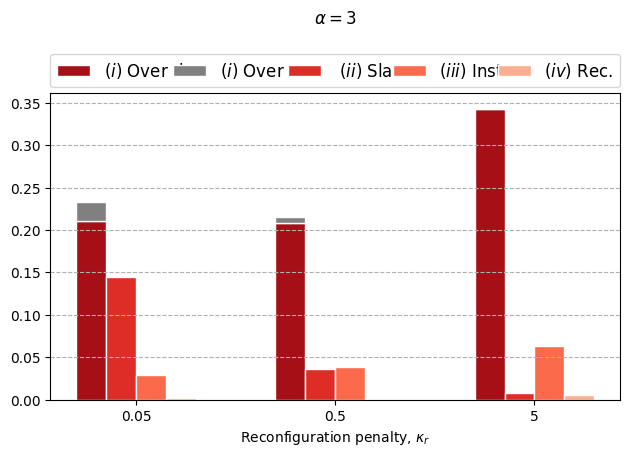

[[0.22997815 0.21415675 0.343127  ]
 [0.02693817 0.01387514 0.0022137 ]
 [0.19583442 0.04136882 0.01306793]
 [0.03033979 0.03882028 0.06324693]
 [0.00212247 0.00086867 0.0058501 ]]


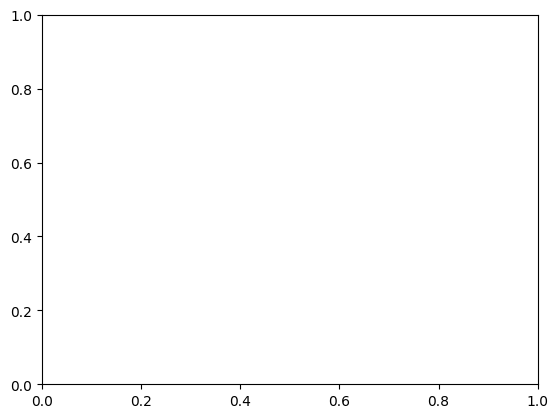

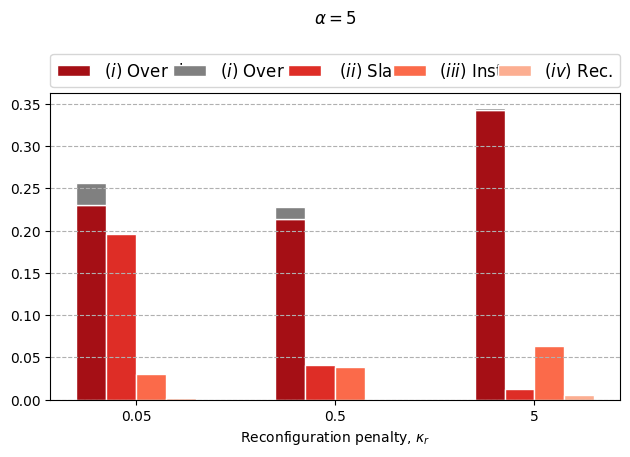

In [42]:
for i, alpha in enumerate(alphas):
    fig,ax = plt.subplots()

    cost_SLA_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_slas'].to_numpy()
    cost_instantiation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
    cost_reconfiguration_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
    
    eta = 1
    costs = np.zeros((5,3))
    
    costs[0,:] = cost_overprovisioning_static_list_np[i,:]
    costs[1,:] = cost_overprovisioning_shared_list_np[i,:]
    costs[2,:] = cost_SLA_eta_2_Aztec_ext
    costs[3,:] = cost_instantiation_eta_2_Aztec_ext * eta
    costs[4,:] = cost_reconfiguration_eta_2_Aztec_ext



    print ( costs)
    fig,ax = plt.subplots()

   

    clrs = ['#fcae91',
            '#fb6a4a',
            '#de2d26',
            '#a50f15',
            '#a50f15'][::-1]


    

    x = np.arange(3)


    lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

    width = 0.15



    ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
    ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
    for i in range(2,5):
        ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
        # ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




    ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
               ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

    ax.set_xticks(x+1.5*width)
    ax.set_xticklabels([0.05,0.5,5])
    #ax.legend(ncol=4,fontsize='large',bbox_to_anchor=(0.5, 1.05))

    ax.set_title(r'$\alpha = %s$' % alpha,y = 1.2)
    ax.grid(which='major', axis='y', linestyle='--')

    ax.set_xlabel('Reconfiguration penalty, $\kappa_r$')

    plt.tight_layout()
    # plt.savefig('victory_2_beta_%s_delay_6.pdf' % step)
    plt.show()

# Cost vs TI

In [57]:
Aztec_ext_results_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.365972,0.252667,0.078796,0.032154,0.002354
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.408549,0.270394,0.102988,0.032822,0.002345
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.470611,0.296082,0.138773,0.033428,0.002328
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.289075,0.230029,0.019327,0.038818,0.000901
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.308734,0.244972,0.024037,0.038837,0.000889
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_7,0.329104,0.259326,0.029899,0.038992,0.000888
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.400435,0.353825,0.006417,0.039020,0.001174
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.404982,0.355536,0.009251,0.039021,0.001174
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.417390,0.362123,0.014951,0.039028,0.001289


In [58]:
alpha = 2
cost_instantation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
cost_instantation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
cost_instantation_eta_2_Deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation_infocom19'].to_numpy()
cost_instantation_eta_2_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation_infocom17'].to_numpy()

In [59]:
cost_instantation_eta_2_Aztec_ext

array([0.03215392, 0.0388178 , 0.03901957])

In [60]:
cost_instantation_eta_2_Aztec_ext

array([0.03215392, 0.0388178 , 0.03901957])

tiempox vs eta

In [61]:

cost_instantation_eta_10_Aztec_ext =  cost_instantation_eta_2_Aztec_ext * 5
cost_instantation_eta_10_Aztec_old =  cost_instantation_eta_2_Aztec_old * 5
cost_instantation_eta_10_Deepcog =  cost_instantation_eta_2_Deepcog * 5
cost_instantation_eta_10_infocom_17 =  cost_instantation_eta_2_infocom_17 * 5

cost_instantation_eta_20_Aztec_ext =  cost_instantation_eta_2_Aztec_ext * 10
cost_instantation_eta_20_Aztec_old =  cost_instantation_eta_2_Aztec_old * 10
cost_instantation_eta_20_Deepcog =  cost_instantation_eta_2_Deepcog * 10
cost_instantation_eta_20_infocom_17 =  cost_instantation_eta_2_infocom_17 * 10

In [62]:
cost_instantation_eta_2_Aztec_ext

array([0.03215392, 0.0388178 , 0.03901957])

In [63]:
cost_instantation_eta_10_Aztec_ext

array([0.16076959, 0.19408899, 0.19509787])

In [67]:
phi_idx =1# idx_ 0 = 0.1 , idx_1 = 1, idx_2 = 10

cost_vs_tl = np.zeros((3,4))
cost_vs_tl[0,:] = [cost_instantation_eta_2_Aztec_ext[phi_idx], cost_instantation_eta_2_Aztec_old[phi_idx], cost_instantation_eta_2_Deepcog[phi_idx], cost_instantation_eta_2_infocom_17[phi_idx]]
cost_vs_tl[1,:] = [cost_instantation_eta_10_Aztec_ext[phi_idx], cost_instantation_eta_10_Aztec_old[phi_idx], cost_instantation_eta_10_Deepcog[phi_idx], cost_instantation_eta_10_infocom_17[phi_idx]]
cost_vs_tl[2,:] = [cost_instantation_eta_20_Aztec_ext[phi_idx], cost_instantation_eta_20_Aztec_old[phi_idx], cost_instantation_eta_20_Deepcog[phi_idx], cost_instantation_eta_20_infocom_17[phi_idx]]

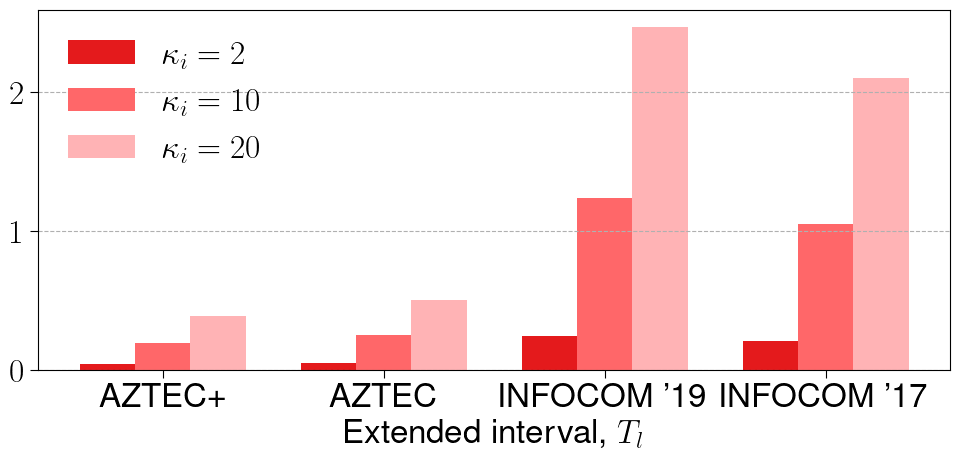

In [88]:
fig,ax = plt.subplots(figsize=(10,5))

# fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))

clrs = ['#e41a1c',
        '#FF6769',
        '#FFB3B5']

costs = cost_vs_tl
#costs = np.true_divide(costs,2.5908145607126234)



x = np.arange(4)


lbls = [
        r'$\kappa_i = 2$',
        r'$\kappa_i = 10$',
        r'$\kappa_i = 20$'
]
width = 0.25
for i in range(3):
    ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')



#ax.set_yscale("log", nonposy='clip')

ax.set_xticks(x+1*width)
ax.set_xticklabels(['AZTEC+','AZTEC','INFOCOM \'19','INFOCOM \'17'])
# ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
# ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
#ax.set_ylabel('Normalized Monetary Cost')
#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=3, mode="expand", borderaxespad=0.,fontsize='large')

ax.legend()
ax.grid(which='major', axis='y', linestyle='--')
ax.set_xlabel('Extended interval, $T_l$')

#ax.legend()
plt.tight_layout()
plt.savefig('../FIGS/cost_vs_tl.pdf')
# plt.show()

In [233]:


cost_breakdown = np.zeros((5,3))
cost_breakdown[0,:] = cost_overprovisioning_static_list_np[0,:]
cost_breakdown[1,:] = cost_overprovisioning_shared_list_np[0,:]
cost_breakdown[2,:] = cost_SLA_eta_2_Aztec_ext
cost_breakdown[3,:] = cost_instantiation_eta_2_Aztec_ext * eta
cost_breakdown[4,:] = cost_reconfiguration_eta_2_Aztec_ext

In [21]:
def Retrieve_instantiation_cost_modify_instantation_cost(df,phi,eta,ppf_static,ppf_helper,alpha=2,benchmark=None):

   
    
    if  benchmark =='deepcog':
        res = df.copy()
        res['cost_instantiation_infocom19'] = res['cost_instantiation_infocom19']*eta
        res['total_costs'] = res['cost_overprovisioning_infocom'] + res['cost_instantiation_infocom19'] + res['cost_slas_infocom_19']  + res['cost_reconfiguration']

        cost_total_res = res[res.index.str.contains(f'phi_{phi}_alpha_{alpha}_')]['cost_instantiation_infocom19'].to_numpy()

    elif  benchmark =='infocom':
        res = df.copy()
        res['cost_instantiation_infocom17'] = res['cost_instantiation_infocom17']*eta
        res['total_costs'] = res['cost_overprovisioning_infocom'] + res['cost_instantiation_infocom17'] + res['cost_slas_infocom_17']  + res['cost_reconfiguration']

        cost_total_res = res[res.index.str.contains(f'phi_{phi}_alpha_2_')]['cost_instantiation_infocom17'].to_numpy()
    elif  benchmark =='aztec_old':
        res = df.copy()
        res['cost_instantiation'] = res['cost_instantiation']*eta
        res['total_costs'] = res['cost_overprovisioning'] + res['cost_instantiation'] + res['cost_slas']  + res['cost_reconfiguration']

        cost_total_res = res[res.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_2_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
    else:
        cost_total_res = df[df.index.str.contains(f'ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()

    return cost_total_res

In [22]:

Aztec_ext_results_default = Aztec_ext_results[Aztec_ext_results.index.str.contains(f'static_{ppf_static}_ppf_helper_{ppf_helper}')]
Aztec_old_results_merged_default = Aztec_old_results_merged[Aztec_old_results_merged.index.str.contains(f'static_{ppf_static_old}_ppf_helper_{ppf_helper_old}')]

Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]
ALPHAS= [2,3,5]
deepcog_costs_inst = np.zeros((len(Phis),len(ETAS),len(ALPHAS)))
infocom_17_costs_inst = np.zeros((len(Phis),len(ETAS),len(ALPHAS)))
aztec_old_costs_inst = np.zeros((len(Phis),len(ETAS),len(ALPHAS)))
aztec_plus_costs_inst = np.zeros((len(Phis),len(ETAS),len(ALPHAS)))

for i,phi in enumerate(Phis):
    for j,eta in enumerate(ETAS):
        for k,alpha in enumerate (ALPHAS):
            deepcog_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(Deepcog_costs,phi,eta,ppf_static,ppf_helper,benchmark='deepcog')
            infocom_17_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(infocom_17_results,phi,eta,ppf_static,ppf_helper,benchmark='infocom')
            aztec_old_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(Aztec_old_results_merged_default,phi,eta,ppf_static_old,ppf_helper_old,benchmark = 'aztec_old')
            aztec_plus_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(Aztec_ext_results_default,phi,eta,ppf_static,ppf_helper)

/tmp/ipykernel_3196357/2797454601.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  deepcog_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(Deepcog_costs,phi,eta,ppf_static,ppf_helper,benchmark='deepcog')
/tmp/ipykernel_3196357/2797454601.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  infocom_17_costs_inst[i,j,k] = Retrieve_instantiation_cost_modify_instantation_cost(infocom_17_results,phi,eta,ppf_static,ppf_helper,benchmark='infocom')
/tmp/ipykernel_3196357/2797454601.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a 

In [23]:
aztec_plus_costs_inst.shape

(4, 10, 3)

In [24]:
Alphas = [2]
cost_vs_tl = np.zeros((len(Phis),len(ETAS),4)) 
# Phis = [0.1,0.5,1,10]
for i,phi in enumerate(Phis):
    for j,eta in enumerate (ETAS):
   
      
            
        cost_vs_tl[i,j,:] = [aztec_plus_costs_inst[i,j,0], aztec_old_costs_inst[i,j,0], deepcog_costs_inst[i,j,0], infocom_17_costs_inst[i,j,0]] 
        

        

In [25]:
cost_vs_tl.shape

(4, 10, 4)

In [26]:
cost_vs_tl_phi_01 =cost_vs_tl[0]
cost_vs_tl_phi_05 =cost_vs_tl[1]
cost_vs_tl_phi_1 =cost_vs_tl[2]
cost_vs_tl_phi_10 =cost_vs_tl[3]

In [27]:
cost_vs_tl_aztec_plus_phi_01 = cost_vs_tl_phi_01.T[0]
cost_vs_tl_aztec_plus_phi_05 = cost_vs_tl_phi_05.T[0]
cost_vs_tl_aztec_plus_phi_1 = cost_vs_tl_phi_1.T[0]
cost_vs_tl_aztec_plus_phi_10 = cost_vs_tl_phi_10.T[0]

In [28]:
cost_vs_tl_aztec_plus_phi_01

array([0.01628736, 0.03895673, 0.15634482, 0.94019292, 1.52333128,
       2.12629524, 2.55107304, 3.34075466, 4.75467633, 5.2060232 ])

In [29]:
cost_vs_tl_aztec_plus = np.zeros ((4,10))
cost_vs_tl_aztec_plus[0,:] = cost_vs_tl_aztec_plus_phi_01
cost_vs_tl_aztec_plus[1,:] = cost_vs_tl_aztec_plus_phi_05
cost_vs_tl_aztec_plus[2,:] = cost_vs_tl_aztec_plus_phi_1
cost_vs_tl_aztec_plus[3,:] = cost_vs_tl_aztec_plus_phi_10


In [30]:
cost_vs_tl_aztec_plus =cost_vs_tl_aztec_plus.T

In [31]:
cost_vs_tl_aztec_plus

array([[0.01628736, 0.01054441, 0.01985773, 0.0190732 ],
       [0.03895673, 0.02556761, 0.01743954, 0.03911299],
       [0.15634482, 0.11127964, 0.08782447, 0.0653431 ],
       [0.94019292, 0.21248044, 0.15605238, 0.12955112],
       [1.52333128, 0.47794318, 0.21023341, 0.19547602],
       [2.12629524, 0.78101475, 0.32868184, 0.2604377 ],
       [2.55107304, 1.01383628, 0.54188624, 0.32306046],
       [3.34075466, 1.2080553 , 0.74892011, 0.13529164],
       [4.75467633, 1.63753558, 0.99403521, 0.16334441],
       [5.2060232 , 1.83476178, 1.02931232, 0.18987774]])

In [21]:
costs[i,:]

NameError: name 'costs' is not defined

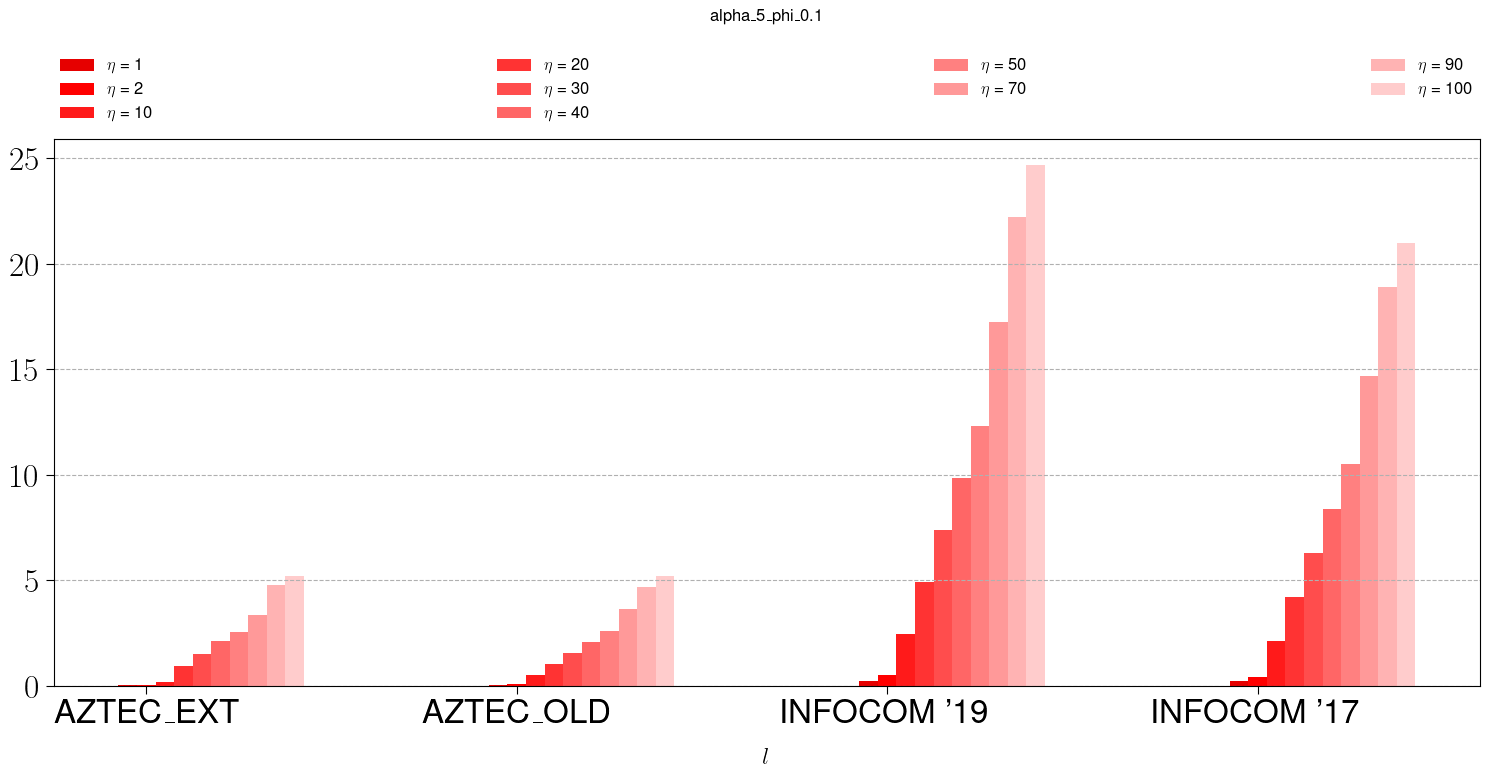

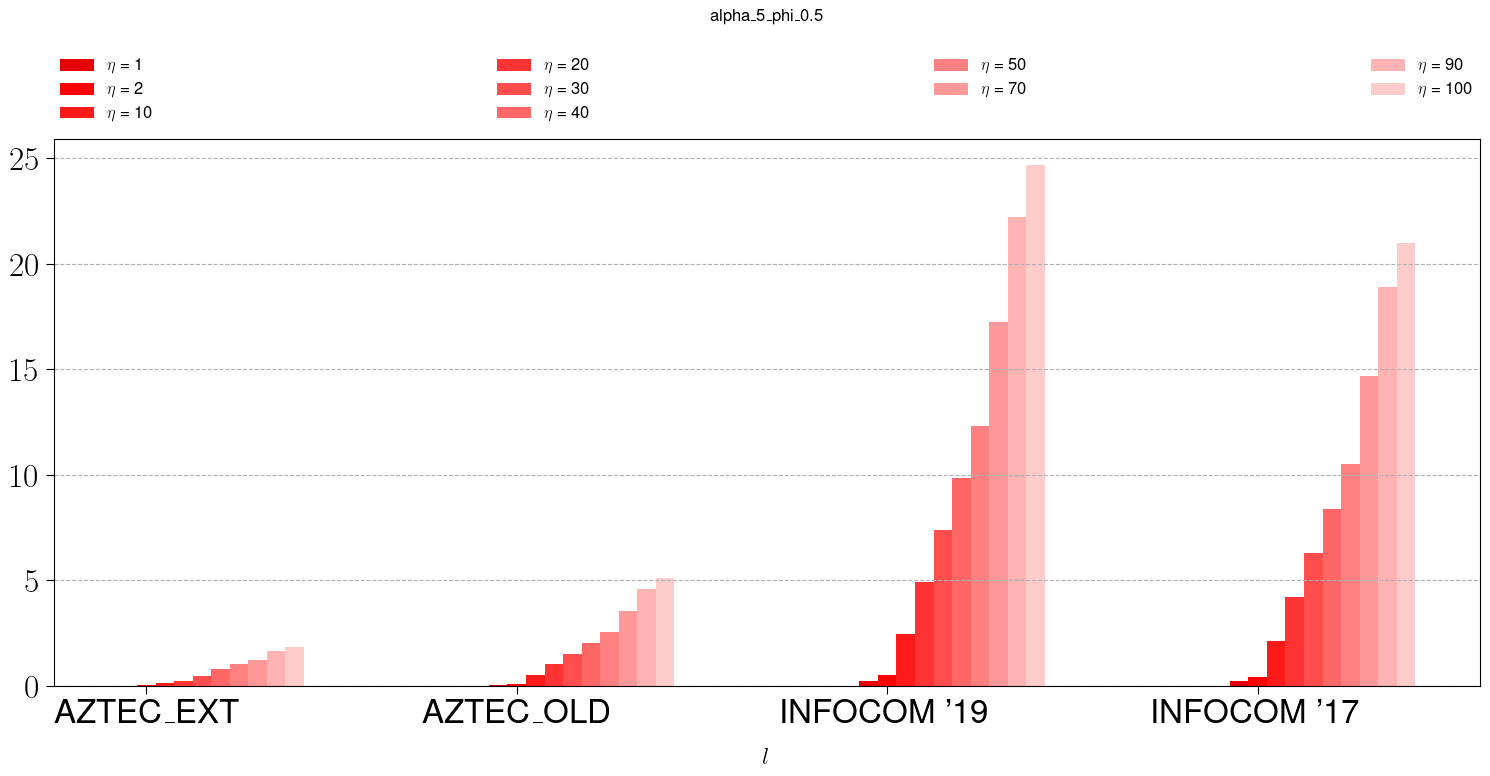

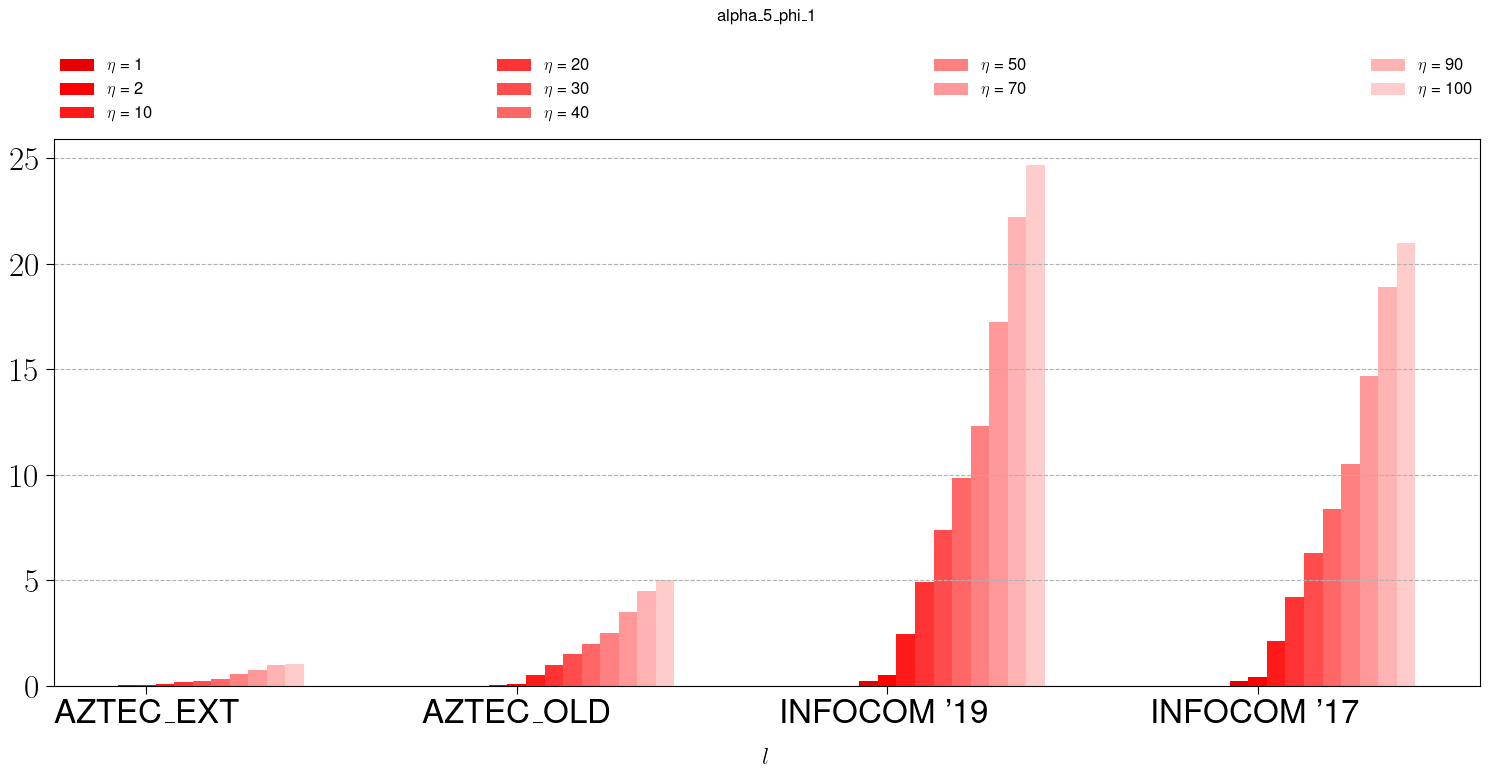

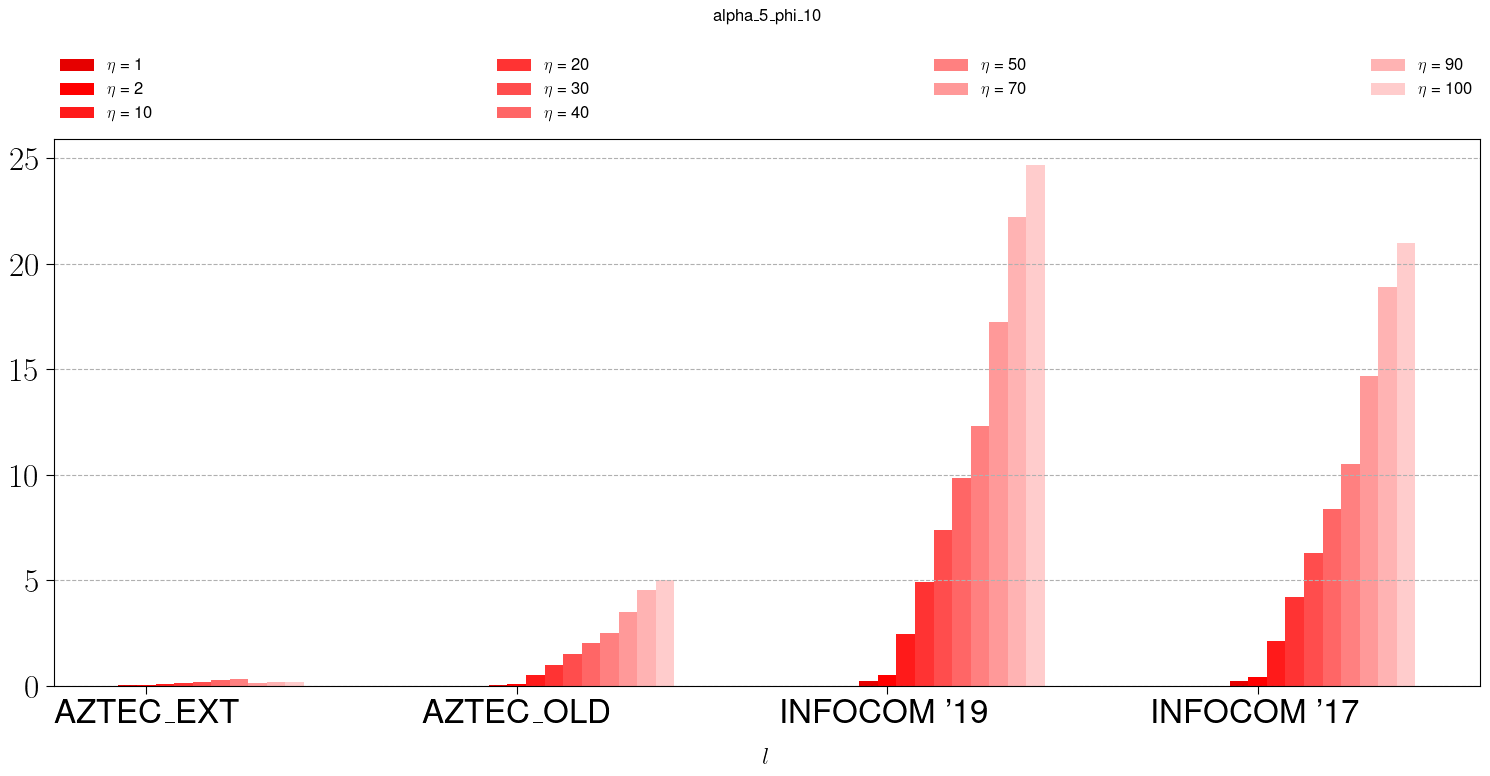

In [103]:
for i, phi in enumerate(Phis):
    
        
    
    
        fig,ax = plt.subplots(figsize =(15,8))



        clrs = ['#E60000',
                '#FF0000',
                '#FF1A1A',
                '#FF3333',
                '#FF4D4D',
                '#FF6666',
                '#FF8080',
                '#FF9999',
                '#FFB3B3',
                '#FFCCCC'
                ]
        
        x = np.array([0,4,8,12])
        costs = cost_vs_tl[i]

        lbls = [
                u'$\eta$ = 1',
                u'$\eta$ = 2',
                u'$\eta$ = 10',
                u'$\eta$ = 20',
                u'$\eta$ = 30',
                u'$\eta$ = 40',
                u'$\eta$ = 50',
                u'$\eta$ = 70',
                u'$\eta$ = 90',
                u'$\eta$ = 100'
        ]
        width = 0.2
        for i in range(10):
            ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
            #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')



        #ax.set_yscale("log", nonposy='clip')

        ax.set_xticks(x+1*width)
        ax.set_xticklabels(['AZTEC_EXT','AZTEC_OLD','INFOCOM \'19', 'INFOCOM \'17'])
        #ax.set_yticks([1,10,100,1000])
        #ax.set_yticklabels([1,10,100,1000])

        ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
                ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

        ax.set_xlabel('$\t_l$')
        ax.grid(which='major', axis='y', linestyle='--')
        #ax.legend()
        ax.set_title(F'alpha_{alpha}_phi_{phi}',y = 1.2)
        plt.tight_layout()
        # plt.savefig('cost_vs_tl_phi_%s_beta_%s.pdf' % (ph, step))
        plt.show()

In [106]:
costs[4,:]

array([1.52333128, 1.55417788, 7.39579036, 6.2932149 ])

In [234]:
cost_instantation_eta_2_Aztec_ext

array([0.03215392, 0.0388178 , 0.03901957])

# plot instantation cost per reconf cost

In [33]:
PHIS = [0.1,0.5,1,10] # Negative slope of the loss function TO BE MODIFIED 
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
#         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']
cities = ['Paris']





TB_Fpath = 'Training_Block_Optimal_Cities_test_kr_ki'
pair_list=[]



save_folder = 'Results_Optimal_Cities_test_kr_ki'
ETAS=[1,2,10,20,30,40,50,70,90,100]

windows_matrix = np.zeros((len(cities),len(PHIS),len(ETAS)))

ROOT_DIR = '/home/sergi_alcala/sergi_data/AZTEC_extension'
for i,city in enumerate(cities):
            
        for j,PHI in enumerate(PHIS):
                for k,eta in enumerate(ETAS):
                        windows_matrix[i,j,k] = np.load(f'{ROOT_DIR}/{save_folder}/{city}/PHI_{PHI}/ETA_{eta}/overall_optimal_window.npy')

In [34]:
windows_matrix = windows_matrix.reshape(4,10)

In [35]:
windows_matrix.shape

(4, 10)

In [36]:
costs.shape

NameError: name 'costs' is not defined

In [40]:
plt.style.use('/home/sergi_alcala/Matplotlib/style.mplstyle')

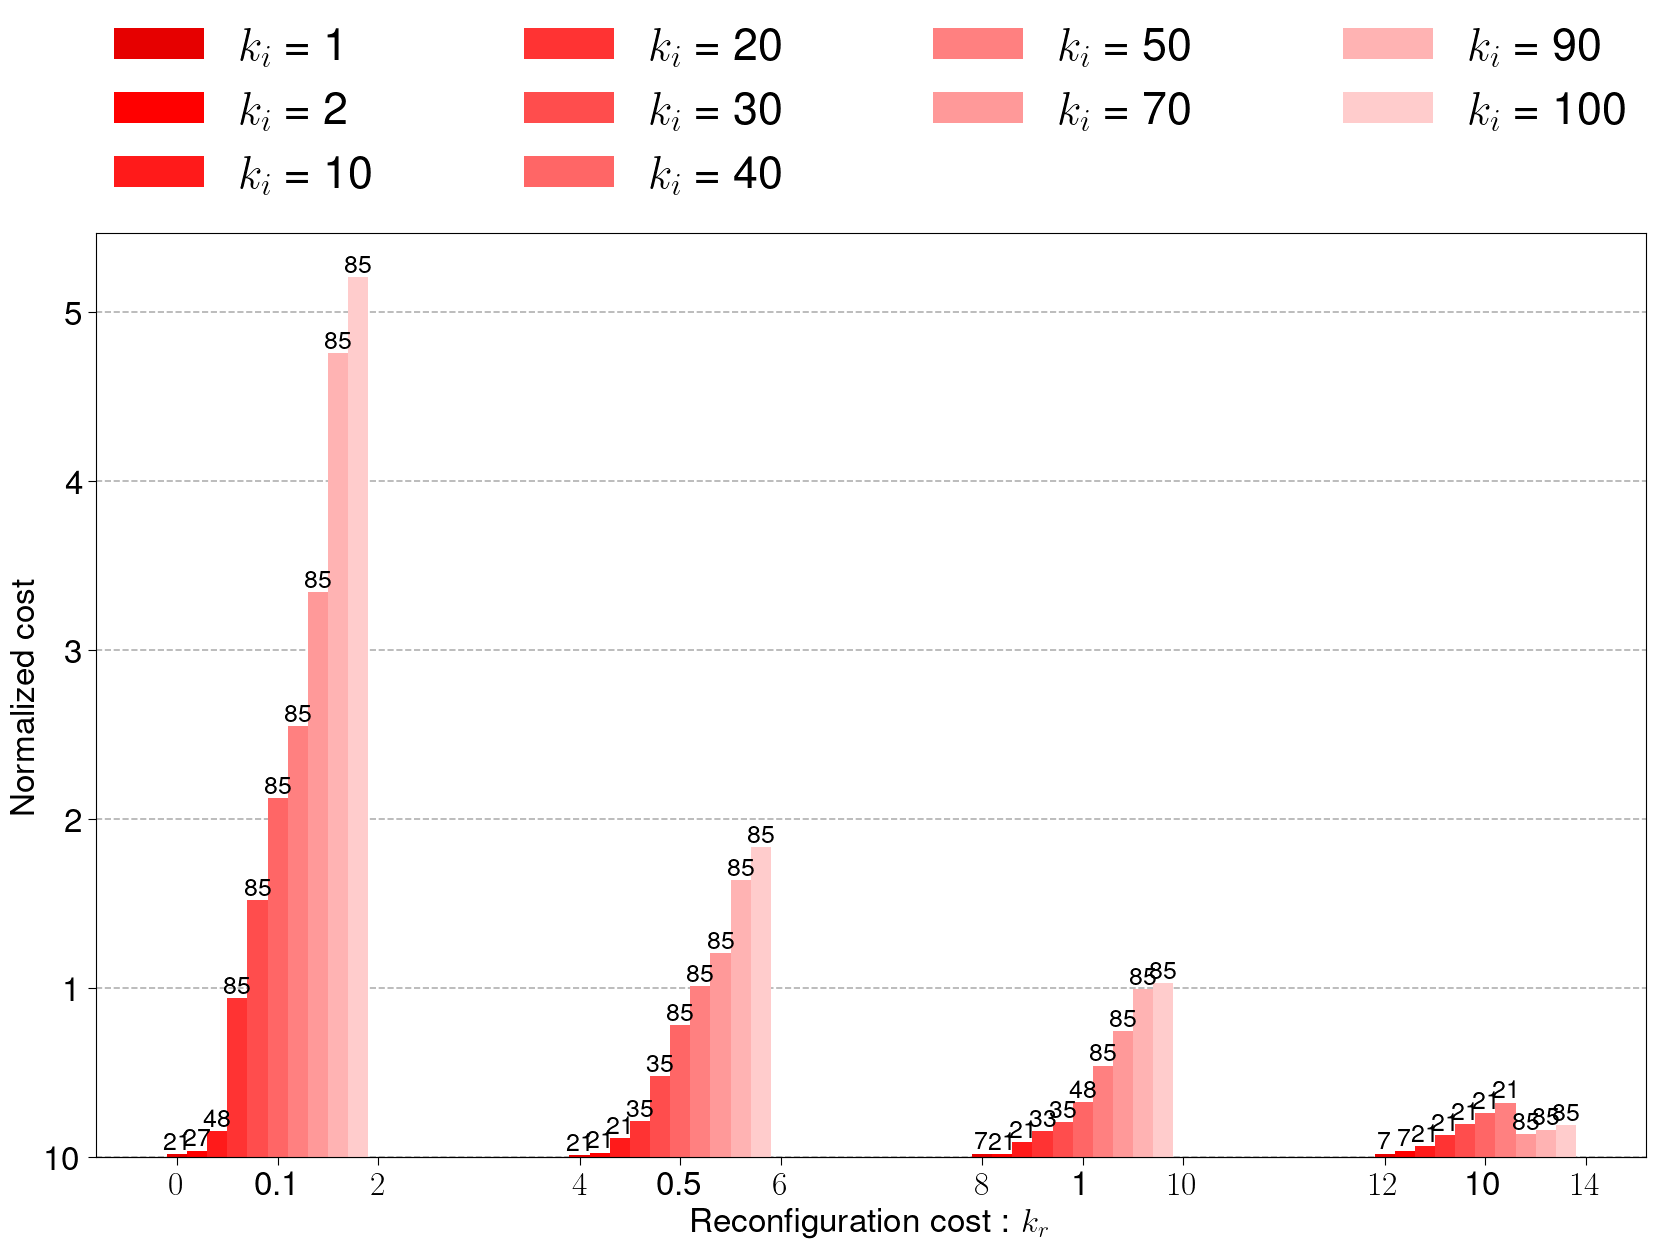

In [42]:


fig,ax = plt.subplots(figsize =(20,12))



clrs = ['#E60000',
        '#FF0000',
        '#FF1A1A',
        '#FF3333',
        '#FF4D4D',
        '#FF6666',
        '#FF8080',
        '#FF9999',
        '#FFB3B3',
        '#FFCCCC'
        ]

x = np.array([0,4,8,12])
# costs = cost_vs_tl[i]
costs = cost_vs_tl_aztec_plus

lbls = [
        u'$k_i$ = 1',
        u'$k_i$ = 2',
        u'$k_i$ = 10',
        u'$k_i$ = 20',
        u'$k_i$ = 30',
        u'$k_i$ = 40',
        u'$k_i$ = 50',
        u'$k_i$ = 70',
        u'$k_i$ = 90',
        u'$k_i$ = 100'
]

# lbls = [
#         u'$\eta$ = 1',
#         u'$\eta$ = 2',
#         u'$\eta$ = 10',
#         u'$\eta$ = 20',
#         u'$\eta$ = 30',
#         u'$\eta$ = 40',
#         u'$\eta$ = 50',
#         u'$\eta$ = 70',
#         u'$\eta$ = 90',
#         u'$\eta$ = 100'
# ]
width = 0.2
for i in range(10):
    ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')

for i in range(10):
        for j in range(4):
                ax.text(x[j]+i*width, costs[i,j], F'{int(windows_matrix[j,i])}', ha='center', va='bottom',fontsize=18,fontweight='bold')



#ax.set_yscale("log", nonposy='clip')

ax.set_xticks(x+5*width)
# ax.set_xticklabels([r'$\phi = 0.1$',r'$\phi = 0.5$',r'$\phi = 1$',r'$\phi = 10$'])
ax.set_xticklabels([0.1,0.5,1,10])
ax.set_yticks([0,1,2,3,4,5])
ax.set_yticklabels([10,1,2,3,4,5])
ax.set_ylabel('Normalized cost')
ax.set_xlabel(r'Reconfiguration cost : $k_r$')

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
        ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

# ax.set_xlabel('$\t_l$')
ax.grid(which='major', axis='y', linestyle='--')
secax = ax.secondary_xaxis('bottom')
#ax.legend()
# ax.set_title(F'Instantation cost per reconfiguration cost',y = 1.3)
# plt.tight_layout()


# plt.savefig('../FIGS/cost_vs_tl_phi_ki.pdf',bbox_inches = 'tight')
# plt.savefig('../FIGS/cost_vs_tl_phi_ki.png',bbox_inches = 'tight')
# plt.show()

In [79]:

# Define your custom colors



In [76]:
unique_values

array([ 7., 21., 27., 33., 35., 48., 85.])

In [77]:
color_dict

{7.0: (0.5019607843137255, 0.0, 0.0, 1.0),
 21.0: (0.8, 0.0, 0.0, 1.0),
 27.0: (1.0, 0.0, 0.0, 1.0),
 33.0: (1.0, 0.2, 0.2, 1.0),
 35.0: (1.0, 0.4, 0.4, 1.0),
 48.0: (1.0, 0.6, 0.6, 1.0),
 85.0: (1.0, 0.8, 0.8, 1.0)}

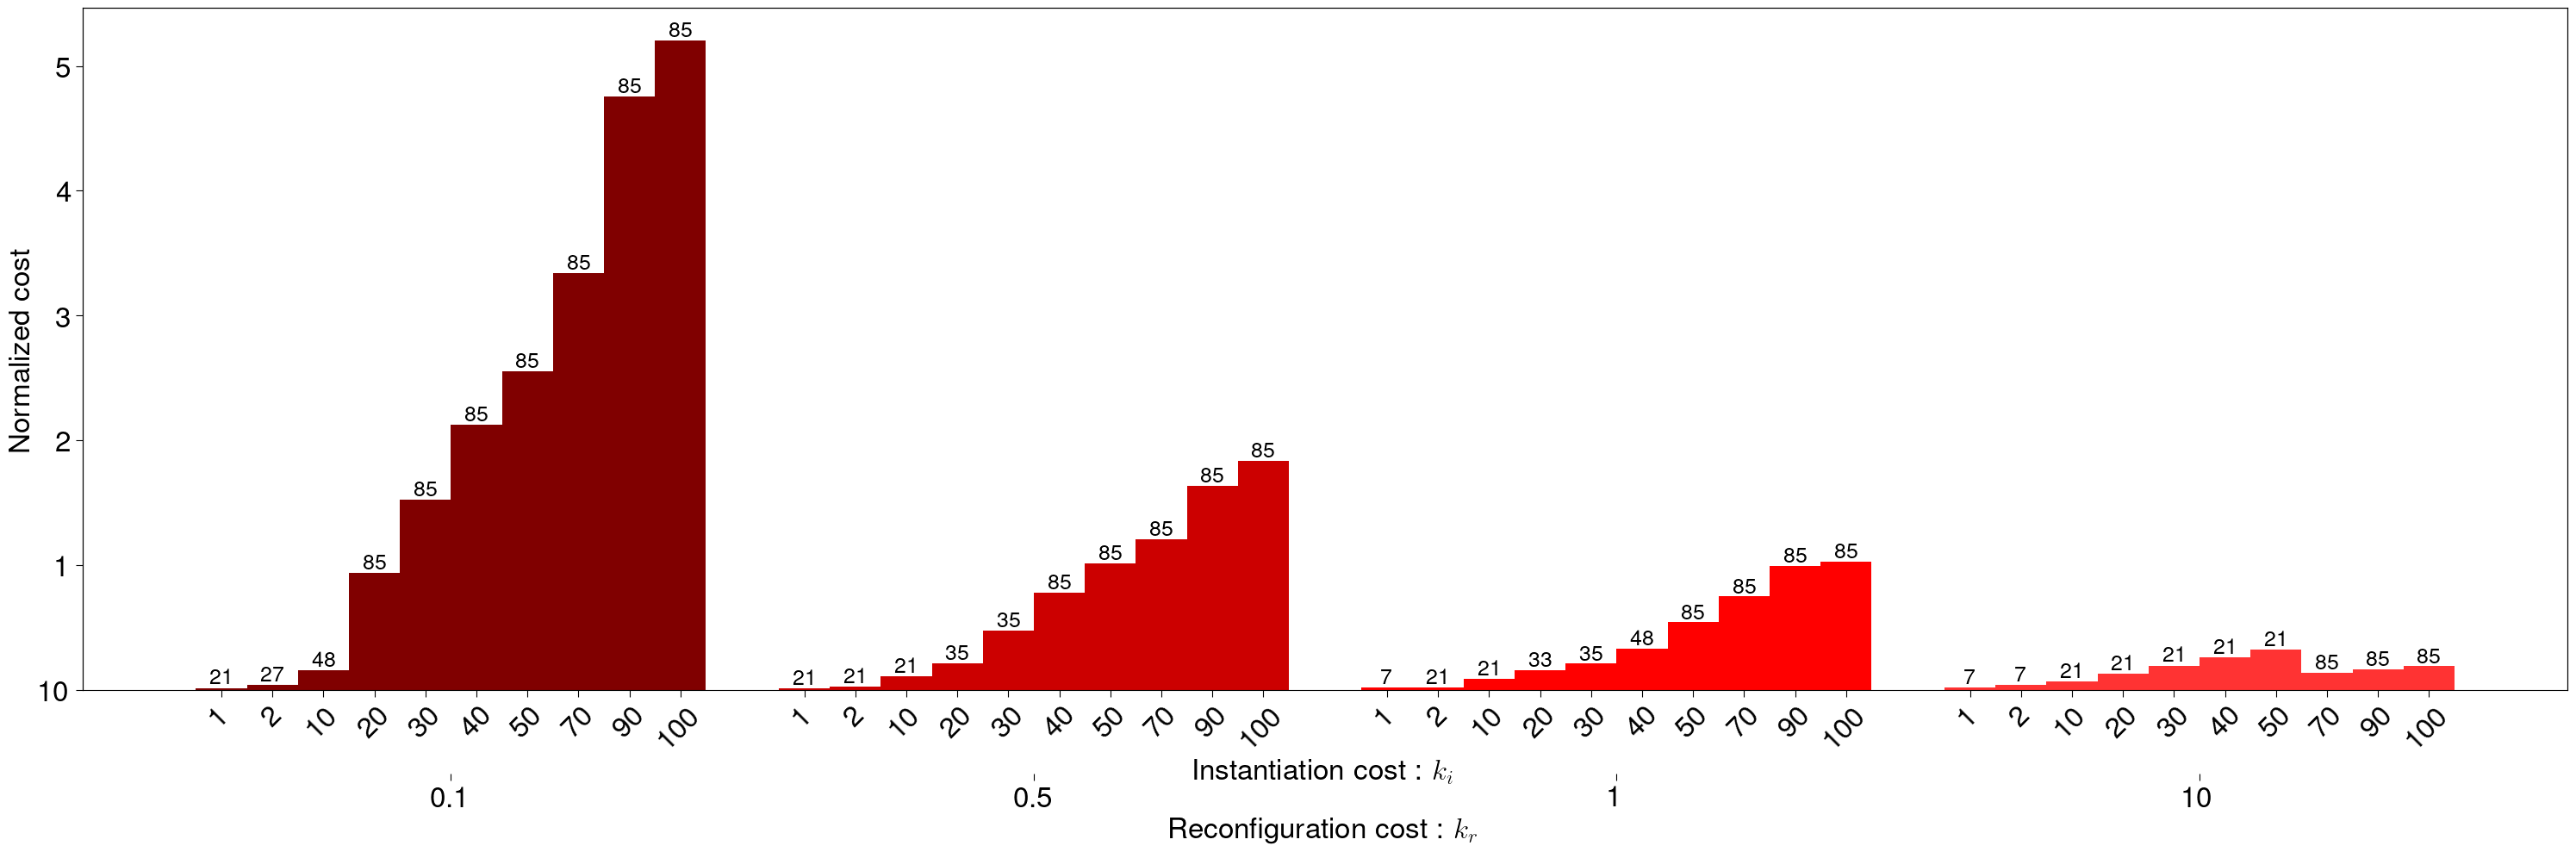

In [36]:
clrs = [ "#800000", "#CC0000" , "#FF0000", "#FF3333", "#FF6666", "#FF9999", '#FFB3B3']


# Create a colormap from these colors
custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", clrs, N=len(clrs))

unique_values = np.unique(windows_matrix)

color_dict = {value: custom_cmap(i) for i, value in enumerate(unique_values)}


group_colors = ["#800000", "#CC0000" , "#FF0000", "#FF3333",]


fig,ax = plt.subplots(figsize =(30,10))



# clrs = ['#E60000',
#         '#FF0000',
#         '#FF1A1A',
#         '#FF3333',
#         '#FF4D4D',
#         '#FF6666',
#         '#FF8080',
#         '#FF9999',
#         '#FFB3B3',
#         '#FFCCCC'
#         ]

x = np.array([0,8,16,24])
# costs = cost_vs_tl[i]
costs = cost_vs_tl_aztec_plus

lbls = [
        u'$k_i$ = 1',
        u'$k_i$ = 2',
        u'$k_i$ = 10',
        u'$k_i$ = 20',
        u'$k_i$ = 30',
        u'$k_i$ = 40',
        u'$k_i$ = 50',
        u'$k_i$ = 70',
        u'$k_i$ = 90',
        u'$k_i$ = 100'
]


width = 0.7
n_groups = 4
bars_per_group = 10
for i in range(bars_per_group):
#     bar_colors = [color_dict[val] for val in windows_matrix[:,i]]
    ax.bar(x+i*width,costs[i,:],width=width, color=[group_colors[j] for j in range(n_groups)],label=lbls[i])
#     ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')

for i in range(bars_per_group):
        for j in range(n_groups):
                ax.text(x[j]+i*width, costs[i,j], F'{int(windows_matrix[j,i])}', ha='center', va='bottom',fontsize=18,fontweight='bold')



# bars_per_group = 10
bar_width = width
indices = x

bar_labels = ['1','2','10','20','30','40','50','70','90','100']
group_labels = ['0.1','0.5','1','10']

#ax.set_yscale("log", nonposy='clip')


# Label for individual bars
individual_bar_ticks = np.concatenate([indices + i * bar_width for i in range(bars_per_group)])
individual_bar_labels = np.repeat(bar_labels, n_groups)
ax.set_xticks(individual_bar_ticks)
ax.set_xticklabels(individual_bar_labels,rotation = 45)
ax.xaxis.set_ticks_position('bottom')  # Set the ticks position
ax.xaxis.set_label_position('bottom')  # Set the label position

# Add another x-axis to label groups beneath the bars
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(indices + bar_width * (bars_per_group - 1) / 2)
ax2.set_xticklabels(group_labels)
ax2.xaxis.set_ticks_position('bottom')  # Set the ticks position
ax2.xaxis.set_label_position('bottom')  # Set the label position
ax2.spines['bottom'].set_position(('outward', 70))  # Position the group labels lower
ax2.set_frame_on(True)
ax2.patch.set_visible(False)


ax.set_yticks([0,1,2,3,4,5])
ax.set_yticklabels([10,1,2,3,4,5])
ax.set_ylabel('Normalized cost')

ax.set_xlabel(r'Instantiation cost : $k_i$')
ax2.set_xlabel(r'Reconfiguration cost : $k_r$')
ax2.spines['bottom'].set_visible(False)

# ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#         ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

# # ax.set_xlabel('$\t_l$')
# ax.grid(which='major', axis='y', linestyle='--')

#ax.legend()
# ax.set_title(F'Instantation cost per reconfiguration cost',y = 1.3)
plt.tight_layout()


# plt.savefig('../FIGS/cost_vs_tl_phi_ki_new.pdf',bbox_inches = 'tight')
# plt.savefig('../FIGS/cost_vs_tl_phi_ki_new.png',bbox_inches = 'tight')
# plt.show()

In [21]:
costs = cost_vs_tl_aztec_plus

NameError: name 'cost_vs_tl_aztec_plus' is not defined

In [45]:
costs[0,:]

array([0.01628736, 0.03895673, 0.15634482, 0.94019292, 1.52333128,
       2.12629524, 2.55107304, 3.34075466, 4.75467633, 5.2060232 ])

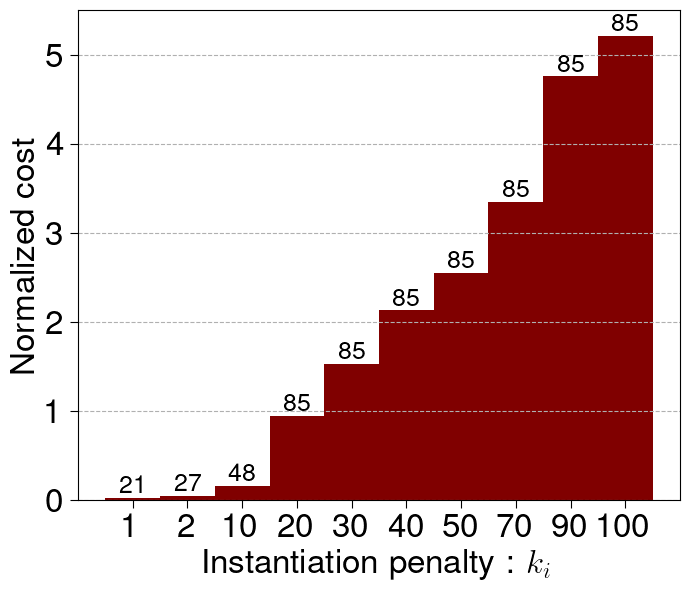

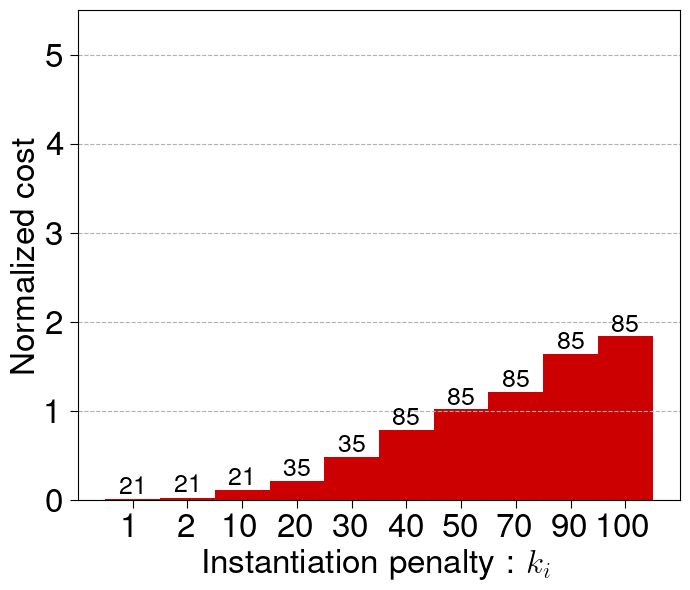

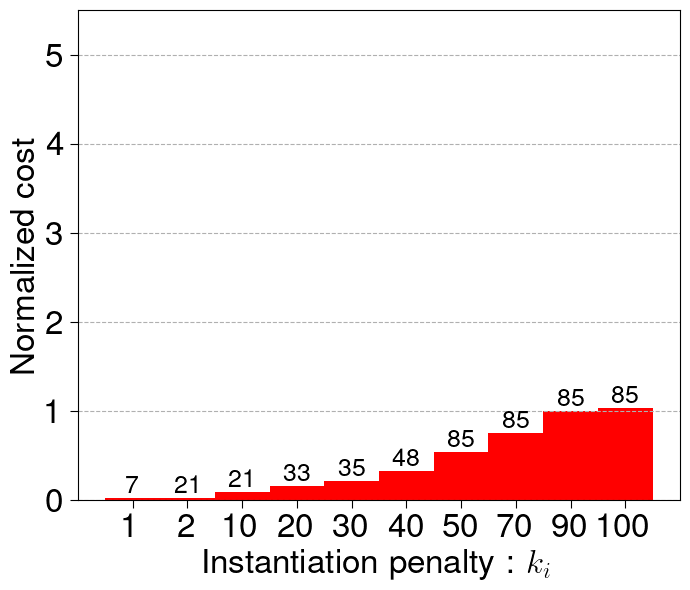

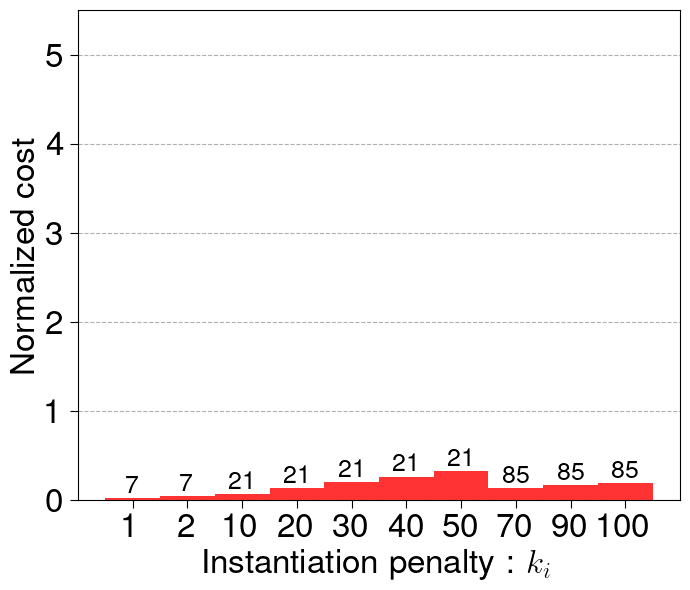

In [38]:
clrs = [ "#800000", "#CC0000" , "#FF0000", "#FF3333", "#FF6666", "#FF9999", '#FFB3B3']


# Create a colormap from these colors
custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", clrs, N=len(clrs))

unique_values = np.unique(windows_matrix)

color_dict = {value: custom_cmap(i) for i, value in enumerate(unique_values)}


group_colors = ["#800000", "#CC0000" , "#FF0000", "#FF3333",]


# fig,ax = plt.subplots(figsize =(7,6))



# clrs = ['#E60000',
#         '#FF0000',
#         '#FF1A1A',
#         '#FF3333',
#         '#FF4D4D',
#         '#FF6666',
#         '#FF8080',
#         '#FF9999',
#         '#FFB3B3',
#         '#FFCCCC'
#         ]

x = np.array([0])
# costs = cost_vs_tl[i]
costs = cost_vs_tl_aztec_plus.T

lbls = [
        u'$k_i$ = 1',
        u'$k_i$ = 2',
        u'$k_i$ = 10',
        u'$k_i$ = 20',
        u'$k_i$ = 30',
        u'$k_i$ = 40',
        u'$k_i$ = 50',
        u'$k_i$ = 70',
        u'$k_i$ = 90',
        u'$k_i$ = 100'
]


width = 0.7
n_groups = 4
bars_per_group = 10
for k in range(n_groups):
    
    fig,ax = plt.subplots(figsize =(7,6))

    for i in range(10):
    #     bar_colors = [color_dict[val] for val in windows_matrix[:,i]]
        ax.bar(x+i*width,costs[k,i],width=width, color=group_colors[k],label=lbls[i])
    #     ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
        #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')

    for i in range(bars_per_group):
        
        ax.text(x+i*width, costs[k,i], F'{int(windows_matrix[k,i])}', ha='center', va='bottom',fontsize=18,fontweight='bold')


    # bars_per_group = 10
    bar_width = width
    indices = x

    bar_labels = ['1','2','10','20','30','40','50','70','90','100']
    group_labels = ['0.1','0.5','1','10']

    # Label for individual bars
    individual_bar_ticks = np.concatenate([indices + i * bar_width for i in range(bars_per_group)])

    ax.set_yticks([0,1,2,3,4,5])
    ax.set_ylim(top=5.5)
    # if k == 0:
    ax.set_ylabel('Normalized monetary cost')
    
    ax.set_yticks([0,1,2,3,4,5])
    ax.set_yticklabels([0,1,2,3,4,5])
    ax.set_ylabel('Normalized cost')
    # else:
            # ax.set_yticklabels([])

    ax.set_xlabel(r'Instantation penalty, $\kappa_i$')
    ax.grid(which='both', axis='y', linestyle='--')

    ax.set_xticks(individual_bar_ticks)
    ax.set_xticklabels(bar_labels)


    # ax.set_yticks([0,1,2,3,4,5])
    # ax.set_yticklabels([0,1,2,3,4,5])
    # ax.set_ylabel('Normalized cost')

    ax.set_xlabel(r'Instantiation penalty : $k_i$')
    # ax2.set_xlabel(r'Reconfiguration penalty : $k_r$')
    # ax2.spines['bottom'].set_visible(False)

    
    plt.tight_layout()




    # plt.savefig(f'../FIGS/cost_vs_tl_phi_ki_new_{group_labels[k]}_ki.pdf',bbox_inches = 'tight')
    # plt.savefig(f'../FIGS/cost_vs_tl_phi_ki_new_{group_labels[k]}_ki.png',bbox_inches = 'tight')


    ###### Thesis plots with ylabels
    plt.savefig(f'../FIGS/cost_vs_tl_phi_ki_new_{group_labels[k]}_ki_Thesis.pdf',bbox_inches = 'tight')
    plt.savefig(f'../FIGS/cost_vs_tl_phi_ki_new_{group_labels[k]}_ki_Thesis.png',bbox_inches = 'tight')
    plt.show()


In [57]:
windows_matrix

array([[21., 27., 48., 85., 85., 85., 85., 85., 85., 85.],
       [21., 21., 21., 35., 35., 85., 85., 85., 85., 85.],
       [ 7., 21., 21., 33., 35., 48., 85., 85., 85., 85.],
       [ 7.,  7., 21., 21., 21., 21., 21., 85., 85., 85.]])

[[0.02830517 0.05144069 0.24652635]
 [0.14152586 0.25720344 1.23263173]
 [0.28305172 0.51440689 2.46526345]]


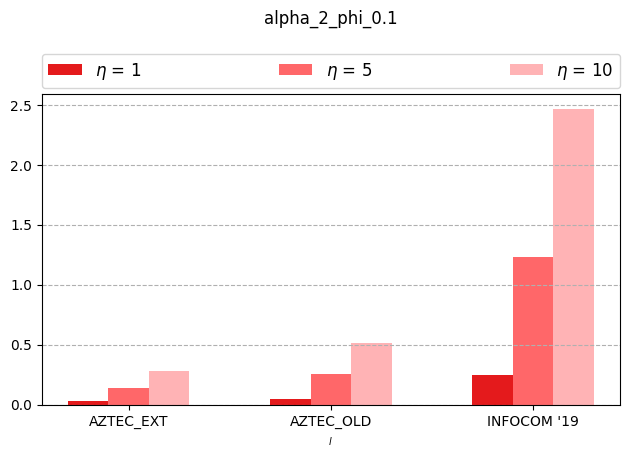

[[0.03862869 0.05000817 0.24652635]
 [0.19314346 0.25004084 1.23263173]
 [0.38628692 0.50008169 2.46526345]]


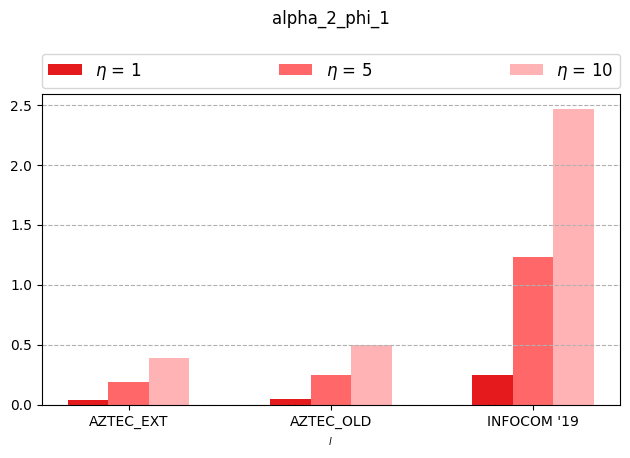

[[0.0632616  0.05024365 0.24652635]
 [0.316308   0.25121826 1.23263173]
 [0.63261599 0.50243651 2.46526345]]


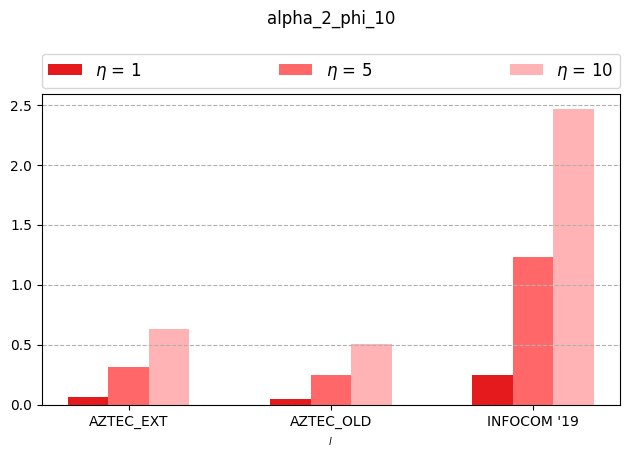

[[0.02885325 0.05149544 0.24747606]
 [0.14426624 0.25747721 1.23738029]
 [0.28853248 0.51495442 2.47476058]]


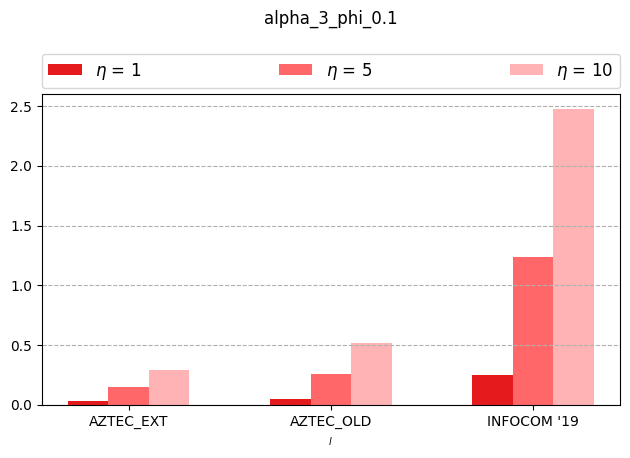

[[0.03864919 0.05005331 0.24747606]
 [0.19324596 0.25026655 1.23738029]
 [0.38649193 0.5005331  2.47476058]]


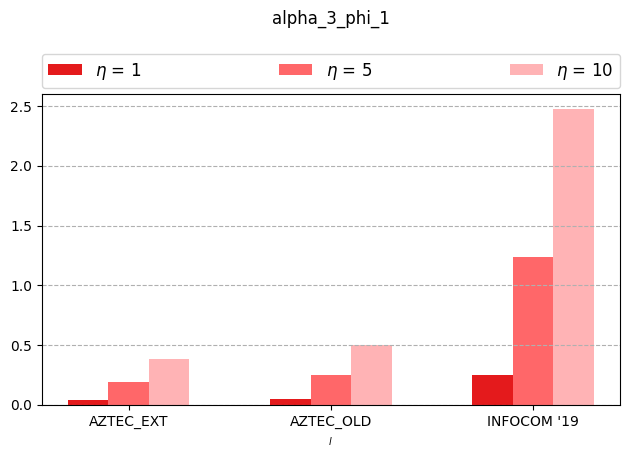

[[0.06323214 0.05024393 0.24747606]
 [0.31616069 0.25121967 1.23738029]
 [0.63232137 0.50243935 2.47476058]]


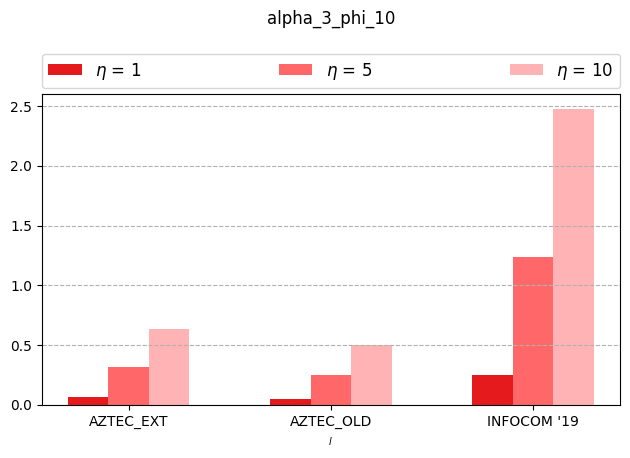

[[0.03033979 0.05162727 0.24779765]
 [0.15169893 0.25813635 1.23898823]
 [0.30339787 0.5162727  2.47797646]]


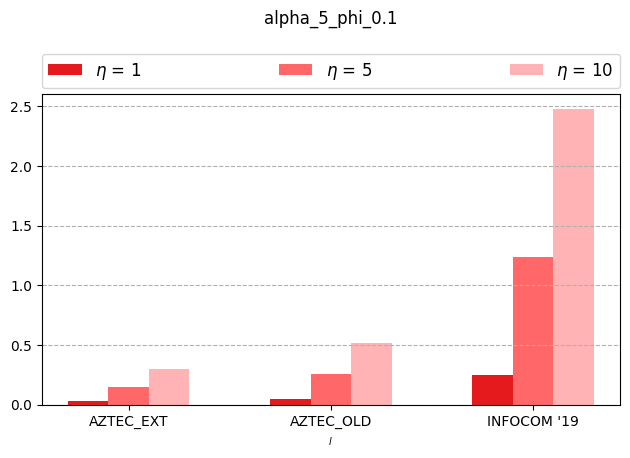

[[0.03882028 0.05002022 0.24779765]
 [0.1941014  0.25010108 1.23898823]
 [0.3882028  0.50020217 2.47797646]]


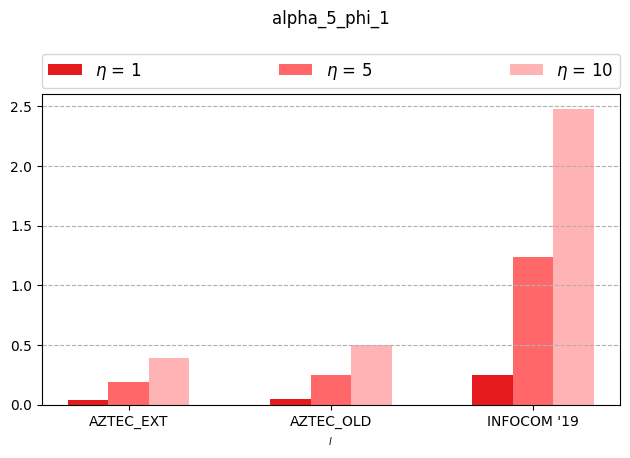

[[0.06324693 0.05024785 0.24779765]
 [0.31623464 0.25123924 1.23898823]
 [0.63246929 0.50247849 2.47797646]]


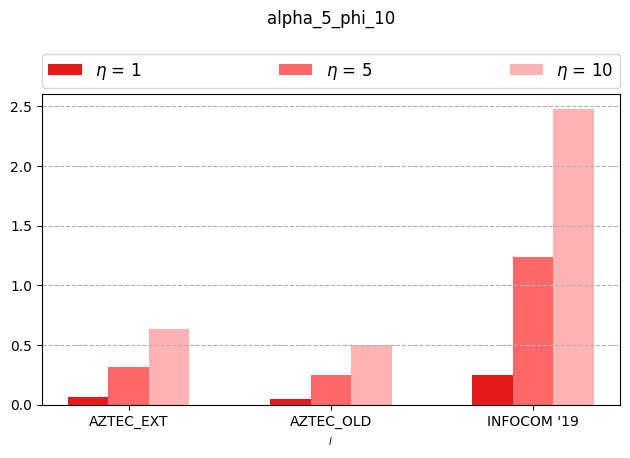

In [65]:
for j, alpha in enumerate(Alphas):
    for i, phi in enumerate(Phis):
    
        fig,ax = plt.subplots()



        clrs = ['#e41a1c',
                '#FF6769',
                '#FFB3B5']

        
        cost_instantation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
        cost_instantation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
        cost_instantation_eta_2_Deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(F'_alpha_{alpha}_')]['cost_instantiation_infocom19'].to_numpy()
        
        # print(cost_instantation_eta_2_Aztec_ext)

        cost_instantation_eta_10_Aztec_ext =  cost_instantation_eta_2_Aztec_ext * 5
        cost_instantation_eta_10_Aztec_old =  cost_instantation_eta_2_Aztec_old * 5
        cost_instantation_eta_10_Deepcog =  cost_instantation_eta_2_Deepcog * 5

        cost_instantation_eta_20_Aztec_ext =  cost_instantation_eta_2_Aztec_ext * 10
        cost_instantation_eta_20_Aztec_old =  cost_instantation_eta_2_Aztec_old * 10
        cost_instantation_eta_20_Deepcog =  cost_instantation_eta_2_Deepcog * 10

        cost_vs_tl = np.zeros((3,3))
        cost_vs_tl[0,:] = [cost_instantation_eta_2_Aztec_ext[i], cost_instantation_eta_2_Aztec_old[i], cost_instantation_eta_2_Deepcog[i]]
        cost_vs_tl[1,:] = [cost_instantation_eta_10_Aztec_ext[i], cost_instantation_eta_10_Aztec_old[i], cost_instantation_eta_10_Deepcog[i]]
        cost_vs_tl[2,:] = [cost_instantation_eta_20_Aztec_ext[i], cost_instantation_eta_20_Aztec_old[i], cost_instantation_eta_20_Deepcog[i]]

        print (cost_vs_tl)

        x = np.arange(3)
        costs = cost_vs_tl

        lbls = [
                u'$\eta$ = 1',
                u'$\eta$ = 5',
                u'$\eta$ = 10'
        ]
        width = 0.2
        for i in range(3):
            ax.bar(x+i*width,costs[i,:],width=width,color=clrs[i],label=lbls[i])
            #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')



        #ax.set_yscale("log", nonposy='clip')

        ax.set_xticks(x+1*width)
        ax.set_xticklabels(['AZTEC_EXT','AZTEC_OLD','INFOCOM \'19'])
        #ax.set_yticks([1,10,100,1000])
        #ax.set_yticklabels([1,10,100,1000])

        ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
                   ncol=4, mode="expand", borderaxespad=0.,fontsize='large')

        ax.set_xlabel('$\t_l$')
        ax.grid(which='major', axis='y', linestyle='--')
        #ax.legend()
        ax.set_title(F'alpha_{alpha}_phi_{phi}',y = 1.2)
        plt.tight_layout()
        # plt.savefig('cost_vs_tl_phi_%s_beta_%s.pdf' % (ph, step))
        plt.show()

# Cost breakdown vs TI


In [235]:
infocom_17_results

,total_cost,cost_overprovisioning_infocom,cost_slas_infocom_17,cost_instantiation_infocom17,cost_reconfiguration
Paris_phi_0.1_alpha_2_delay_1,2.502217,0.08299,2.188902,0.209774,0.020551
Paris_phi_1_alpha_2_delay_1,2.687173,0.08299,2.188902,0.209774,0.205507
Paris_phi_10_alpha_2_delay_1,4.536736,0.08299,2.188902,0.209774,2.055070


In [236]:
Aztec_ext_results_default

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.365972,0.252667,0.078796,0.032154,0.002354
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.408549,0.270394,0.102988,0.032822,0.002345
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.470611,0.296082,0.138773,0.033428,0.002328
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.289075,0.230029,0.019327,0.038818,0.000901
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.308734,0.244972,0.024037,0.038837,0.000889
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_7,0.329104,0.259326,0.029899,0.038992,0.000888
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.400435,0.353825,0.006417,0.039020,0.001174
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.404982,0.355536,0.009251,0.039021,0.001174
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.417390,0.362123,0.014951,0.039028,0.001289


In [130]:
cost_overprovisioning_static_list_np[alpha_idx,phi_idx]

array([0.21681387, 0.25611874, 0.27957395, 0.36379789, 0.3636718 ,
       0.37344873, 0.35899224, 0.36122819, 0.3579652 , 0.36310732])

In [19]:
def Retrieve_breakdown(df,phi,eta,alpha=2,benchmark=None, cost_overprovisioning_static=None,cost_overprovisioning_shared = None,phi_idx = 0,alpha_idx = 0,eta_idx = 0):
    res = np.zeros(5)
    if benchmark == None:
        res[0] = cost_overprovisioning_static[alpha_idx,phi_idx,eta_idx]
        res[1] = cost_overprovisioning_shared[alpha_idx,phi_idx,eta_idx]
        res[2] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_slas'].to_numpy()
        res[3] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
        res[4] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
    if benchmark == 'aztec_old':
        res[0] = cost_overprovisioning_static[alpha_idx,phi_idx]
        res[1] = cost_overprovisioning_shared[alpha_idx,phi_idx]
        res[2] = df[df.index.str.contains(f'phi_{phi}_eta_2_alpha_{alpha}_')]['cost_slas'].to_numpy()
        res[3] = df[df.index.str.contains(f'phi_{phi}_eta_2_alpha_{alpha}_')]['cost_instantiation'].to_numpy()* eta
        res[4] = df[df.index.str.contains(f'phi_{phi}_eta_2_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
        

    return res

In [20]:
Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]
ALPHAS = [2,3,5]

phi_idx = 3
alpha_idx = 0
eta_idx = 0


phi = Phis[phi_idx]
eta = ETAS[eta_idx]
alpha = ALPHAS [alpha_idx]





res_aztec_plus = Retrieve_breakdown(Aztec_ext_results_default,phi,eta,alpha,benchmark=None,
                                    cost_overprovisioning_static=cost_overprovisioning_static_list_np,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np,phi_idx = phi_idx,
                                    alpha_idx = alpha_idx,eta_idx = eta_idx)
res_aztec_old = Retrieve_breakdown(Aztec_old_results_merged_default,phi,eta,alpha,benchmark='aztec_old', 
                                   cost_overprovisioning_static=cost_overprovisioning_static_list_np_6,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np_6,phi_idx = phi_idx,
                                   alpha_idx = alpha_idx,eta_idx = eta_idx)


/tmp/ipykernel_3901654/3805954466.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[2] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_slas'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[3] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[4]

In [21]:
Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]
ALPHAS = [2,3,5]

phi_idx = 3
alpha_idx = 0
eta_idx = 0


phi = Phis[phi_idx]
eta = ETAS[eta_idx]
alpha = ALPHAS [alpha_idx]





res_aztec_plus = Retrieve_breakdown(Aztec_ext_results_default,phi,eta,alpha,benchmark=None,
                                    cost_overprovisioning_static=cost_overprovisioning_static_list_np,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np,phi_idx = phi_idx,
                                    alpha_idx = alpha_idx,eta_idx = eta_idx)
res_aztec_old = Retrieve_breakdown(Aztec_old_results_merged_default,phi,eta,alpha,benchmark='aztec_old', 
                                   cost_overprovisioning_static=cost_overprovisioning_static_list_np_6,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np_6,phi_idx = phi_idx,
                                   alpha_idx = alpha_idx,eta_idx = eta_idx)


cost_tl_breakdown = np.zeros ((5,2))
cost_tl_breakdown[0,:] = [res_aztec_plus[0],res_aztec_old[0]]
cost_tl_breakdown[1,:] = [res_aztec_plus[1],res_aztec_old[1]]
cost_tl_breakdown[2,:] = [res_aztec_plus[2],res_aztec_old[2]]
cost_tl_breakdown[3,:] = [res_aztec_plus[3],res_aztec_old[3]]
cost_tl_breakdown[4,:] = [res_aztec_plus[4],res_aztec_old[4]]

/tmp/ipykernel_3901654/3805954466.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[2] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_slas'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[3] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[4]

In [32]:
Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_40_alpha_3_delay_48')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_40_alpha_3_delay_48,1.069191,0.401295,0.26232,0.379683,0.025892


In [29]:
res_aztec_plus

array([0.3486267 , 0.00100422, 0.00710891, 0.0190732 , 0.00124137])

In [25]:
cost_tl_breakdown

array([[3.48626705e-01, 3.60428364e-01],
       [1.00421685e-03, 2.70472980e-04],
       [7.10890962e-03, 7.89346617e-03],
       [1.90732032e-02, 5.02449334e-02],
       [1.24137496e-03, 1.33911131e-03]])

In [26]:

costs = cost_tl_breakdown.T

In [27]:
costs.shape

(2, 5)

In [28]:
clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]

In [81]:
x = [0,1,2,3]

In [82]:
import matplotlib.patches as mpatches

/tmp/ipykernel_3901654/3805954466.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[2] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_slas'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[3] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[4]

/tmp/ipykernel_3901654/3805954466.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[2] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_slas'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[3] = df[df.index.str.contains(f'phi_{phi}_eta_{eta}_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
/tmp/ipykernel_3901654/3805954466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res[4]

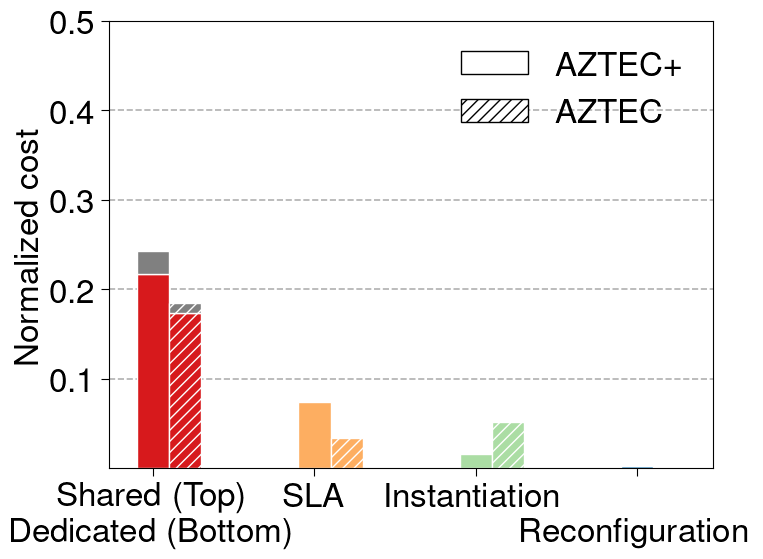

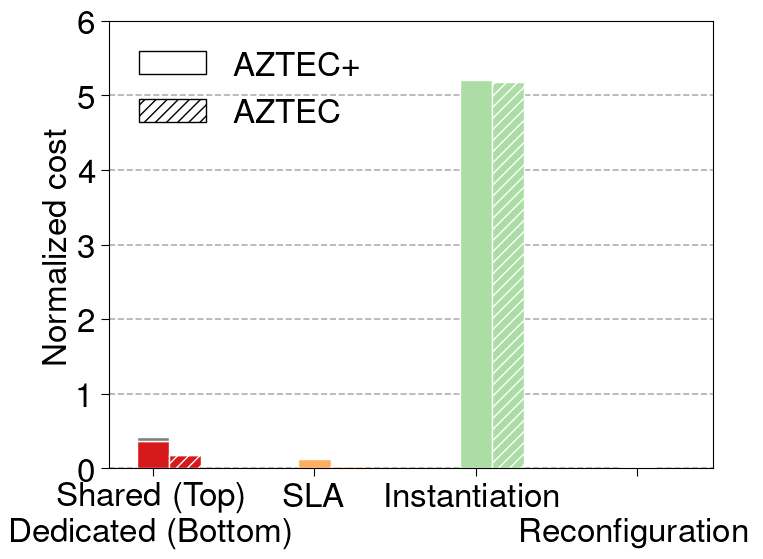

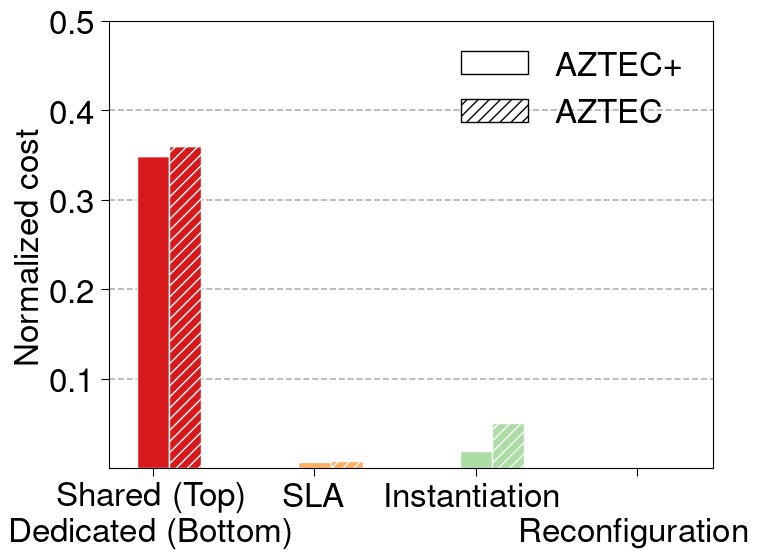

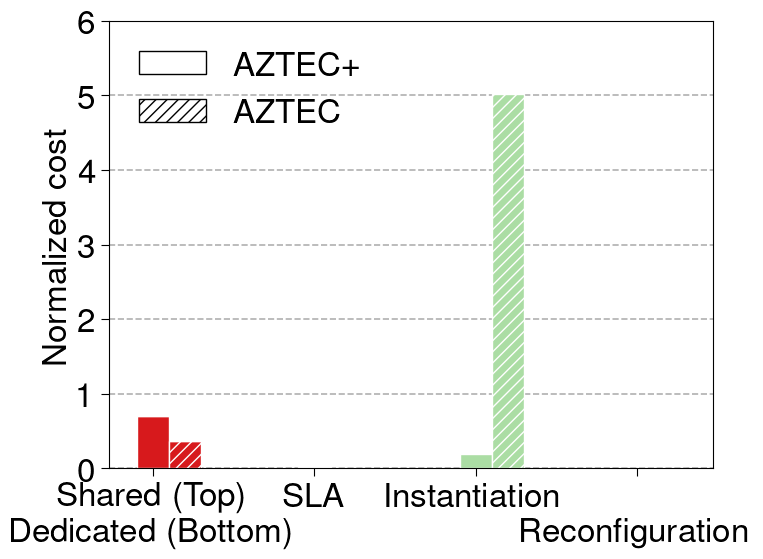

In [25]:
Phis = [0.1,0.5,1,10]
ETAS =[1,2,10,20,30,40,50,70,90,100]
ALPHAS = [2,3,5]

phi_idx = 3
alpha_idx = 0
eta_idx = 0

Phis_idx = [0,3]
ETAS_idx =[0,9]

width = 0.2


for phi_idx in Phis_idx:
    for eta_idx in ETAS_idx:
        phi = Phis[phi_idx]
        eta = ETAS[eta_idx]
        alpha = ALPHAS [alpha_idx]



        res_aztec_plus = Retrieve_breakdown(Aztec_ext_results_default,phi,eta,alpha,benchmark=None,
                                            cost_overprovisioning_static=cost_overprovisioning_static_list_np,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np,phi_idx = phi_idx,
                                            alpha_idx = alpha_idx,eta_idx = eta_idx)
        res_aztec_old = Retrieve_breakdown(Aztec_old_results_merged_default,phi,eta,alpha,benchmark='aztec_old', 
                                        cost_overprovisioning_static=cost_overprovisioning_static_list_np_6,cost_overprovisioning_shared = cost_overprovisioning_shared_list_np_6,phi_idx = phi_idx,
                                        alpha_idx = alpha_idx,eta_idx = eta_idx)


        cost_tl_breakdown = np.zeros ((5,2))
        cost_tl_breakdown[0,:] = [res_aztec_plus[0],res_aztec_old[0]]
        cost_tl_breakdown[1,:] = [res_aztec_plus[1],res_aztec_old[1]]
        cost_tl_breakdown[2,:] = [res_aztec_plus[2],res_aztec_old[2]]
        cost_tl_breakdown[3,:] = [res_aztec_plus[3],res_aztec_old[3]]
        cost_tl_breakdown[4,:] = [res_aztec_plus[4],res_aztec_old[4]]

        costs = cost_tl_breakdown.T


        x = [0,1,2,3]

        transp =1
        plt.rcParams.update({'font.size': 20})
        # fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
        fig, ax = plt.subplots(figsize=(8,6))


        # clrs = ['#e41a1c',
        #             '#377eb8',
        #             '#4daf4a',
        #             '#984ea3']

        # clrs = ['#fcae91',
        #         '#fb6a4a',
        #         '#de2d26',
        #         '#a50f15',
        #         '#a50f15'][::-1]
        
        clrs = ['#d7191c',
                  '#fdae61',
                  '#abdda4',
                  '#2b83ba']

        # fig, ax = plt.subplots()

        ax.bar(x[0],costs[0,0],width=width,edgecolor='w',color=clrs[0])
        ax.bar(x[0],costs[0,1],width=width,bottom=costs[0,0],edgecolor='w',facecolor='#808080')

        for i in range(1,4):
            ax.bar(x[i],costs[0,i+1],width=width,edgecolor='w',color=clrs[i])

        aztec_hatch = '///'

        bars = ax.bar(x[0]+width,costs[1,0],width=width,edgecolor='w',color=clrs[0],hatch=aztec_hatch ,alpha  = transp)
        # for bar in bars:
        #         bar.set_edgecolor('black')

        bars = ax.bar(x[0]+width,costs[1,1],width=width,bottom=costs[1,0],edgecolor='w',facecolor='#808080',hatch =aztec_hatch,alpha  = transp)
        # for bar in bars:
        #         bar.set_edgecolor('black')

        for i in range(1,4):
            bars =ax.bar(x[i]+width,costs[1,i+1],width=width,edgecolor='w',color=clrs[i],hatch =aztec_hatch, alpha  = transp)
            # for bar in bars:
            #     bar.set_edgecolor('black')
        # for patch in ax.patches:
        #     patch.set_edgecolor('black')
        


        ax.set_xticks(x)
        ax.set_xticklabels(['Shared (Top)\n Dedicated (Bottom)','SLA','Instantiation',' \n Reconfiguration'])

        if eta == 100:

            ax.set_ylim(top=6)
            ax.set_yticks([0,1,2,3,4,5,6])
            ax.set_yticklabels([0,1,2,3,4,5,6])
        elif eta == 1:
            ax.set_ylim(top=0.5)
            ax.set_yticks([0.1,0.2,0.3,0.4,0.5])
            ax.set_yticklabels([0.1,0.2,0.3,0.4,0.5])

        # ax.set_ylim(top=0.5)
        ax.grid(which='major', axis='y', linestyle='--')

        legend_handles = [mpatches.Patch(facecolor='white', edgecolor='black', label='AZTEC')
            ,mpatches.Patch(facecolor='white', edgecolor='black', hatch=aztec_hatch, label='AZTEC') ]
        ax.legend(legend_handles, ['AZTEC+','AZTEC'],fontsize='large')

        ax.set_ylabel('Normalized cost')

        # plt.title (f' Cost breakdown for $k_r$ : {phi} , $k_i$ : {eta}')
        plt.savefig('../FIGS/cost_breakdown_phi_%s_eta_%s.pdf' % (phi,eta),bbox_inches = 'tight')
        plt.savefig('../FIGS/cost_breakdown_phi_%s_eta_%s.pdf' % (phi,eta),bbox_inches = 'tight')


        fig.tight_layout()


[5.2060232  5.18059294]


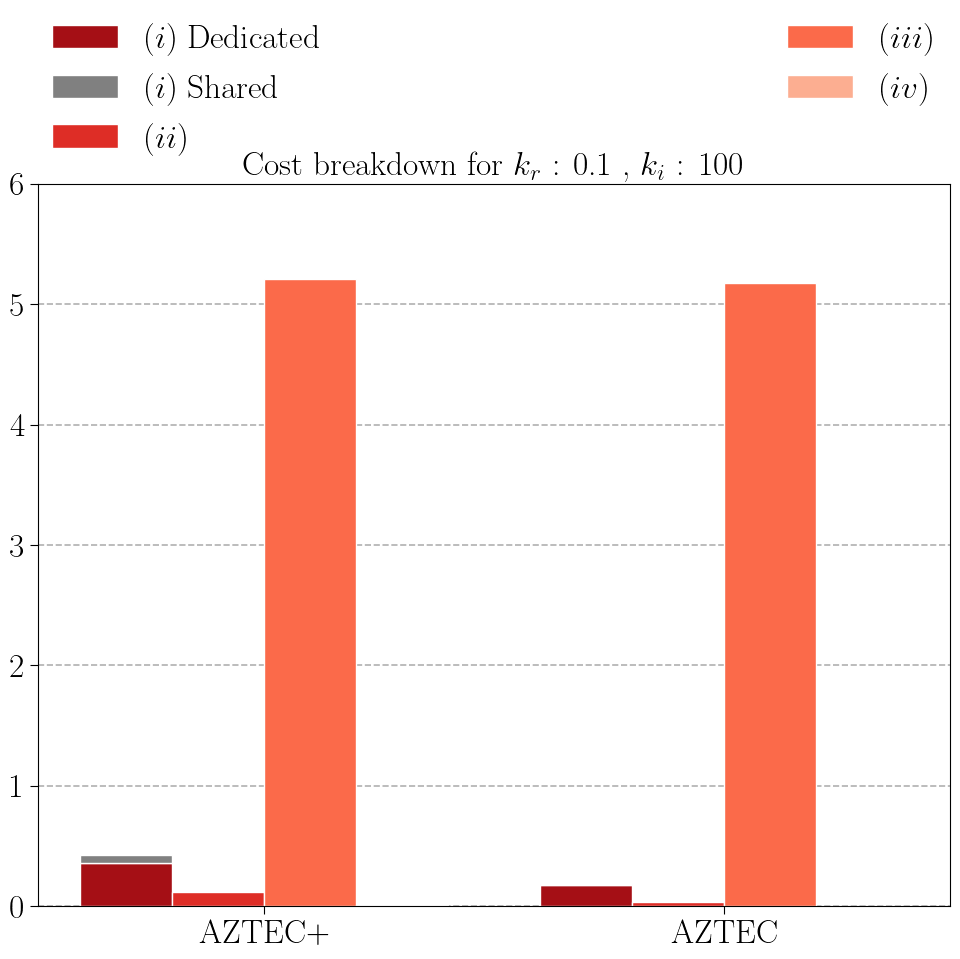

In [57]:
plt.rcParams.update({'font.size': 20})
# fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
fig, ax = plt.subplots(figsize=(10,10))



clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]


costs = cost_tl_breakdown

x = np.arange(2)

print(costs[3,:])

lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
# ax.set_xticklabels([6,12,24])
# ax.set_yticks([0,0.2,0.4,0.6,0.8])
# ax.set_yticklabels([0,0.2,0.4,0.6,0.8])

ax.set_xticklabels(['AZTEC+','AZTEC'])
ax.set_ylim(top=6)
# ax.set_ylim(top=0.5)
ax.grid(which='major', axis='y', linestyle='--')
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.)


# ax.set_xlabel('Extended interval, $T_l$')
plt.title (f' Cost breakdown for $k_r$ : {phi} , $k_i$ : {eta}')


plt.tight_layout()
# plt.savefig('../FIGS/cost_breakdown_vs_tl.pdf')
# plt.show()

In [117]:
eta = 1
alpha = 2

cost_SLA_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_slas'].to_numpy()
cost_instantiation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
cost_reconfiguration_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
cost_SLA_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_slas'].to_numpy()
cost_instantiation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
cost_reconfiguration_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()


cost_overprovisioning_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_overprovisioning_infocom'].to_numpy()
cost_sla_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_slas_infocom_19'].to_numpy()
cost_reconfiguration_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
cost_instantation_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation_infocom19'].to_numpy()

cost_SLA_eta_2_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(f'_alpha_{alpha}_')]['cost_slas_infocom_17'].to_numpy()
cost_instantation_eta_2_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation_infocom17'].to_numpy()
cost_reconfiguration_eta_2_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
cost_overprovisioning_infocom_17 = infocom_17_results[infocom_17_results.index.str.contains(f'_alpha_{alpha}_')]['cost_overprovisioning_infocom'].to_numpy()


In [238]:
cost_SLA_eta_2_Aztec_ext

array([0.07879571, 0.01932745, 0.00641673])

In [239]:
cost_overprovisioning_static_list_np

array([[0.22505189, 0.21651203, 0.35247401],
       [0.2392309 , 0.22514138, 0.35298063],
       [0.26143124, 0.23161489, 0.35507999]])

In [122]:
cost_overprovisioning_infocom_17

array([0.08298978, 0.08298978, 0.08298978, 0.08298978])

In [124]:
cost_overprovisioning_static_list_np_6[alpha_idx,phi_idx]

0.1737742809311685

In [127]:
cost_overprovisioning_static_list_np[alpha_idx,phi_idx]

array([0.21681387, 0.25611874, 0.27957395, 0.36379789, 0.3636718 ,
       0.37344873, 0.35899224, 0.36122819, 0.3579652 , 0.36310732])

In [128]:
cost_SLA_eta_2_Aztec_ext[phi_idx]

0.0736323947194478

In [182]:
eta = 1
phi_idx =0# idx_ 0 = 0.1 , idx_1 = 1, idx_2 = 10
alpha_idx = 0 # idx_ 0 = 2 , idx_1 = 3, idx_2 = 5
eta_idx = 1






cost_tl_breakdown = np.zeros((5,4))
cost_tl_breakdown[0,:] = [cost_overprovisioning_static_list_np[alpha_idx,phi_idx,eta_idx], cost_overprovisioning_static_list_np_6[alpha_idx,phi_idx], cost_overprovisioning_deepcog[alpha_idx], cost_overprovisioning_infocom_17[alpha_idx]]
cost_tl_breakdown[1,:] = [cost_overprovisioning_shared_list_np[alpha_idx,phi_idx,eta_idx], cost_overprovisioning_shared_list_np_6[alpha_idx,phi_idx], 0,0]
cost_tl_breakdown[2,:] = [cost_SLA_eta_2_Aztec_ext[phi_idx], cost_SLA_eta_2_Aztec_old[phi_idx], cost_sla_deepcog[phi_idx], cost_SLA_eta_2_infocom_17[phi_idx]]
cost_tl_breakdown[3,:] = [cost_instantiation_eta_2_Aztec_ext[phi_idx]*eta, cost_instantiation_eta_2_Aztec_old[phi_idx] * eta, cost_instantation_deepcog[phi_idx] * eta, cost_instantation_eta_2_infocom_17[phi_idx] * eta]
cost_tl_breakdown[4,:] = [cost_reconfiguration_eta_2_Aztec_ext[phi_idx], cost_reconfiguration_eta_2_Aztec_old[phi_idx], cost_reconfiguration_deepcog[phi_idx], cost_reconfiguration_eta_2_infocom_17[phi_idx]]

In [183]:
cost_overprovisioning_shared_list_np

array([[[0.02627959, 0.04024947, 0.03401093, 0.06658335, 0.0640753 ,
         0.0635272 , 0.05822105, 0.06667137, 0.05588958, 0.06132599],
        [0.03604981, 0.05487254, 0.03599808, 0.06572892, 0.08683048,
         0.07417066, 0.08075837, 0.07541402, 0.08094059, 0.07836117],
        [0.01158887, 0.03191556, 0.03386219, 0.05124476, 0.06259667,
         0.06518162, 0.09320726, 0.09098148, 0.09642269, 0.09497345],
        [0.00100422, 0.00146836, 0.00126617, 0.00095509, 0.00154931,
         0.00082224, 0.00124008, 0.02091993, 0.01142685, 0.01177701]],

       [[0.02811887, 0.04721203, 0.03777848, 0.0785789 , 0.0690971 ,
         0.06683012, 0.07082821, 0.07517036, 0.07015523, 0.07409115],
        [0.04453548, 0.06761756, 0.04168965, 0.07603104, 0.10428745,
         0.10929394, 0.11013667, 0.11712772, 0.1121412 , 0.12174169],
        [0.01939709, 0.0403866 , 0.04261072, 0.05950996, 0.07468188,
         0.08412253, 0.14840504, 0.13445286, 0.14322121, 0.11090313],
        [0.00163064, 0.00

In [184]:
cost_overprovisioning_shared_list_np_6

array([[0.01132879, 0.0094864 , 0.00509608, 0.00027047],
       [0.01298222, 0.01109323, 0.00935538, 0.00047334],
       [0.01588808, 0.01602629, 0.01430828, 0.00189842]])

In [185]:
cost_tl_breakdown

array([[2.56118738e-01, 1.73774281e-01, 6.00008701e-01, 8.29897841e-02],
       [4.02494683e-02, 1.13287866e-02, 0.00000000e+00, 0.00000000e+00],
       [7.36323947e-02, 3.32913134e-02, 3.17075016e-02, 2.18890237e+00],
       [1.62873631e-02, 5.18059294e-02, 2.46526345e-01, 2.09773830e-01],
       [2.28963687e-03, 4.06237140e-04, 2.47975357e-02, 2.05506976e-02]])

[0.01628736 0.05180593 0.24652635 0.20977383]


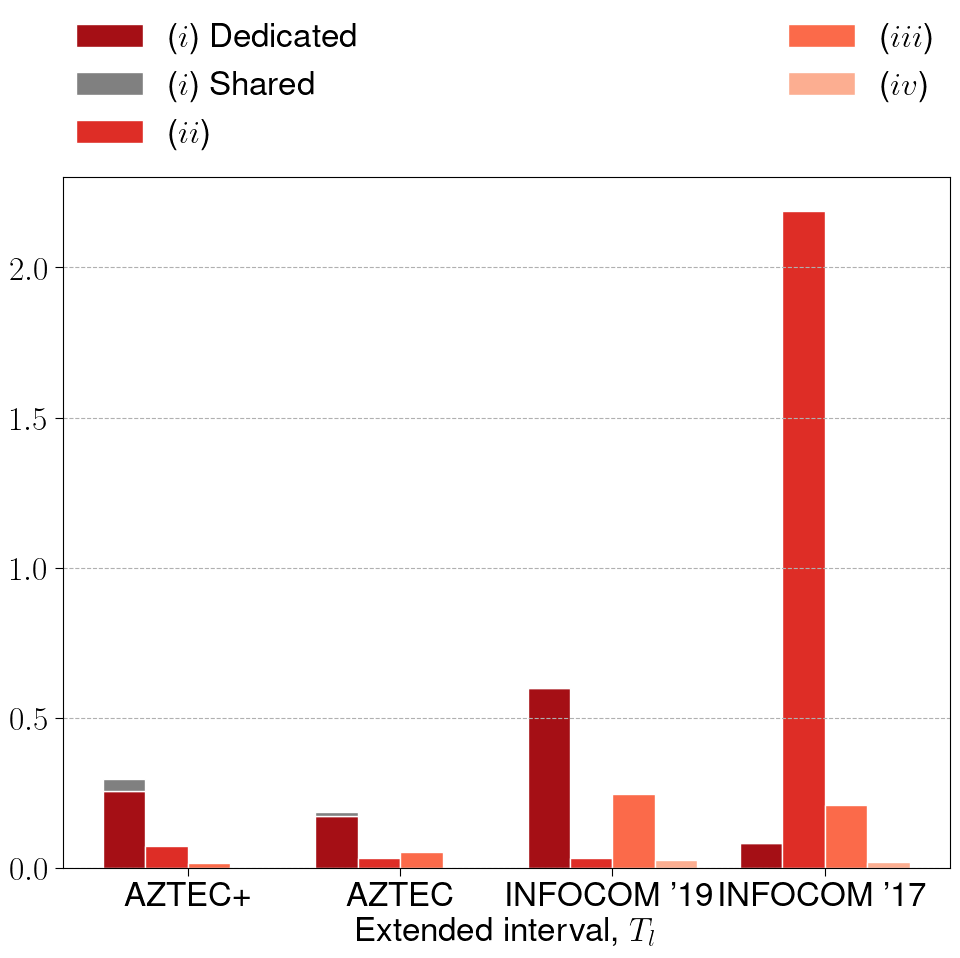

In [186]:
plt.rcParams.update({'font.size': 20})
# fig,ax = plt.subplots(figsize=1.2*figaspect(1.2))
fig, ax = plt.subplots(figsize=(10,10))



clrs = ['#fcae91',
        '#fb6a4a',
        '#de2d26',
        '#a50f15',
        '#a50f15'][::-1]


costs = cost_tl_breakdown

x = np.arange(4)

print(costs[3,:])

lbs = ['($i$) Dedicated','($i$) Shared',' ($ii$)','($iii$)', '($iv$)']
#lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Rec.']

width = 0.2



ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
for i in range(2,5):
    ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
    #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




#ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
#           ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

ax.set_xticks(x+1.5*width)
# ax.set_xticklabels([6,12,24])
# ax.set_yticks([0,0.2,0.4,0.6,0.8])
# ax.set_yticklabels([0,0.2,0.4,0.6,0.8])

ax.set_xticklabels(['AZTEC+','AZTEC','INFOCOM \'19','INFOCOM \'17'])
ax.set_ylim(top=2.3)
ax.grid(which='major', axis='y', linestyle='--')
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
           ncol=2, mode="expand", borderaxespad=0.)


ax.set_xlabel('Extended interval, $T_l$')


plt.tight_layout()
# plt.savefig('../FIGS/cost_breakdown_vs_tl.pdf')
plt.show()

[[1.94815698e-01 1.51274616e-01 6.00008701e-01]
 [2.01310110e-02 6.16895158e-03 0.00000000e+00]
 [1.10656251e-01 5.58228077e-02 3.17075016e-02]
 [1.41525860e-01 2.57203444e-01 1.23263173e+00]
 [2.13416429e-03 4.06834882e-04 2.47975357e-02]]


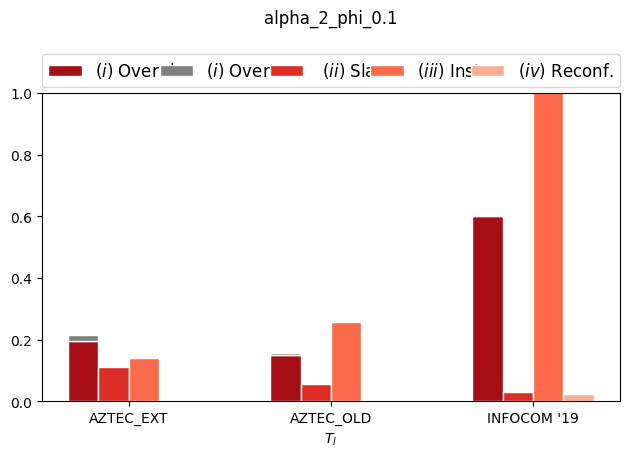

[[2.10192238e-01 1.56781415e-01 7.30705785e-01]
 [2.25348755e-02 7.88330007e-03 0.00000000e+00]
 [1.44990290e-01 7.60874946e-02 2.95647936e-02]
 [1.44266241e-01 2.57477211e-01 1.23738029e+00]
 [2.12746271e-03 4.07430635e-04 2.48334213e-02]]


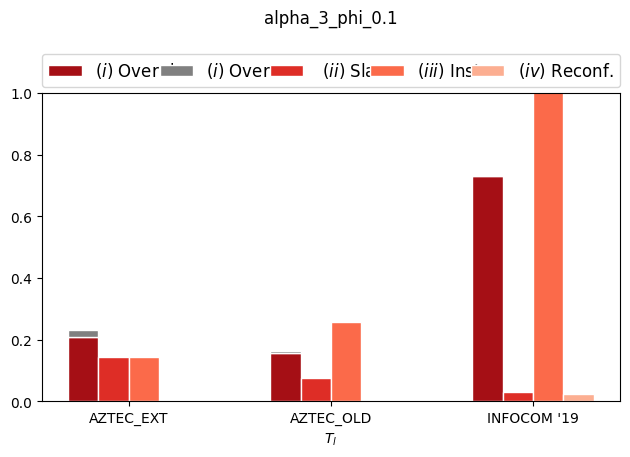

[[2.29978152e-01 1.64697158e-01 9.97453804e-01]
 [2.69381718e-02 1.07748903e-02 0.00000000e+00]
 [1.95834419e-01 1.03976874e-01 1.22828450e-02]
 [1.51698934e-01 2.58136351e-01 1.23898823e+00]
 [2.12247221e-03 4.06985685e-04 2.48715380e-02]]


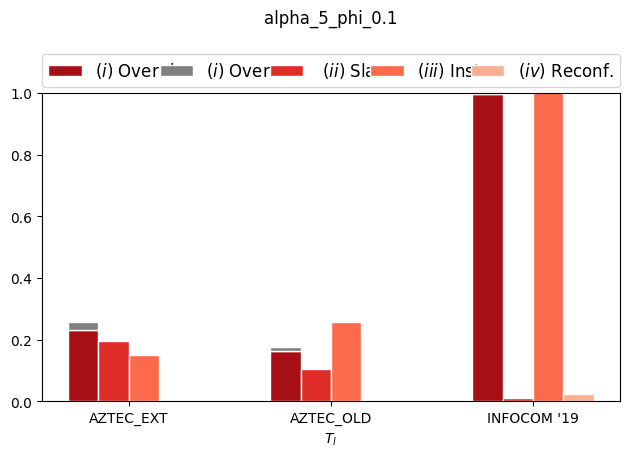

[[2.07205103e-01 2.17995370e-01 6.00008701e-01]
 [4.64600210e-03 1.97894459e-03 0.00000000e+00]
 [2.94316373e-02 1.90437676e-02 3.17075016e-02]
 [1.93143462e-01 2.50040844e-01 1.23263173e+00]
 [8.58478626e-04 6.97016853e-04 2.47975357e-01]]


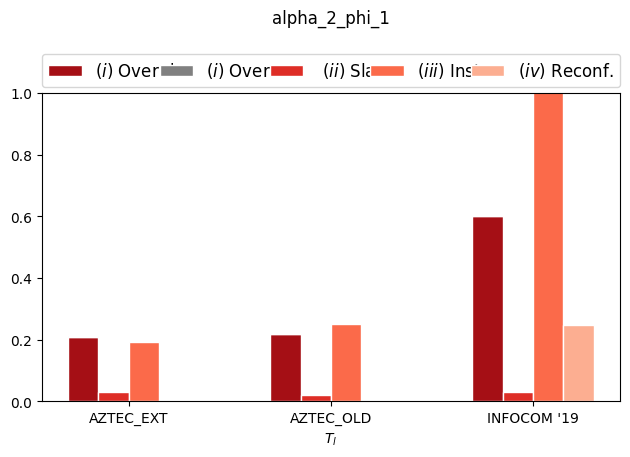

[[2.08784197e-01 2.18171569e-01 7.30705785e-01]
 [6.77050617e-03 2.81057723e-03 0.00000000e+00]
 [3.64660546e-02 2.86386595e-02 2.95647936e-02]
 [1.93245964e-01 2.50266551e-01 1.23738029e+00]
 [8.62349378e-04 6.95004027e-04 2.48334213e-01]]


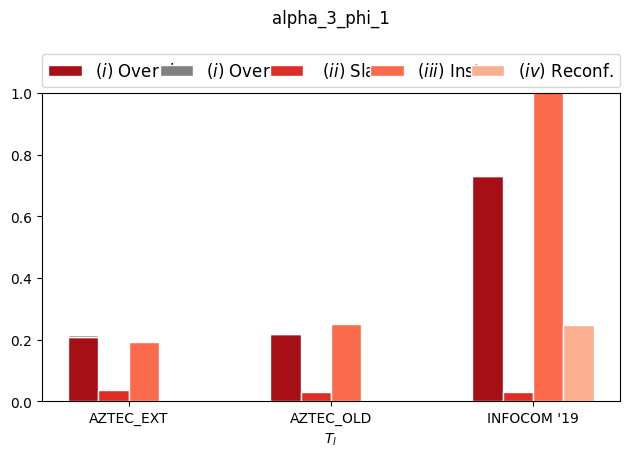

[[2.14156748e-01 2.18826526e-01 9.97453804e-01]
 [1.38751444e-02 5.03868545e-03 0.00000000e+00]
 [4.13688236e-02 4.73268799e-02 1.22828450e-02]
 [1.94101402e-01 2.50101083e-01 1.23898823e+00]
 [8.68673846e-04 7.25119417e-04 2.48715380e-01]]


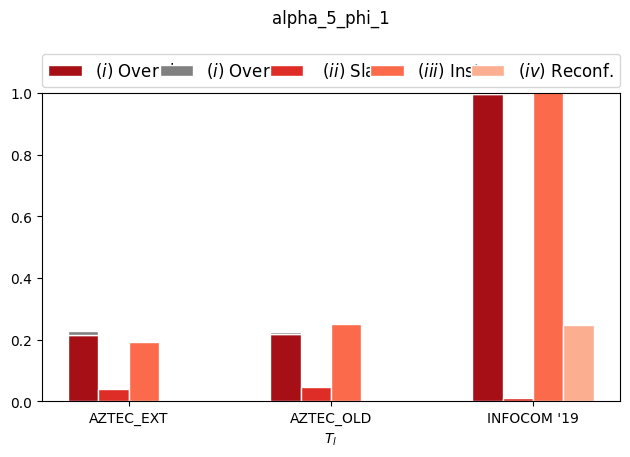

[[3.43108850e-01 3.60415825e-01 6.00008701e-01]
 [1.09726608e-03 3.33232631e-05 0.00000000e+00]
 [5.40579080e-03 7.89346617e-03 3.17075016e-02]
 [3.16307995e-01 2.51218257e-01 1.23263173e+00]
 [5.85009621e-03 1.33010660e-03 2.47975357e+00]]


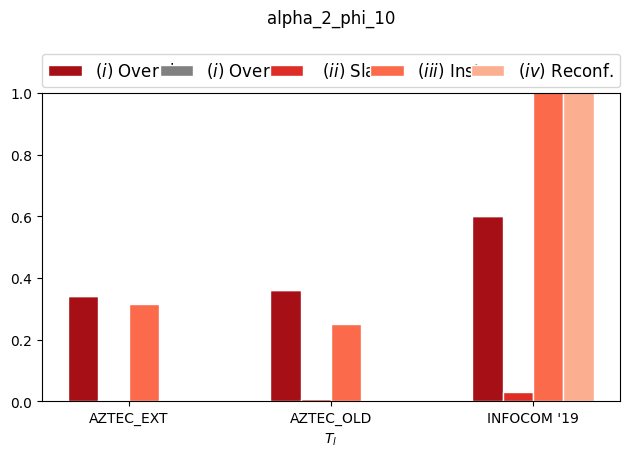

[[3.42925430e-01 3.60418953e-01 7.30705785e-01]
 [1.17259531e-03 9.14707616e-05 0.00000000e+00]
 [7.75589161e-03 1.18401993e-02 2.95647936e-02]
 [3.16160685e-01 2.51219673e-01 1.23738029e+00]
 [5.85009621e-03 1.33746707e-03 2.48334213e+00]]


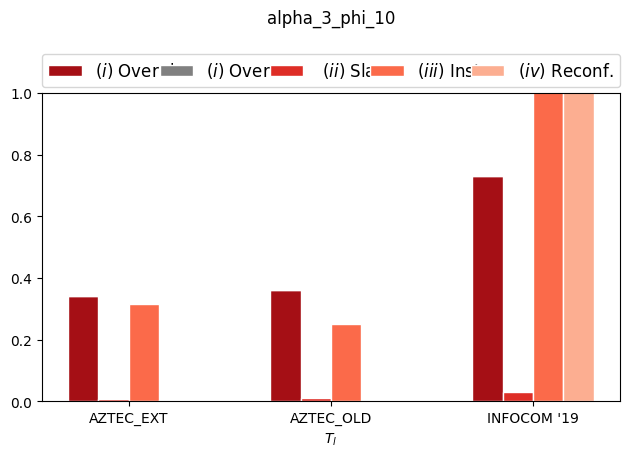

[[3.43126996e-01 3.60455115e-01 9.97453804e-01]
 [2.21369939e-03 7.90579825e-04 0.00000000e+00]
 [1.30679256e-02 1.97336654e-02 1.22828450e-02]
 [3.16234644e-01 2.51239245e-01 1.23898823e+00]
 [5.85009621e-03 1.33999556e-03 2.48715380e+00]]


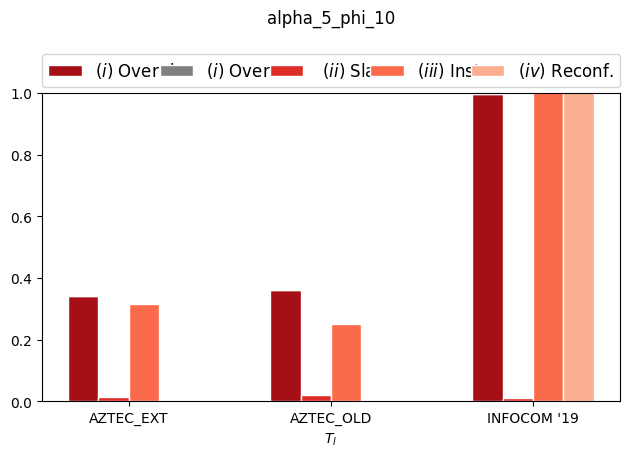

In [58]:
for idx, phi in enumerate(Phis):
    for j, alpha in enumerate(Alphas):
        
        # eta = 2

        fig,ax = plt.subplots()



        clrs = ['#fcae91',
                '#fb6a4a',
                '#de2d26',
                '#a50f15',
                '#a50f15'][::-1]

        cost_SLA_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_slas'].to_numpy()
        cost_instantiation_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
        cost_reconfiguration_eta_2_Aztec_ext = Aztec_ext_results_default[Aztec_ext_results_default.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
        cost_SLA_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_slas'].to_numpy()
        cost_instantiation_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation'].to_numpy()
        cost_reconfiguration_eta_2_Aztec_old = Aztec_old_results_merged_default[Aztec_old_results_merged_default.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()


        cost_overprovisioning_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_overprovisioning_infocom'].to_numpy()
        cost_sla_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_slas_infocom_19'].to_numpy()
        cost_reconfiguration_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_reconfiguration'].to_numpy()
        cost_instantation_deepcog = Deepcog_costs[Deepcog_costs.index.str.contains(f'_alpha_{alpha}_')]['cost_instantiation_infocom19'].to_numpy()

        eta = 5
        cost_tl_breakdown = np.zeros((5,3))
        cost_tl_breakdown[0,:] = [cost_overprovisioning_static_list_np[j,idx], cost_overprovisioning_static_list_np_6[j,idx], cost_overprovisioning_deepcog[idx]]
        cost_tl_breakdown[1,:] = [cost_overprovisioning_shared_list_np[j,idx], cost_overprovisioning_shared_list_np_6[j,idx], 0]
        cost_tl_breakdown[2,:] = [cost_SLA_eta_2_Aztec_ext[idx], cost_SLA_eta_2_Aztec_old[idx], cost_sla_deepcog[idx]]
        cost_tl_breakdown[3,:] = [cost_instantiation_eta_2_Aztec_ext[idx]*eta, cost_instantiation_eta_2_Aztec_old[idx] * eta, cost_instantation_deepcog[idx] * eta]
        cost_tl_breakdown[4,:] = [cost_reconfiguration_eta_2_Aztec_ext[idx], cost_reconfiguration_eta_2_Aztec_old[idx], cost_reconfiguration_deepcog[idx]]

        print(cost_tl_breakdown)
        costs = cost_tl_breakdown
        x = np.arange(3)


        lbs = ['($i$) Over d','($i$) Over s',' ($ii$) Slas','($iii$) Inst.', '($iv$) Reconf.']

        width = 0.15



        ax.bar(x,costs[0,:],width=width,edgecolor='w',color=clrs[0],label=lbs[0])
        ax.bar(x,costs[1,:],width=width,bottom=costs[0],edgecolor='w',facecolor='#808080',label=lbs[1])
        for i in range(2,5):
            ax.bar(x+(i-1)*width,costs[i,:],width=width,edgecolor = 'w',color=clrs[i],label=lbs[i])
            #ax.vlines(x+i*width,0,1000,colors='#DCDCDC')




        ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,
                   ncol=5, mode="expand", borderaxespad=0.,fontsize='large')

        ax.set_xticks(x+1.5*width)
        ax.set_xticklabels(['AZTEC_EXT','AZTEC_OLD','INFOCOM \'19'])
        #ax.legend(ncol=4,fontsize='large',bbox_to_anchor=(0.5, 1.05))


        ax.set_xlabel('$T_l$')
        ax.set_title(F'alpha_{alpha}_phi_{phi}',y = 1.2)
        ax.set_ylim(top=1)

        # ax.set_ylim(top=0.63)

        plt.tight_layout()
        # plt.savefig('cost_breakdown_vs_tl_phi_%s_beta_%s.pdf' % (ph, step))
        plt.show()